In [1]:
!git clone https://github.com/VladWero08/time-series-ad-gan.git

Cloning into 'time-series-ad-gan'...
remote: Enumerating objects: 513, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 513 (delta 48), reused 61 (delta 26), pack-reused 427 (from 1)
Receiving objects: 100% (513/513), 16.48 MiB | 31.36 MiB/s, done.
Resolving deltas: 100% (306/306), done.


In [6]:
pip install -r ./time-series-ad-gan/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.9/698.9 kB 17.5 MB/s eta 0:00:0000:01
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import sys 
import os

module_path = os.path.abspath("./time-series-ad-gan")
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import ast
import pandas as pd
import numpy as np
import json
import kagglehub
import typing as t
import torch
from urllib.request import urlopen
import matplotlib.pyplot as plt

from src.models.lstm import run_pipeline
from src.utils.data import intervals_to_points

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working on {device}!")

Working on cuda!


In [10]:
def plot_signal(X: np.ndarray, y: np.ndarray) -> None:
    plt.figure(figsize=(15, 4))
    for idx in np.where(y == 1)[0]:
        plt.axvline(idx, color='red', alpha=0.4, linewidth=0.8, zorder=0)
    plt.plot(X, zorder=1)
    plt.show()

## **NAB**

In [11]:
NAB_REPO = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/data/"

ART_FOLDER = "artificialWithAnomaly/"
ART_FILE_NAMES = [
    "art_daily_flatmiddle",
    "art_daily_jumpsdown",
    "art_daily_jumpsup",
    "art_daily_nojump",
    "art_increase_spike_density",
    "art_load_balancer_spikes"
]

AD_EX_FOLDER = "realAdExchange/"
AD_EX_FILE_NAMES = [
    "exchange-2_cpc_results",
    "exchange-2_cpm_results",
    "exchange-3_cpc_results",
    "exchange-3_cpm_results",
    "exchange-4_cpc_results",
    "exchange-4_cpm_results",
]

AWS_FOLDER = "realAWSCloudwatch/"
AWS_FILE_NAMES = [
    "ec2_cpu_utilization_24ae8d",
    "ec2_cpu_utilization_53ea38",
    "ec2_cpu_utilization_5f5533",
    "ec2_cpu_utilization_77c1ca",
    "ec2_cpu_utilization_825cc2",
    "ec2_cpu_utilization_ac20cd",
    "ec2_cpu_utilization_c6585a",
    "ec2_cpu_utilization_fe7f93",
    "ec2_disk_write_bytes_1ef3de",
    "ec2_disk_write_bytes_c0d644",
    "ec2_network_in_257a54",
    "ec2_network_in_5abac7",
    "elb_request_count_8c0756",
    "grok_asg_anomaly",
    "iio_us-east-1_i-a2eb1cd9_NetworkIn",
    "rds_cpu_utilization_cc0c53",
    "rds_cpu_utilization_e47b3b"
]

TRAFFIC_FOLDER = "realTraffic/"
TRAFFIC_FILE_NAMES = [
    "TravelTime_387",
    "TravelTime_451",
    "occupancy_6005",
    "occupancy_t4013",
    "speed_6005",
    "speed_7578",
    "speed_t4013"
]

TWEETS_FOLDER = "realTweets/"
TWEETS_FILE_NAMES = [
    "Twitter_volume_AAPL",
    "Twitter_volume_AMZN",
    "Twitter_volume_CRM",
    "Twitter_volume_CVS",
    "Twitter_volume_FB",
    "Twitter_volume_GOOG",
    "Twitter_volume_IBM",
    "Twitter_volume_KO",
    "Twitter_volume_PFE",
    "Twitter_volume_UPS"
]

NAB_LABELS = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/labels/combined_windows.json"

In [12]:
NAB_HYPERPARAMS = {
    "train_ratio": 0.6,
    "val_ratio": 0.1,
    "lr": 1e-4,
    "epochs": 35,
    "patience": 15,
    "device": device,
    "anomaly_type": "contextual",
    "verbose": True,
}

In [13]:
with urlopen(NAB_LABELS) as labels_url:
    nab_labels = json.loads(labels_url.read().decode())

In [14]:
def nab_download_subdataset(folder: str, file_names: list[str], nab_labels: dict) -> t.List[pd.DataFrame]:
    nab_signals = []
    nab_points = 0
    nab_anomalies = 0

    for i, fn in enumerate(file_names):
        # name of the .csv in the repository
        nab_ts_fn = f"{fn}.csv"
        # url to the raw .csv file in the repository
        nab_ts_url = f"{NAB_REPO}{folder}{nab_ts_fn}"

        nab_ts_df = pd.read_csv(nab_ts_url)
        nab_ts_df["is_anomaly"] = 0

        # iterate through the contextualized anomalies for each .csv file,
        # and if the timestamp is inside one of the intervals, toggle the is_anomaly attribute
        for start, end in nab_labels[f"{folder}{nab_ts_fn}"]:
            start = pd.Timestamp(start)
            end = pd.Timestamp(end)
            interval = pd.Interval(start, end, closed="both")

            nab_ts_df.loc[
                nab_ts_df["timestamp"].map(lambda ts: pd.Timestamp(ts) in interval),
                "is_anomaly"
            ] = 1

        nab_signals.append(nab_ts_df)
        nab_points += len(nab_ts_df)
        nab_anomalies += (nab_ts_df["is_anomaly"] == 1).sum()

        if (i + 1) % 5 == 0:
            print(f"Downloaded {i + 1} .csv files.")

    print()
    print(f"Finished downloading {folder}!")
    print("---------------------")
    print(f"Total Signals: {len(file_names)}")
    print(F"Total Points: {nab_points}")
    print(f"Total Anomaly Points: {nab_anomalies}")
    print(f"Anomaly Rate: {(nab_anomalies / nab_points) * 100:.2f}%")

    return nab_signals

### **Artificial with Anomaly**

In [15]:
ART_HYPERPARAMS = NAB_HYPERPARAMS.copy()
ART_HYPERPARAMS["train_ratio"] = 0.5

In [16]:
art_signals = nab_download_subdataset(folder=ART_FOLDER, file_names=ART_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading artificialWithAnomaly/!
---------------------
Total Signals: 6
Total Points: 24192
Total Anomaly Points: 2418
Anomaly Rate: 10.00%


--------------
Art Signal 1
--------------


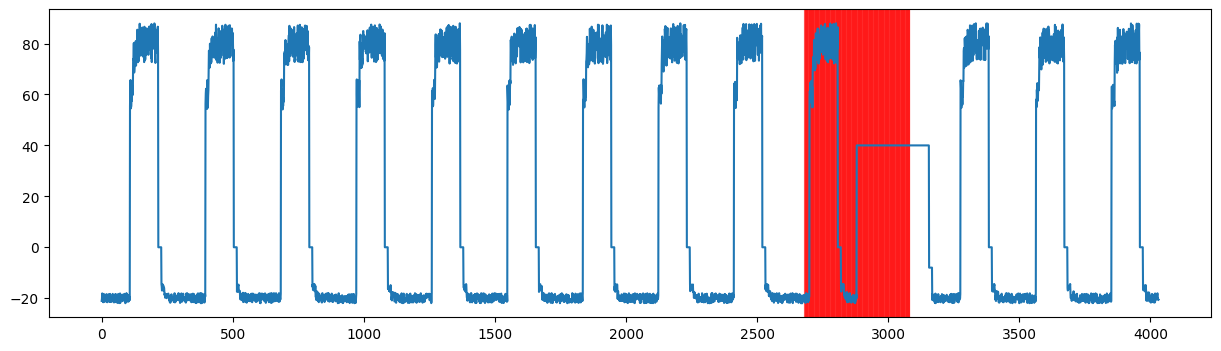

Epoch   5 | Train Loss: 0.173972 | Val Loss: 0.125585
Epoch  10 | Train Loss: 0.065668 | Val Loss: 0.106989
Epoch  15 | Train Loss: 0.059232 | Val Loss: 0.098503
Epoch  20 | Train Loss: 0.053448 | Val Loss: 0.090993
Epoch  25 | Train Loss: 0.049405 | Val Loss: 0.083065
Epoch  30 | Train Loss: 0.044668 | Val Loss: 0.075599
Epoch  35 | Train Loss: 0.042994 | Val Loss: 0.068190

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


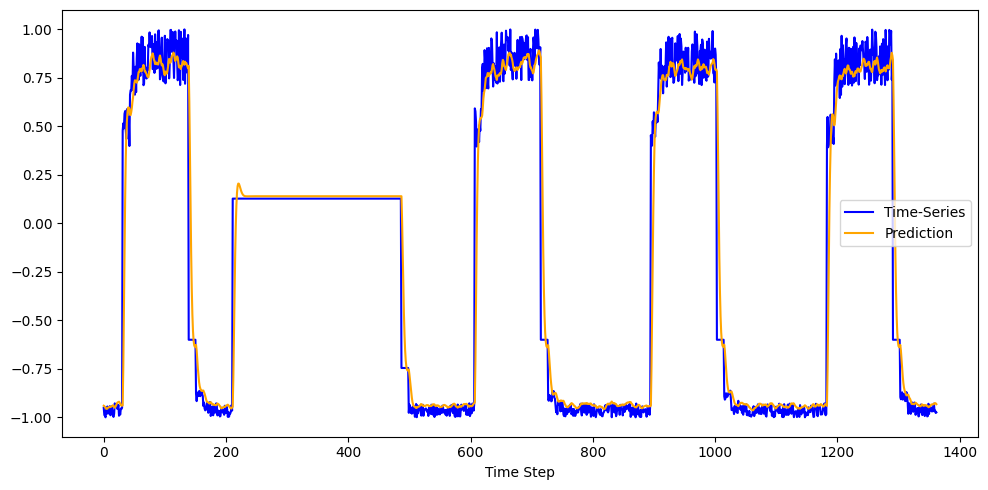

--------------
Art Signal 2
--------------


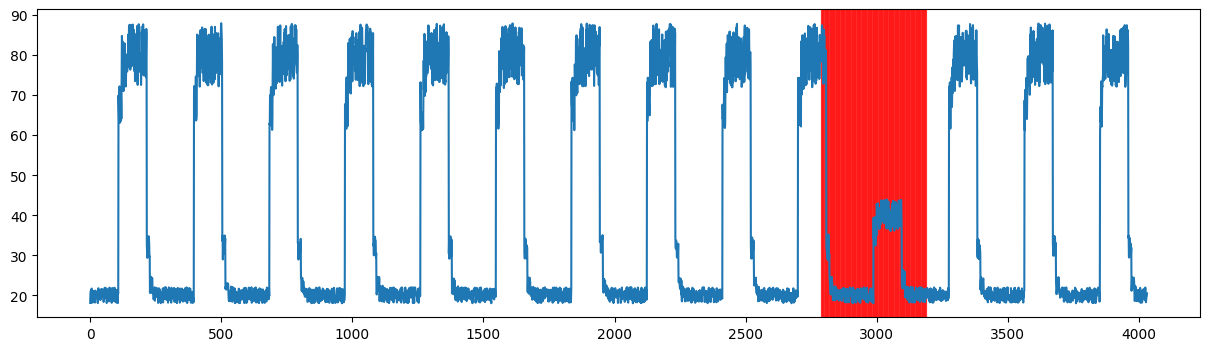

Epoch   5 | Train Loss: 0.165197 | Val Loss: 0.100976
Epoch  10 | Train Loss: 0.063466 | Val Loss: 0.084487
Epoch  15 | Train Loss: 0.057902 | Val Loss: 0.078916
Epoch  20 | Train Loss: 0.053285 | Val Loss: 0.072933
Epoch  25 | Train Loss: 0.049428 | Val Loss: 0.066230
Epoch  30 | Train Loss: 0.046615 | Val Loss: 0.060810
Epoch  35 | Train Loss: 0.043814 | Val Loss: 0.055303

Metrics
-------
Precision = 0.2000
Recall = 1.0000
F1 = 0.3333


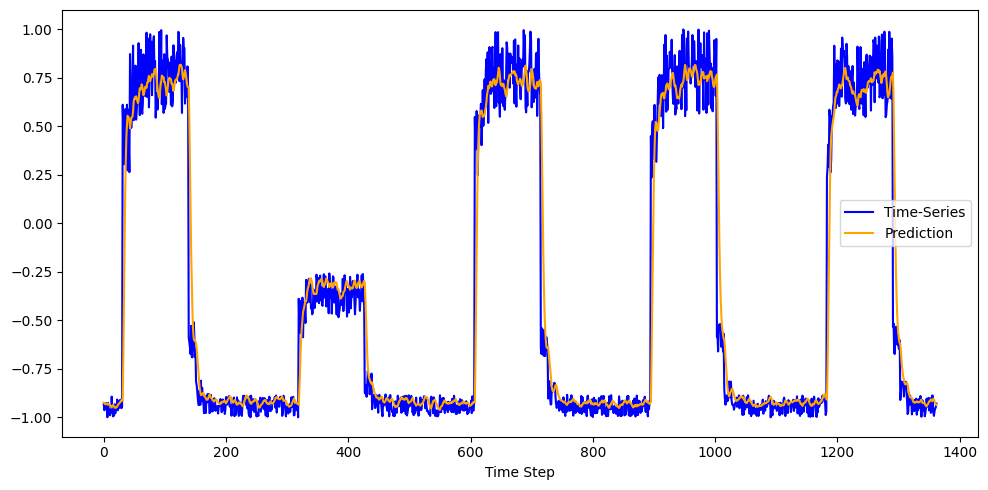

--------------
Art Signal 3
--------------


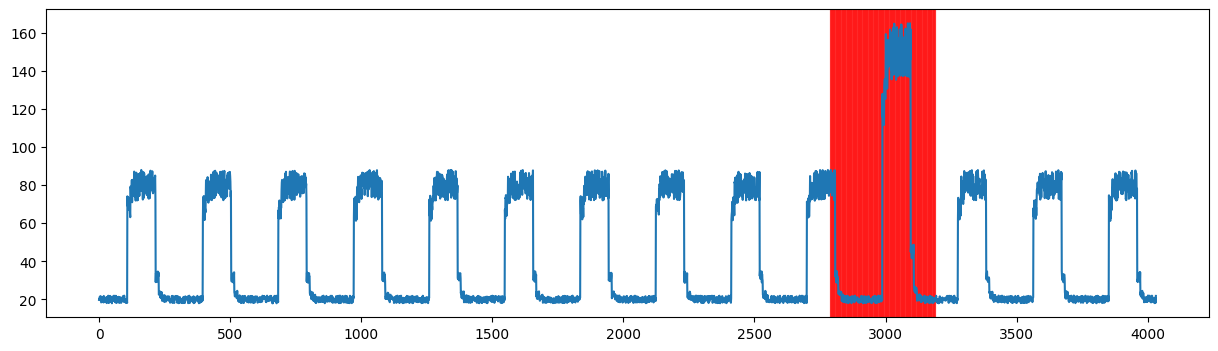

Epoch   5 | Train Loss: 0.231197 | Val Loss: 0.099491
Epoch  10 | Train Loss: 0.064606 | Val Loss: 0.083409
Epoch  15 | Train Loss: 0.059757 | Val Loss: 0.078249
Epoch  20 | Train Loss: 0.054392 | Val Loss: 0.073144
Epoch  25 | Train Loss: 0.050326 | Val Loss: 0.067765
Epoch  30 | Train Loss: 0.046699 | Val Loss: 0.062945
Epoch  35 | Train Loss: 0.044250 | Val Loss: 0.057181

Metrics
-------
Precision = 0.5000
Recall = 1.0000
F1 = 0.6667


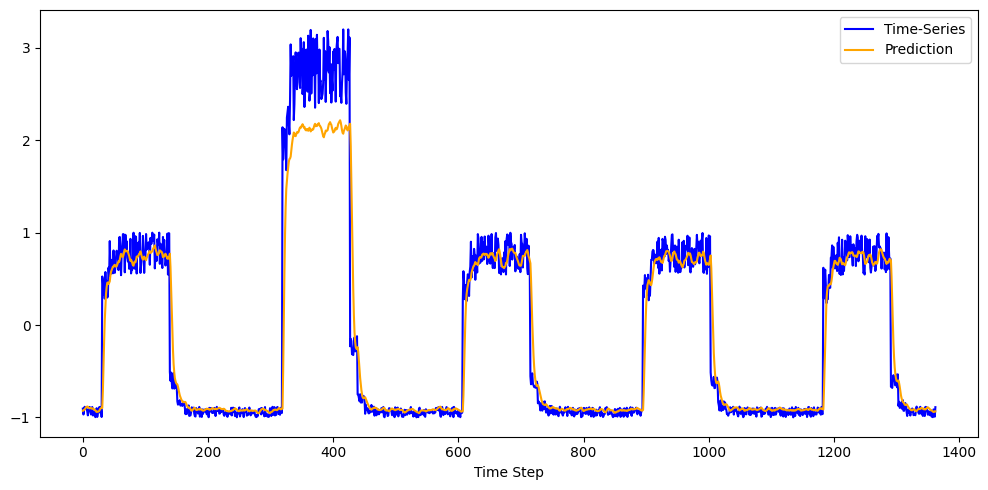

--------------
Art Signal 4
--------------


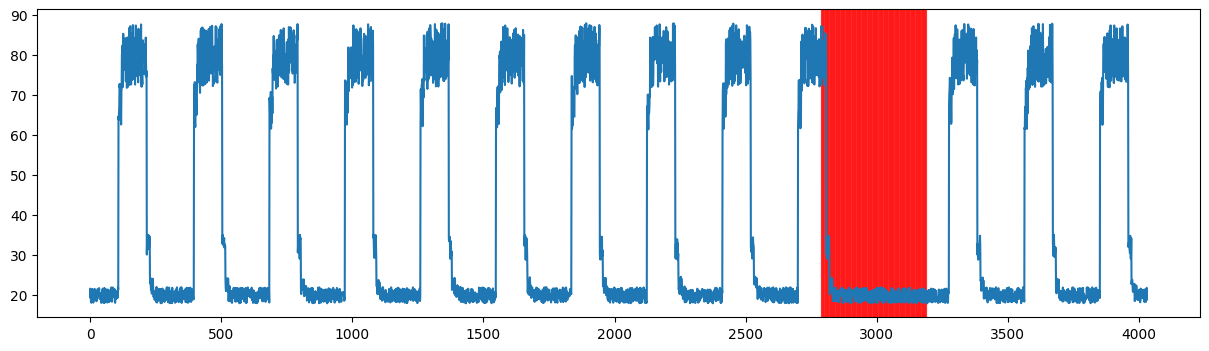

Epoch   5 | Train Loss: 0.186214 | Val Loss: 0.117807
Epoch  10 | Train Loss: 0.063749 | Val Loss: 0.096194
Epoch  15 | Train Loss: 0.058396 | Val Loss: 0.089815
Epoch  20 | Train Loss: 0.053019 | Val Loss: 0.083636
Epoch  25 | Train Loss: 0.049841 | Val Loss: 0.077339
Epoch  30 | Train Loss: 0.046359 | Val Loss: 0.071726
Epoch  35 | Train Loss: 0.044416 | Val Loss: 0.065732

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


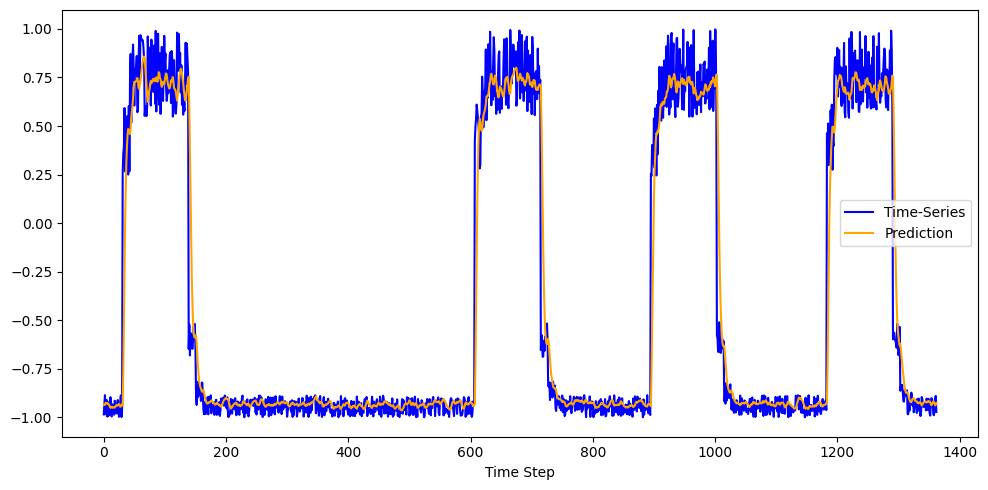

--------------
Art Signal 5
--------------


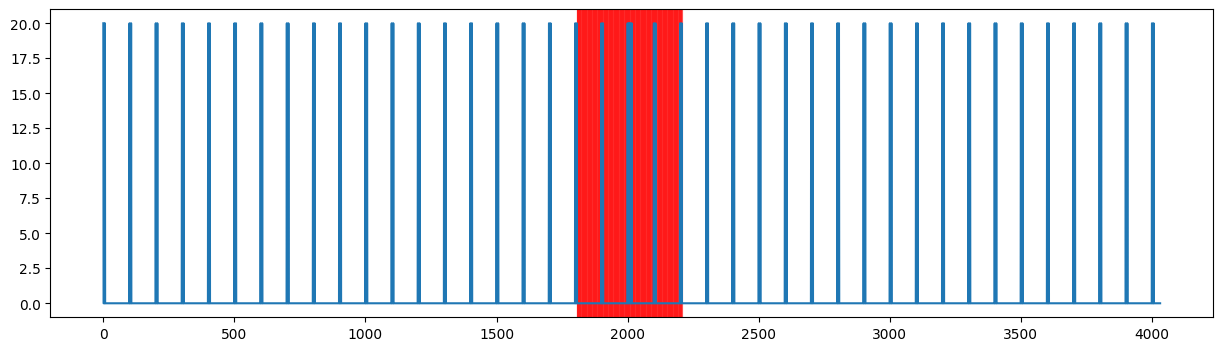

Epoch   5 | Train Loss: 0.091716 | Val Loss: 0.143901
Epoch  10 | Train Loss: 0.091433 | Val Loss: 0.143627
Epoch  15 | Train Loss: 0.091760 | Val Loss: 0.143615
Early stopping at epoch 19

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


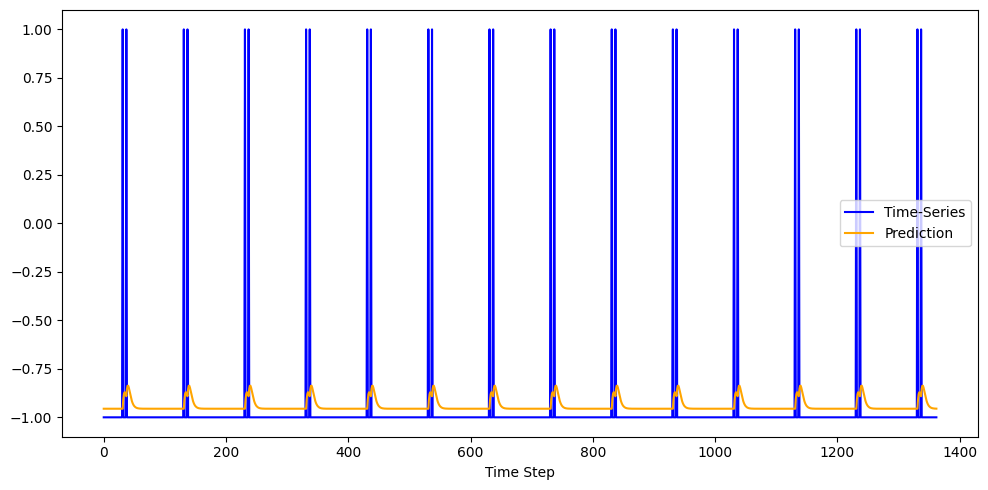

--------------
Art Signal 6
--------------


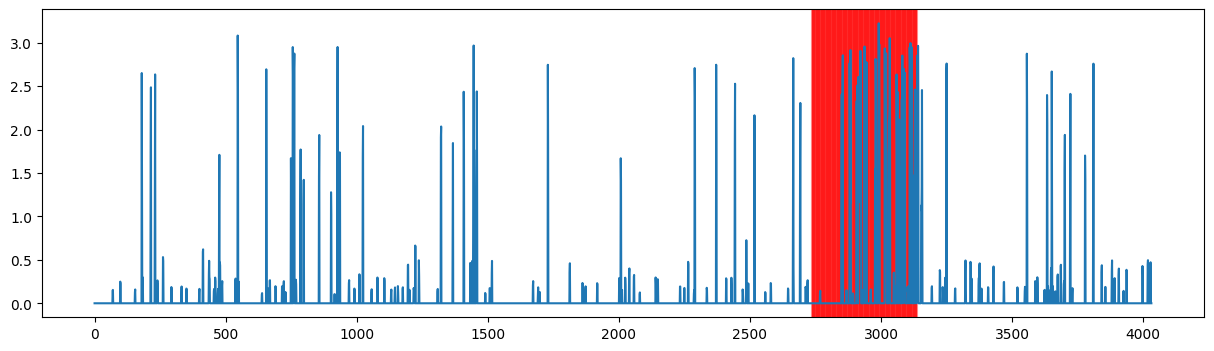

Epoch   5 | Train Loss: 0.039726 | Val Loss: 0.052276
Epoch  10 | Train Loss: 0.040861 | Val Loss: 0.052170
Epoch  15 | Train Loss: 0.040163 | Val Loss: 0.052147
Epoch  20 | Train Loss: 0.039943 | Val Loss: 0.052144
Early stopping at epoch 20

Metrics
-------
Precision = 0.5000
Recall = 1.0000
F1 = 0.6667


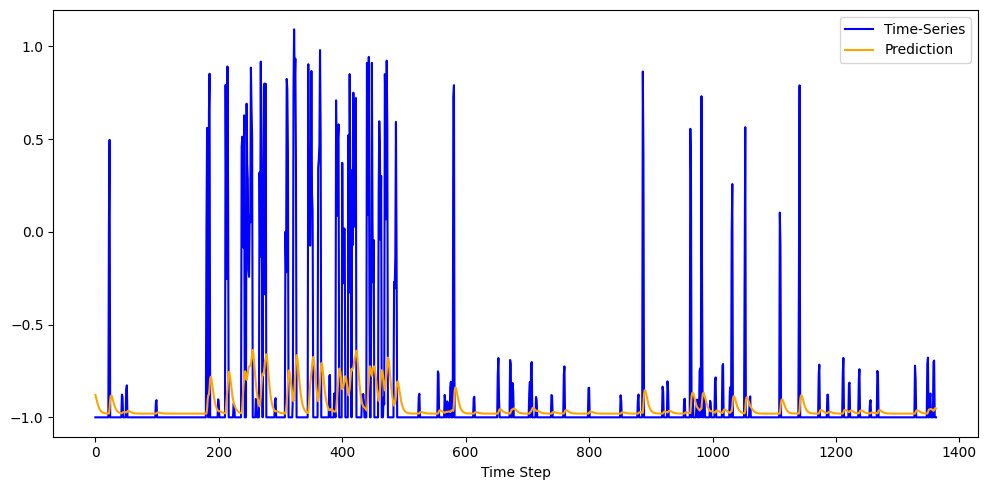

------------------
Art Signal Metrics
------------------
Precision: 0.464
Recall: 1.000
F1: 0.594



In [17]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, art_signal in enumerate(art_signals):
    X = art_signal["value"].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = art_signal["is_anomaly"].to_numpy()
    
    print("--------------")
    print(f"Art Signal {i + 1}")
    print("--------------")
    plot_signal(X, y)

    precision, recall, f1, = run_pipeline(X, y, **ART_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(art_signals)
total_recall /= len(art_signals)
total_f1 /= len(art_signals)

print("------------------")
print("Art Signal Metrics")
print("------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **Ad Exchange**

In [18]:
ad_ex_signals = nab_download_subdataset(folder=AD_EX_FOLDER, file_names=AD_EX_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realAdExchange/!
---------------------
Total Signals: 6
Total Points: 9610
Total Anomaly Points: 960
Anomaly Rate: 9.99%


--------------
Ad Exchange Signal 1
--------------


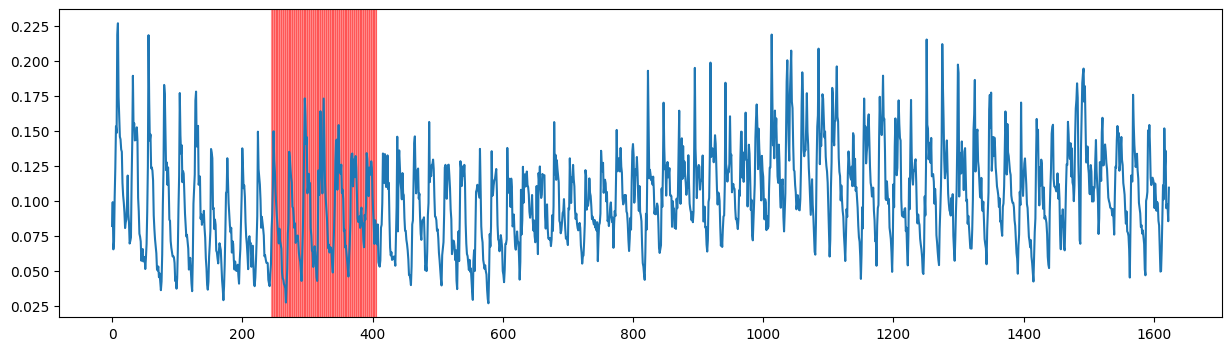

Epoch   5 | Train Loss: 0.075014 | Val Loss: 0.042625
Epoch  10 | Train Loss: 0.069762 | Val Loss: 0.038518
Epoch  15 | Train Loss: 0.067005 | Val Loss: 0.033255
Early stopping at epoch 16

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


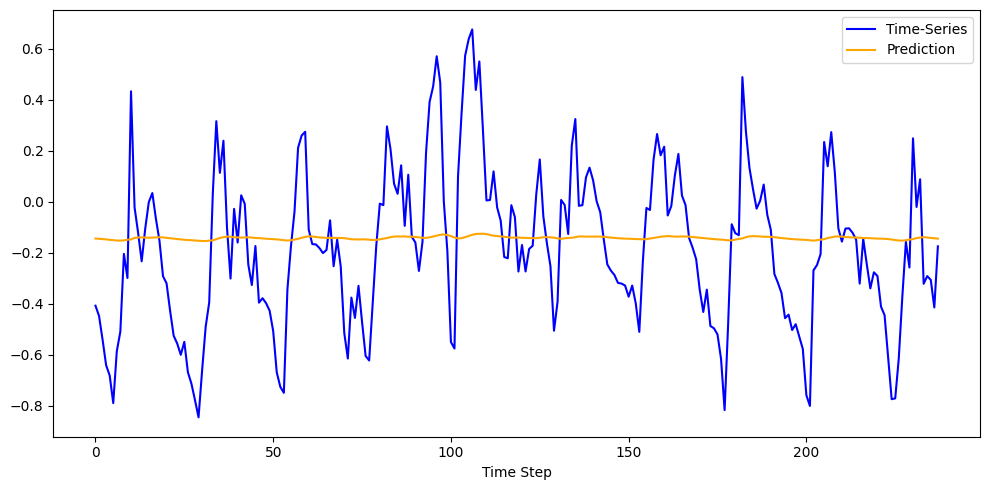

--------------
Ad Exchange Signal 2
--------------


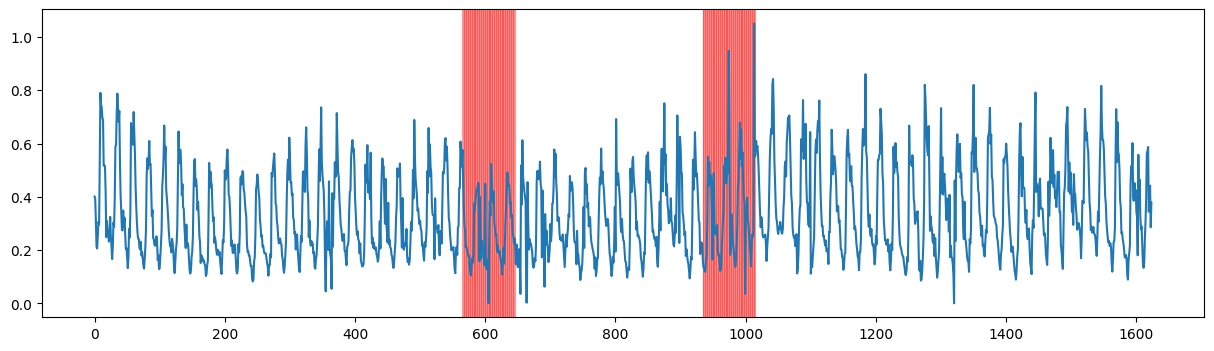

Epoch   5 | Train Loss: 0.120537 | Val Loss: 0.235708
Epoch  10 | Train Loss: 0.112321 | Val Loss: 0.191528
Epoch  15 | Train Loss: 0.102372 | Val Loss: 0.149688
Epoch  20 | Train Loss: 0.089876 | Val Loss: 0.099171
Epoch  25 | Train Loss: 0.070482 | Val Loss: 0.036210
Epoch  30 | Train Loss: 0.049125 | Val Loss: 0.000284
Epoch  35 | Train Loss: 0.047584 | Val Loss: 0.000002

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


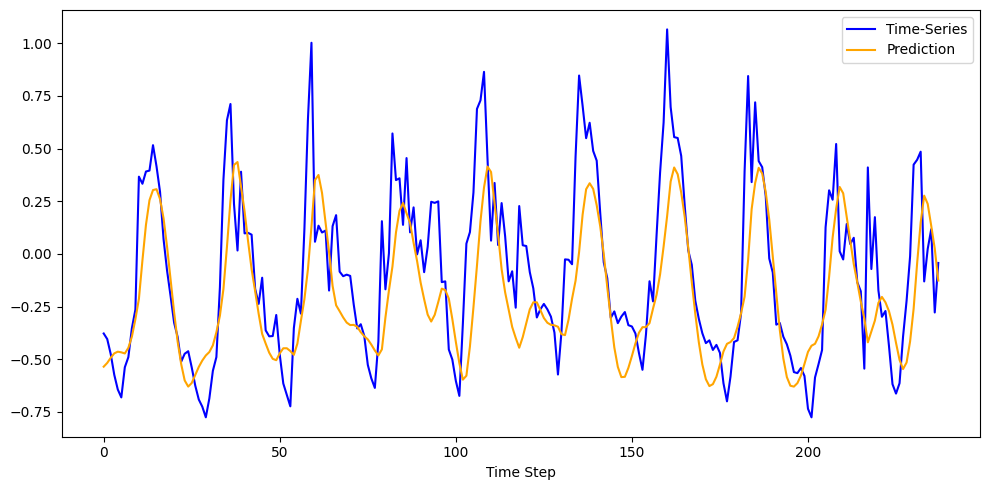

--------------
Ad Exchange Signal 3
--------------


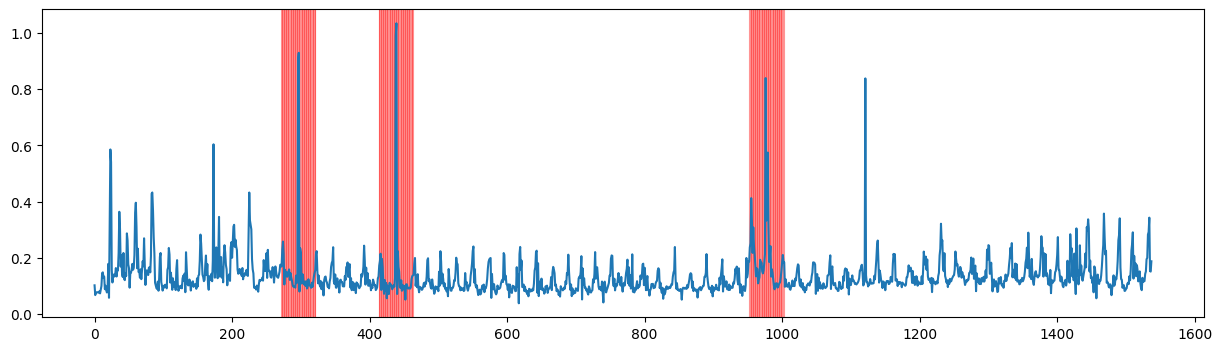

Epoch   5 | Train Loss: 0.260839 | Val Loss: 0.215764
Epoch  10 | Train Loss: 0.028480 | Val Loss: 0.000176
Epoch  15 | Train Loss: 0.025902 | Val Loss: 0.001171
Epoch  20 | Train Loss: 0.027261 | Val Loss: 0.001270
Early stopping at epoch 24

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


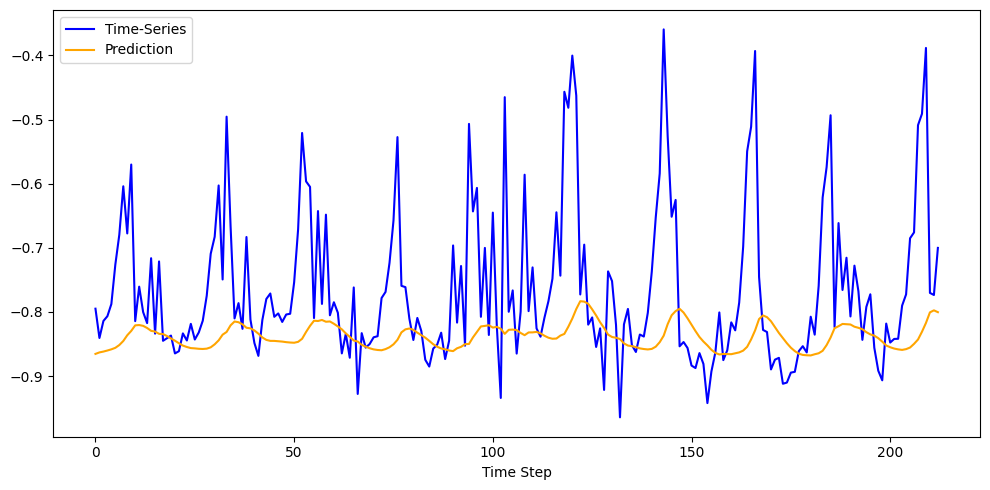

--------------
Ad Exchange Signal 4
--------------


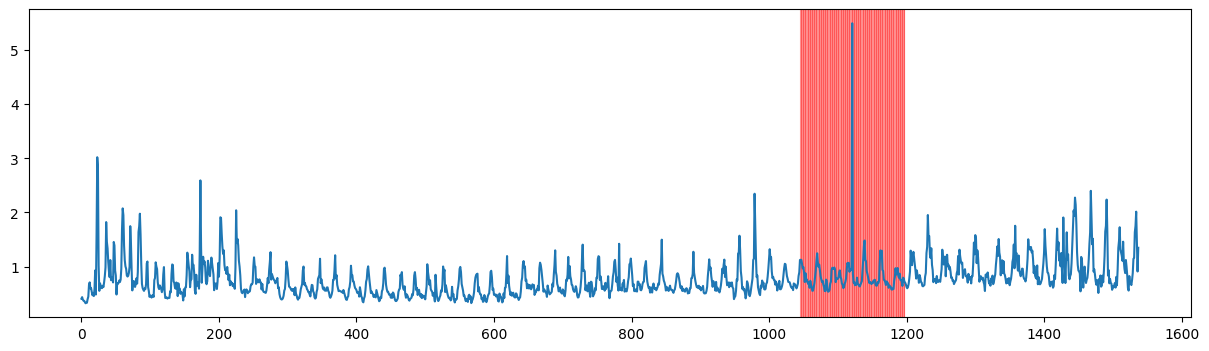

Epoch   5 | Train Loss: 0.295950 | Val Loss: 0.071352
Epoch  10 | Train Loss: 0.021840 | Val Loss: 0.050569
Epoch  15 | Train Loss: 0.021183 | Val Loss: 0.033087
Epoch  20 | Train Loss: 0.020528 | Val Loss: 0.032965
Early stopping at epoch 23

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


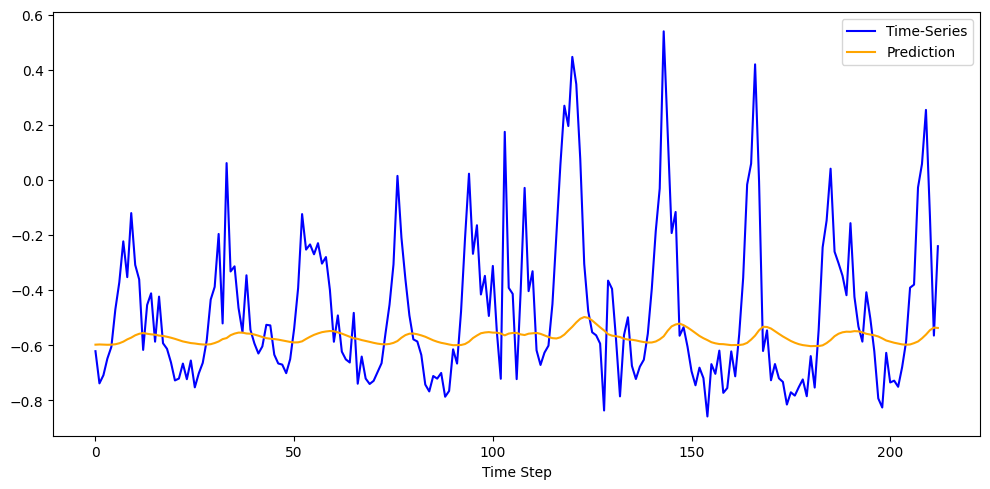

--------------
Ad Exchange Signal 5
--------------


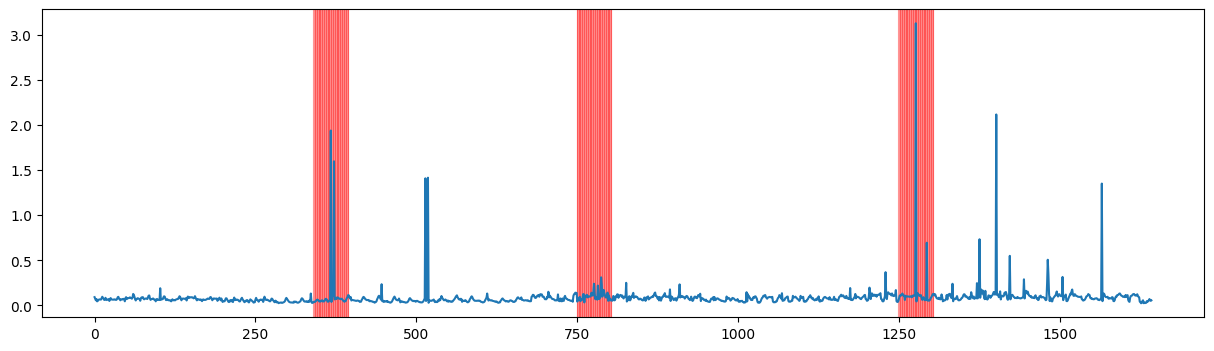

Epoch   5 | Train Loss: 0.432442 | Val Loss: 0.350196
Epoch  10 | Train Loss: 0.019663 | Val Loss: 0.000025
Epoch  15 | Train Loss: 0.016956 | Val Loss: 0.000095
Epoch  20 | Train Loss: 0.016184 | Val Loss: 0.000012
Early stopping at epoch 23

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


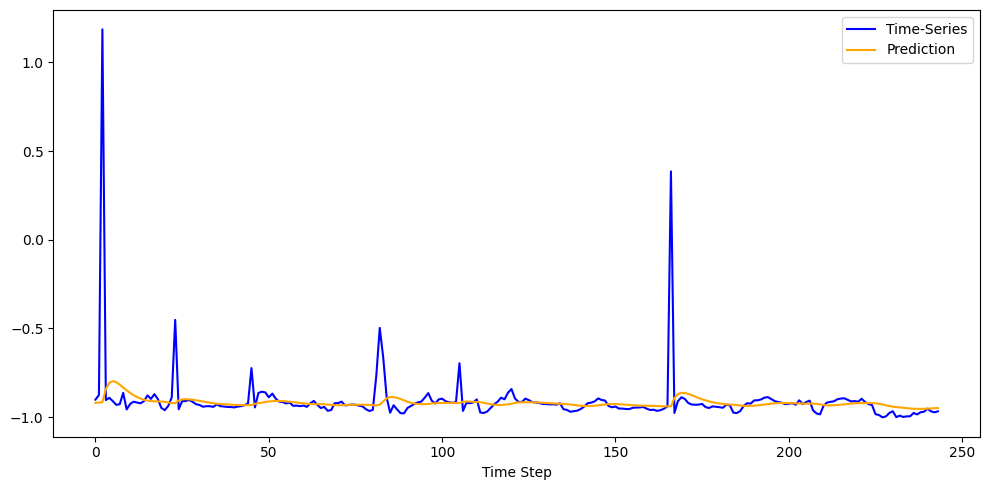

--------------
Ad Exchange Signal 6
--------------


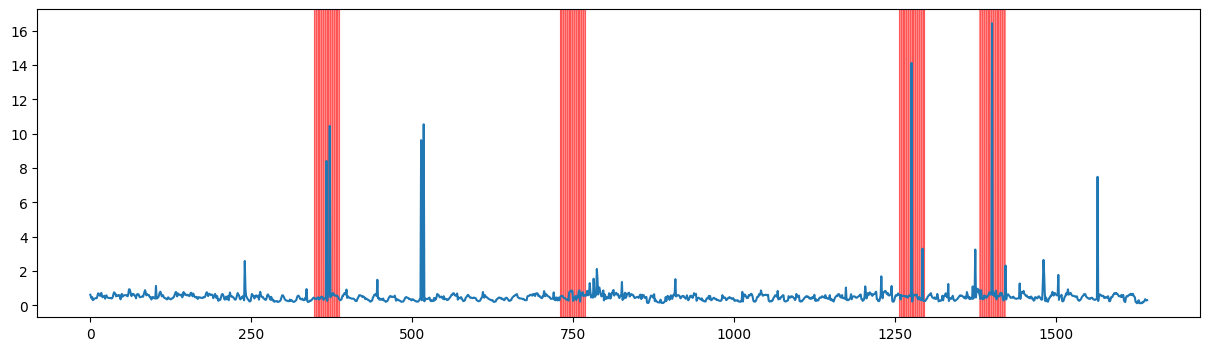

Epoch   5 | Train Loss: 0.221310 | Val Loss: 0.135961
Epoch  10 | Train Loss: 0.020653 | Val Loss: 0.000732
Epoch  15 | Train Loss: 0.019685 | Val Loss: 0.000077
Epoch  20 | Train Loss: 0.020407 | Val Loss: 0.000077
Epoch  25 | Train Loss: 0.019915 | Val Loss: 0.000007
Early stopping at epoch 27

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


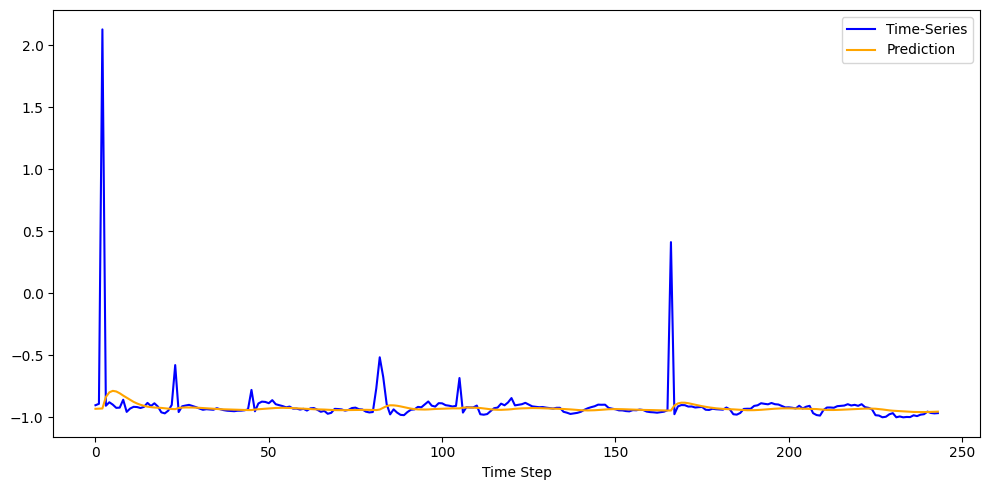

-------------------
Ad Exchange Metrics
-------------------
Precision: 0.833
Recall: 0.833
F1: 0.833



In [19]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, ad_ex_signal in enumerate(ad_ex_signals):
    X = ad_ex_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    # min-max normalization to [-1, 1]
    y = ad_ex_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"Ad Exchange Signal {i + 1}")
    print("--------------")
    plot_signal(X, y)

    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(ad_ex_signals)
total_recall /= len(ad_ex_signals)
total_f1 /= len(ad_ex_signals)

print("-------------------")
print("Ad Exchange Metrics")
print("-------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **AWS Cloudwatch**

In [50]:
aws_signals = nab_download_subdataset(folder=AWS_FOLDER, file_names=AWS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.
Downloaded 15 .csv files.

Finished downloading realAWSCloudwatch/!
---------------------
Total Signals: 17
Total Points: 67740
Total Anomaly Points: 6312
Anomaly Rate: 9.32%


--------------
AWS Signal 1
--------------


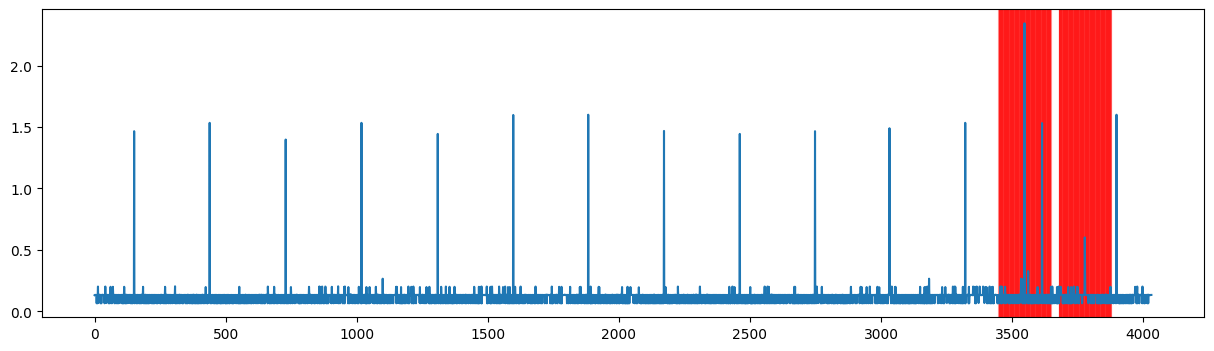

Epoch   5 | Train Loss: 0.013626 | Val Loss: 0.017884
Epoch  10 | Train Loss: 0.013418 | Val Loss: 0.017877
Epoch  15 | Train Loss: 0.013499 | Val Loss: 0.017880
Early stopping at epoch 19

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


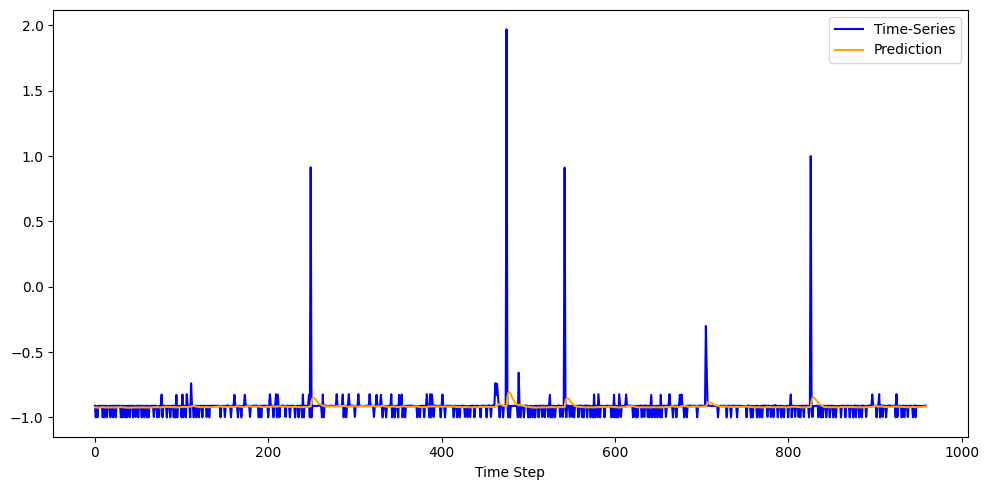

--------------
AWS Signal 2
--------------


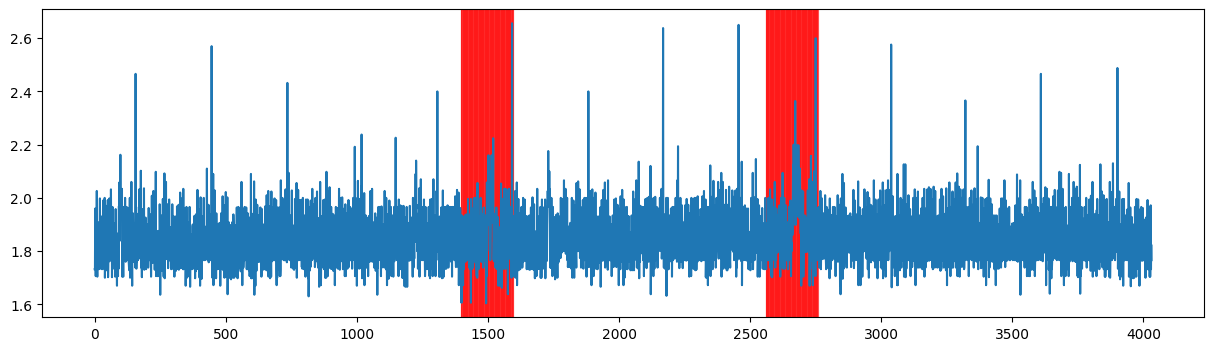

Epoch   5 | Train Loss: 0.036606 | Val Loss: 0.052738
Epoch  10 | Train Loss: 0.036675 | Val Loss: 0.052265
Epoch  15 | Train Loss: 0.036803 | Val Loss: 0.051583
Early stopping at epoch 17

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


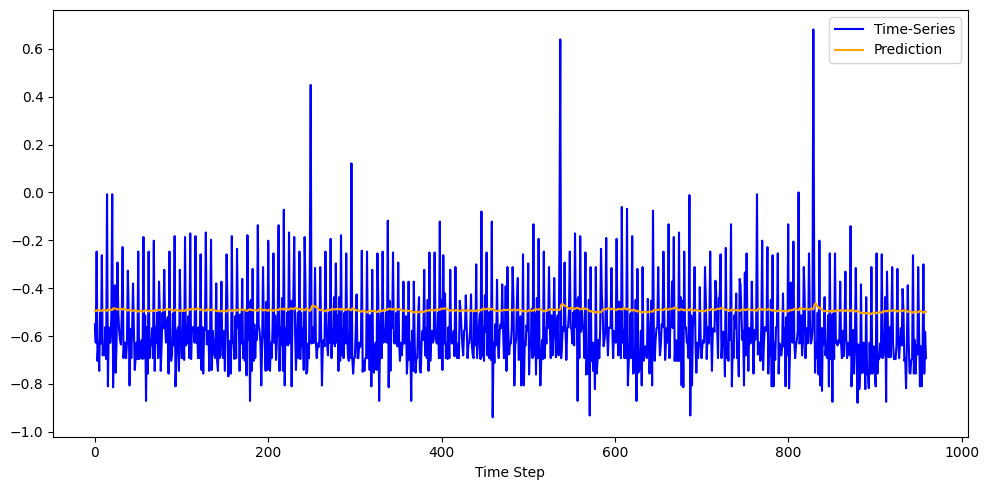

--------------
AWS Signal 3
--------------


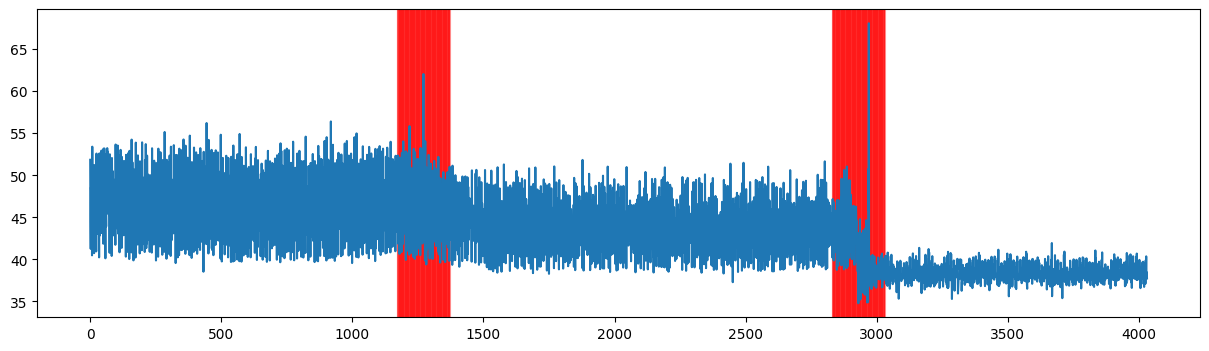

Epoch   5 | Train Loss: 0.096069 | Val Loss: 0.067913
Epoch  10 | Train Loss: 0.094236 | Val Loss: 0.065968
Epoch  15 | Train Loss: 0.090343 | Val Loss: 0.063186
Epoch  20 | Train Loss: 0.082899 | Val Loss: 0.062741
Epoch  25 | Train Loss: 0.081867 | Val Loss: 0.062091
Epoch  30 | Train Loss: 0.081031 | Val Loss: 0.061133
Epoch  35 | Train Loss: 0.079485 | Val Loss: 0.059920

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


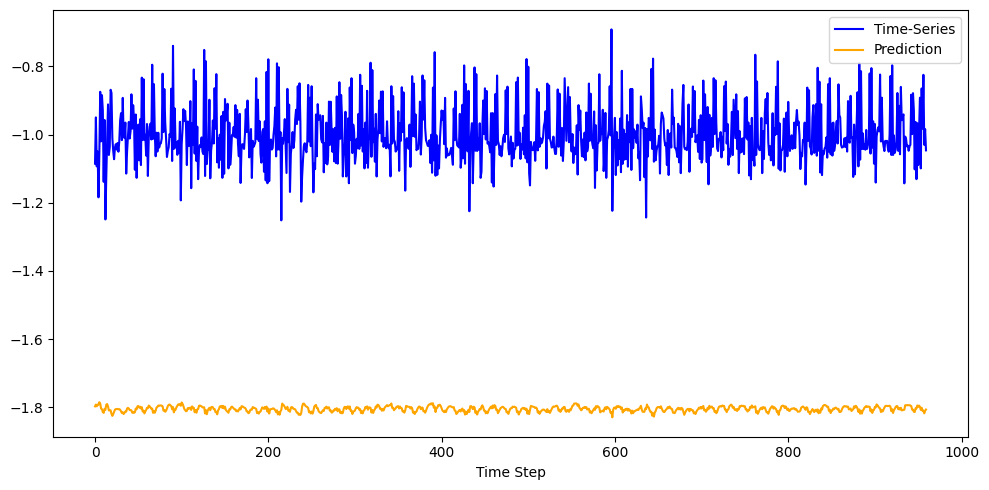

--------------
AWS Signal 4
--------------


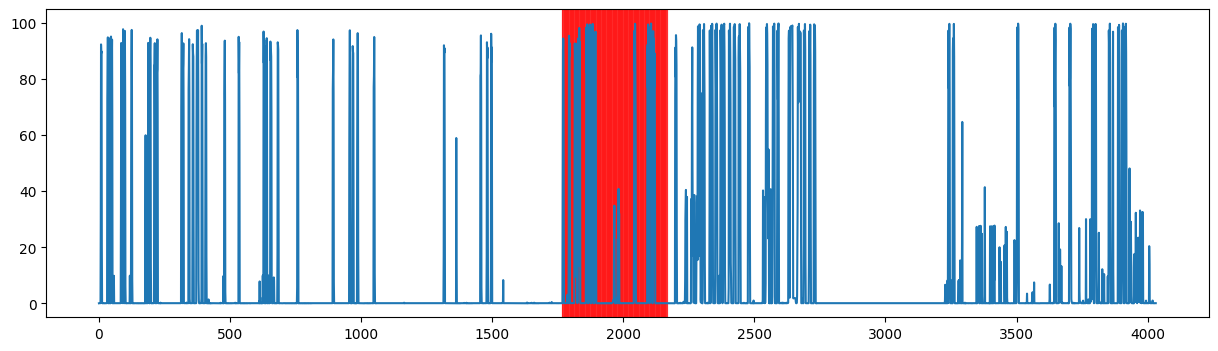

Epoch   5 | Train Loss: 0.240381 | Val Loss: 0.314048
Epoch  10 | Train Loss: 0.217131 | Val Loss: 0.268666
Epoch  15 | Train Loss: 0.198832 | Val Loss: 0.232933
Epoch  20 | Train Loss: 0.179109 | Val Loss: 0.197226
Epoch  25 | Train Loss: 0.152620 | Val Loss: 0.154942
Epoch  30 | Train Loss: 0.123716 | Val Loss: 0.128841
Epoch  35 | Train Loss: 0.108539 | Val Loss: 0.115387

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


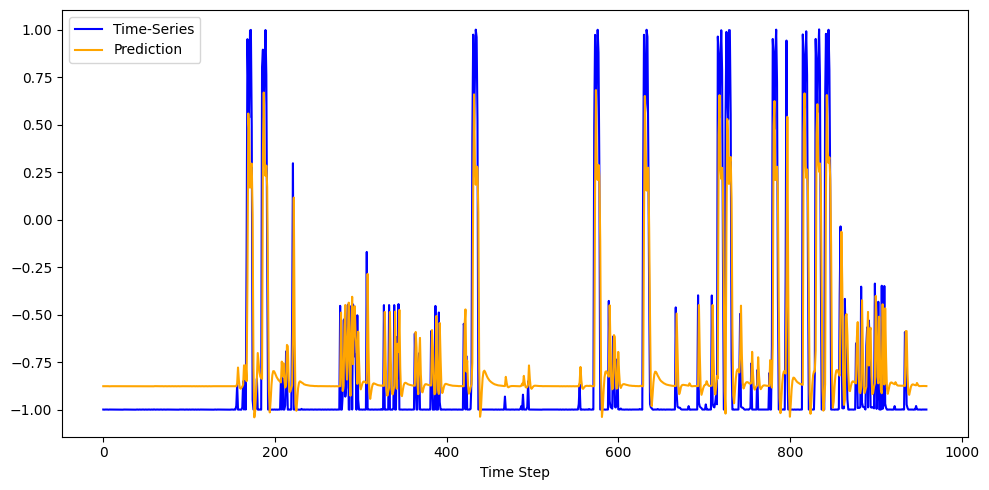

--------------
AWS Signal 5
--------------


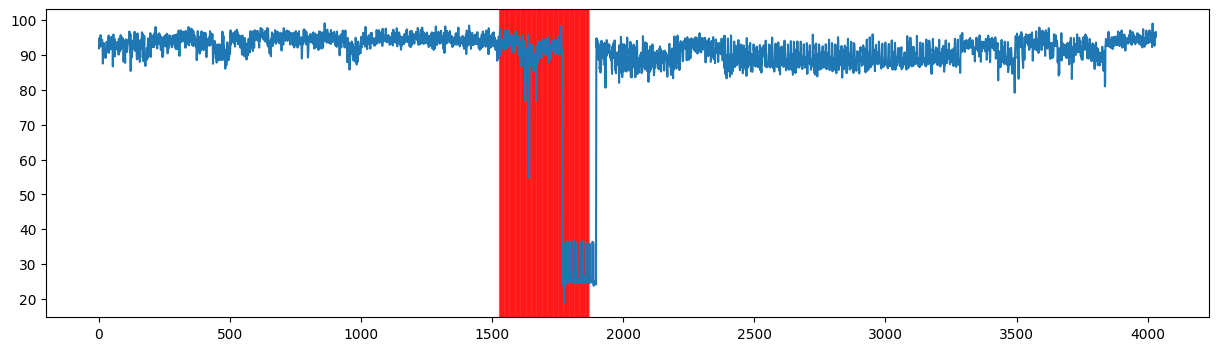

Epoch   5 | Train Loss: 0.080294 | Val Loss: 0.004902
Epoch  10 | Train Loss: 0.038911 | Val Loss: 0.004458
Epoch  15 | Train Loss: 0.015904 | Val Loss: 0.004853
Early stopping at epoch 18

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


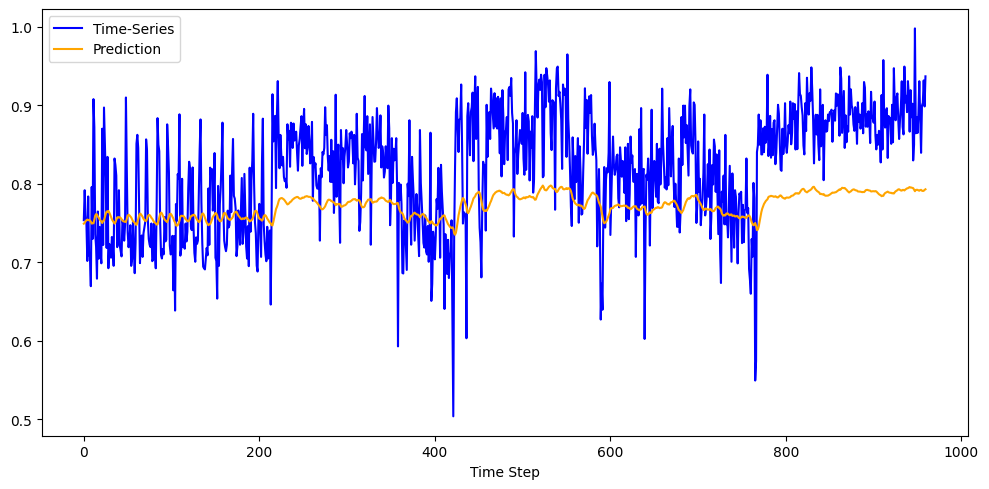

--------------
AWS Signal 6
--------------


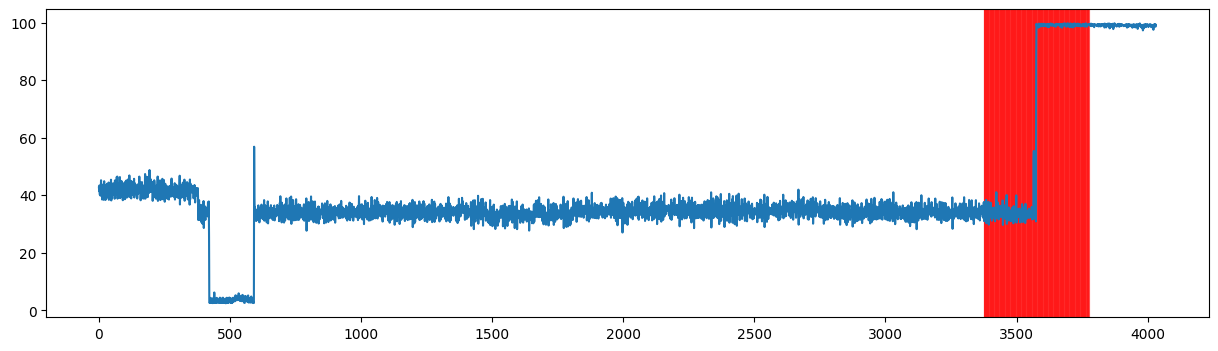

Epoch   5 | Train Loss: 0.077325 | Val Loss: 0.005682
Epoch  10 | Train Loss: 0.012804 | Val Loss: 0.004675
Epoch  15 | Train Loss: 0.012080 | Val Loss: 0.004685
Epoch  20 | Train Loss: 0.012246 | Val Loss: 0.004713
Early stopping at epoch 22

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


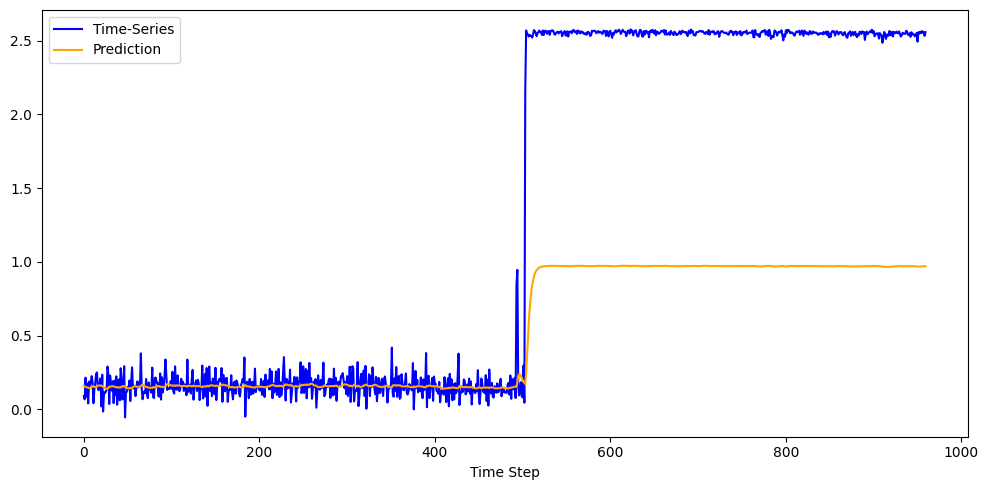

--------------
AWS Signal 7
--------------


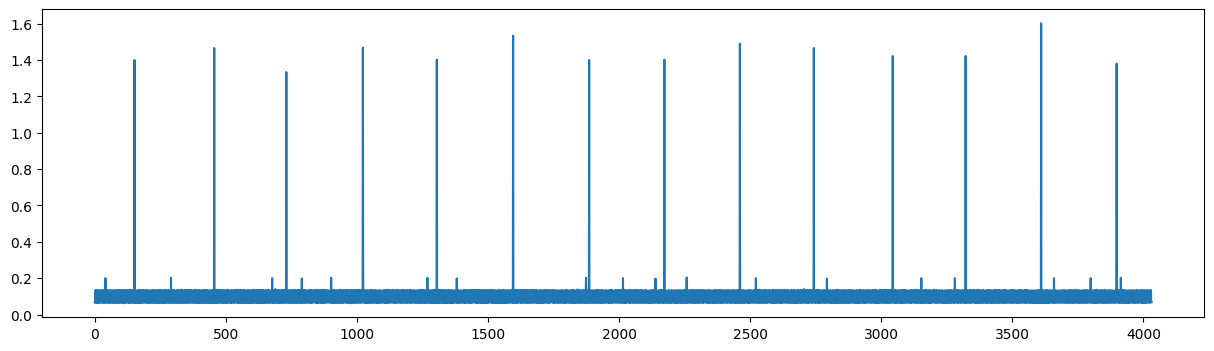

Epoch   5 | Train Loss: 0.013450 | Val Loss: 0.020274
Epoch  10 | Train Loss: 0.013530 | Val Loss: 0.020207
Epoch  15 | Train Loss: 0.013306 | Val Loss: 0.020252
Early stopping at epoch 18

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


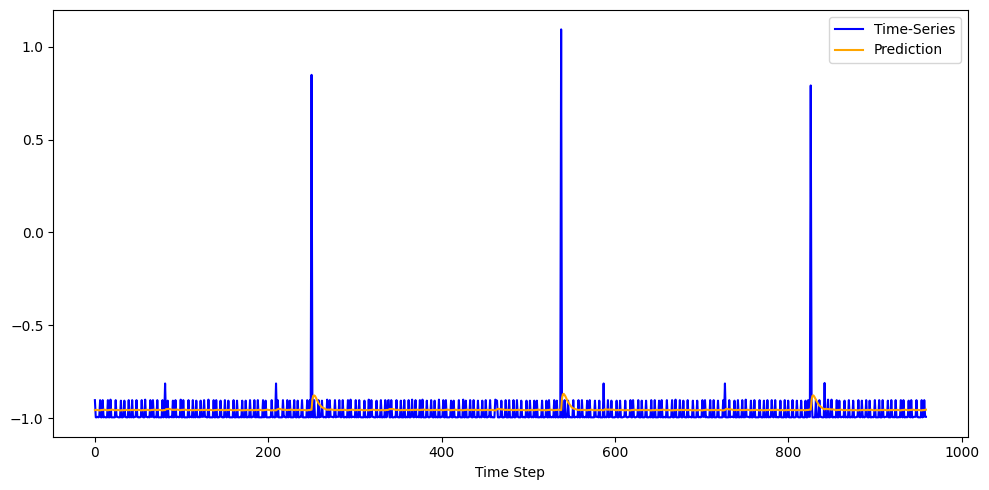

--------------
AWS Signal 8
--------------


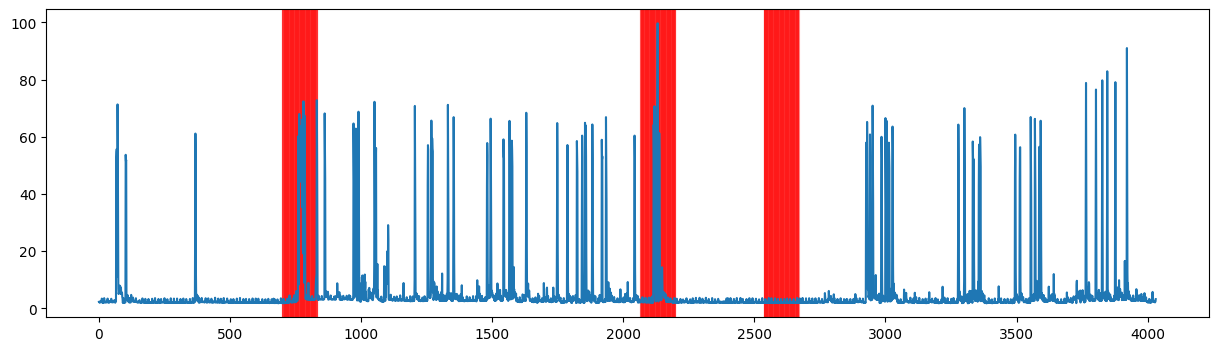

Epoch   5 | Train Loss: 0.057151 | Val Loss: 0.004701
Epoch  10 | Train Loss: 0.055863 | Val Loss: 0.004184
Epoch  15 | Train Loss: 0.054670 | Val Loss: 0.003285
Early stopping at epoch 18

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


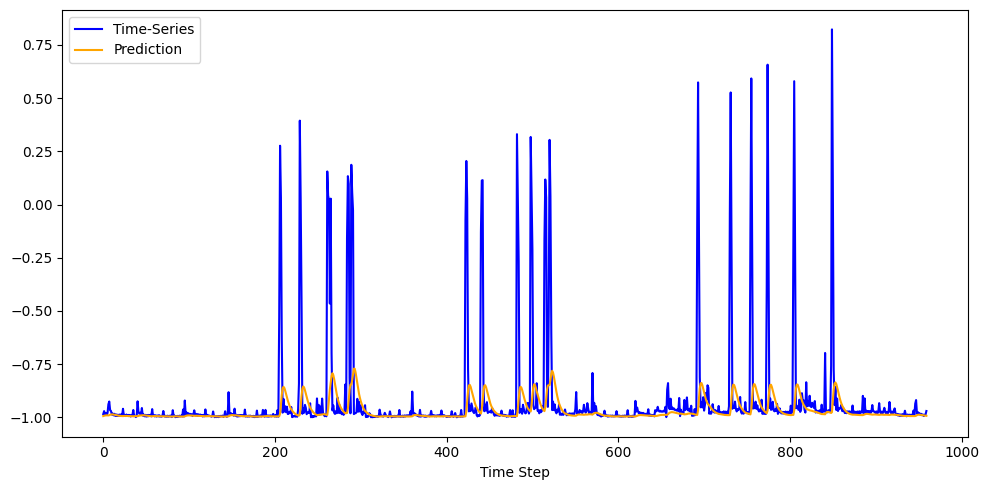

--------------
AWS Signal 9
--------------


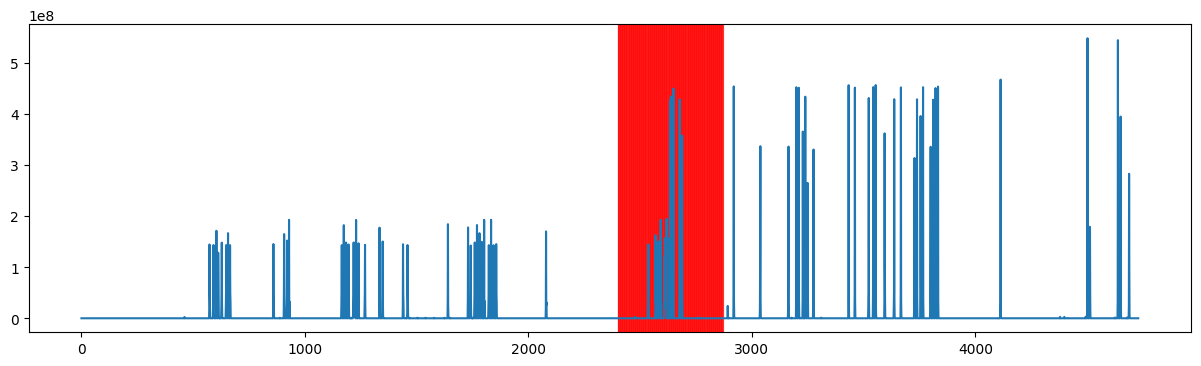

Epoch   5 | Train Loss: 0.017385 | Val Loss: 0.085146
Epoch  10 | Train Loss: 0.017285 | Val Loss: 0.085120
Epoch  15 | Train Loss: 0.017211 | Val Loss: 0.084890
Early stopping at epoch 18

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


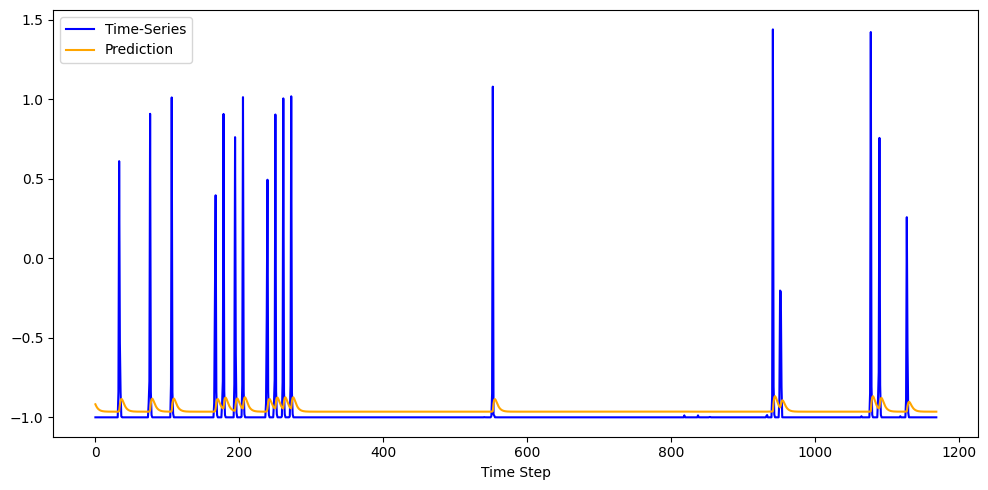

--------------
AWS Signal 10
--------------


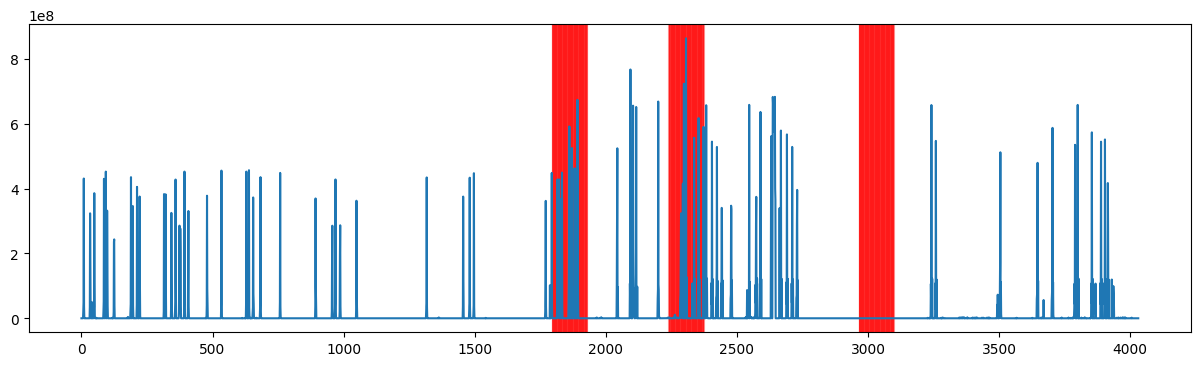

Epoch   5 | Train Loss: 0.031403 | Val Loss: 0.025333
Epoch  10 | Train Loss: 0.031682 | Val Loss: 0.025490
Epoch  15 | Train Loss: 0.031954 | Val Loss: 0.025875
Early stopping at epoch 19

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


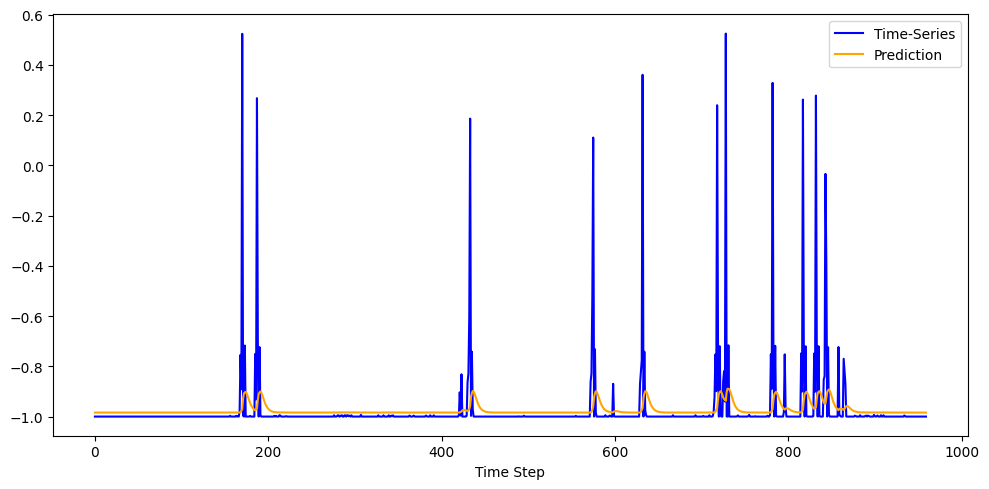

--------------
AWS Signal 11
--------------


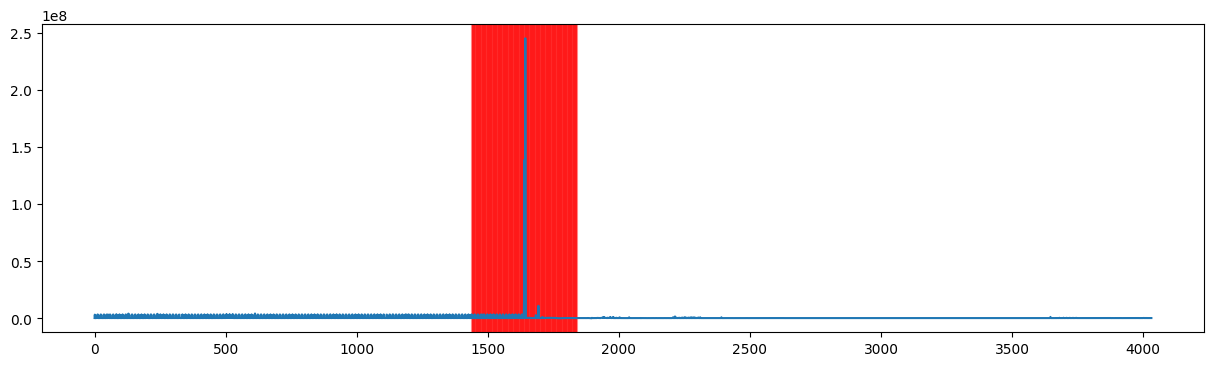

Epoch   5 | Train Loss: 0.003549 | Val Loss: 0.000004
Epoch  10 | Train Loss: 0.003716 | Val Loss: 0.000009
Epoch  15 | Train Loss: 0.003571 | Val Loss: 0.000004
Early stopping at epoch 19

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


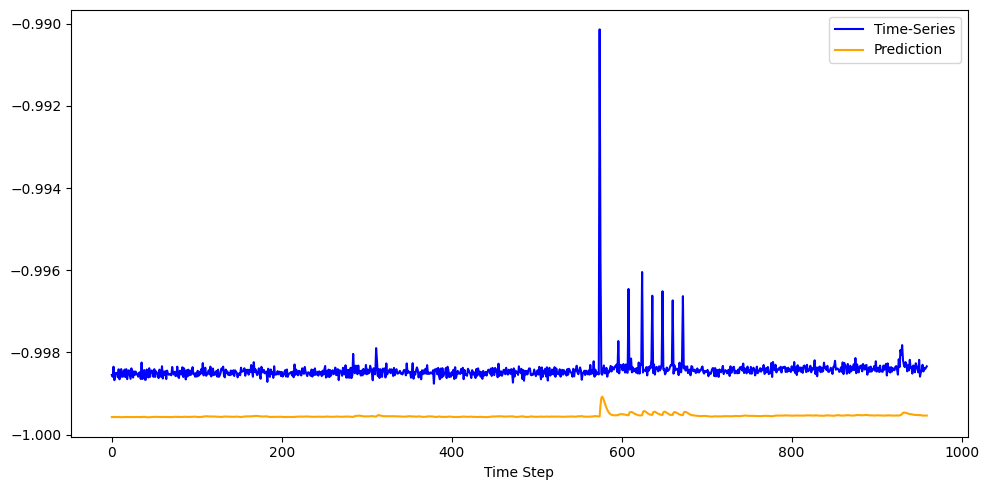

--------------
AWS Signal 12
--------------


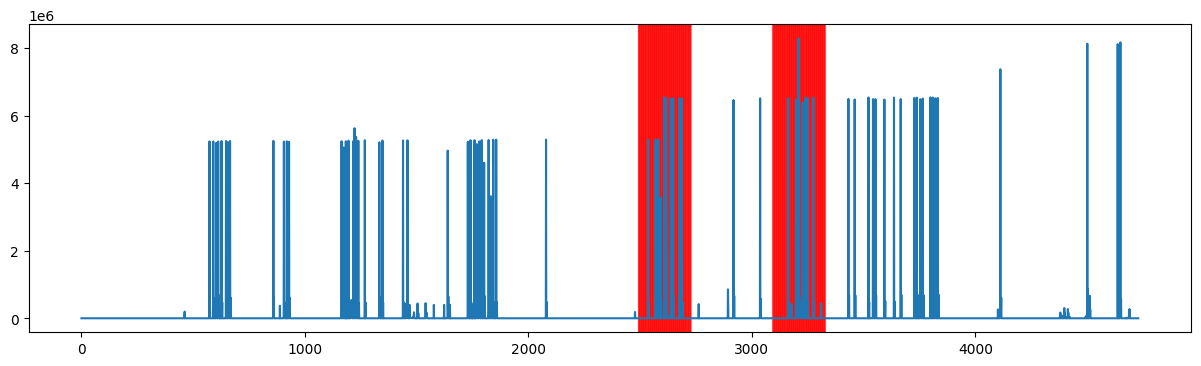

Epoch   5 | Train Loss: 0.053704 | Val Loss: 0.116197
Epoch  10 | Train Loss: 0.053797 | Val Loss: 0.116176
Epoch  15 | Train Loss: 0.054764 | Val Loss: 0.116337
Early stopping at epoch 18

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


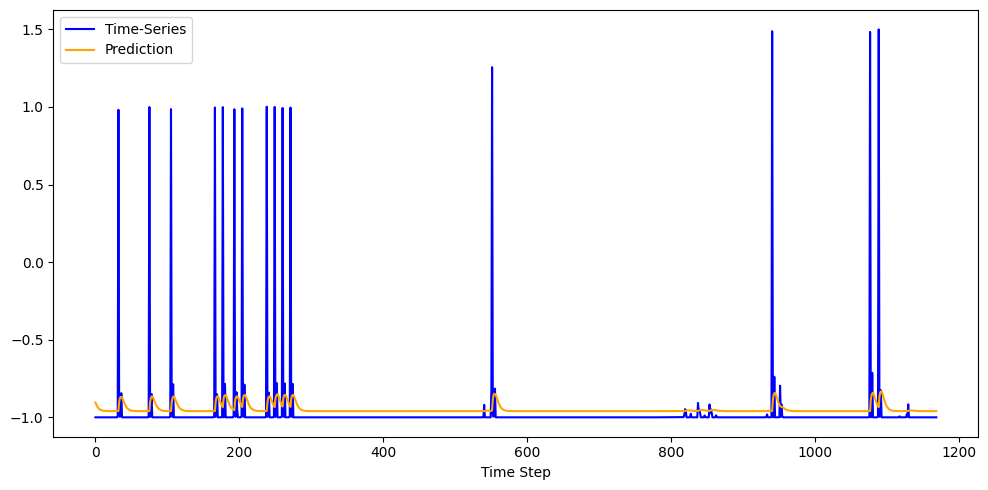

--------------
AWS Signal 13
--------------


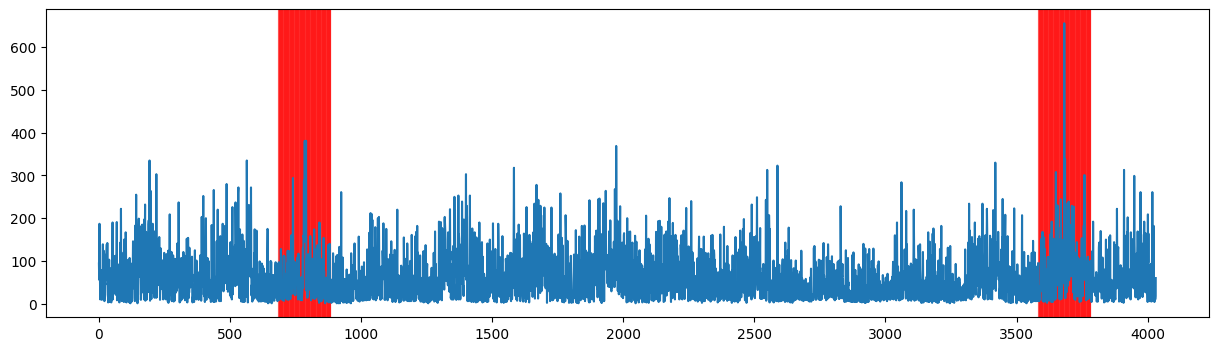

Epoch   5 | Train Loss: 0.086795 | Val Loss: 0.040342
Epoch  10 | Train Loss: 0.086366 | Val Loss: 0.039949
Epoch  15 | Train Loss: 0.086287 | Val Loss: 0.038947
Early stopping at epoch 18

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


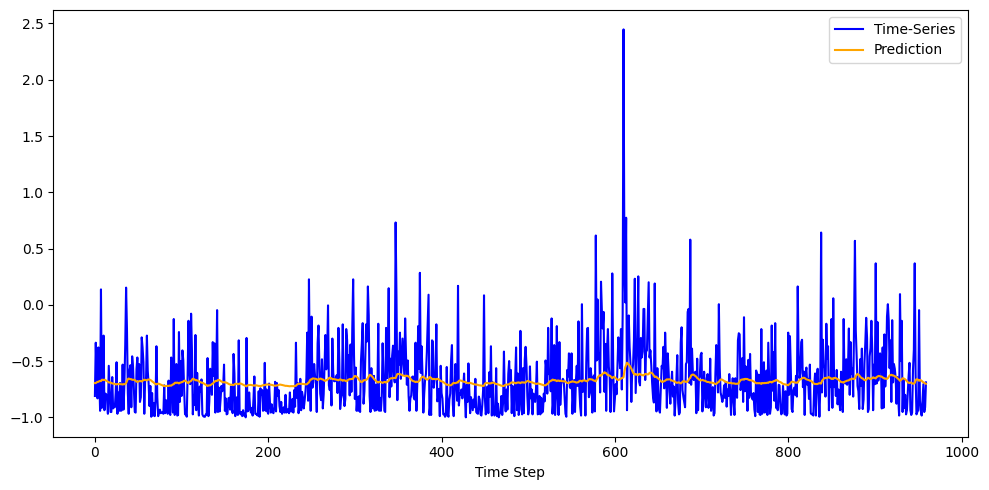

--------------
AWS Signal 14
--------------


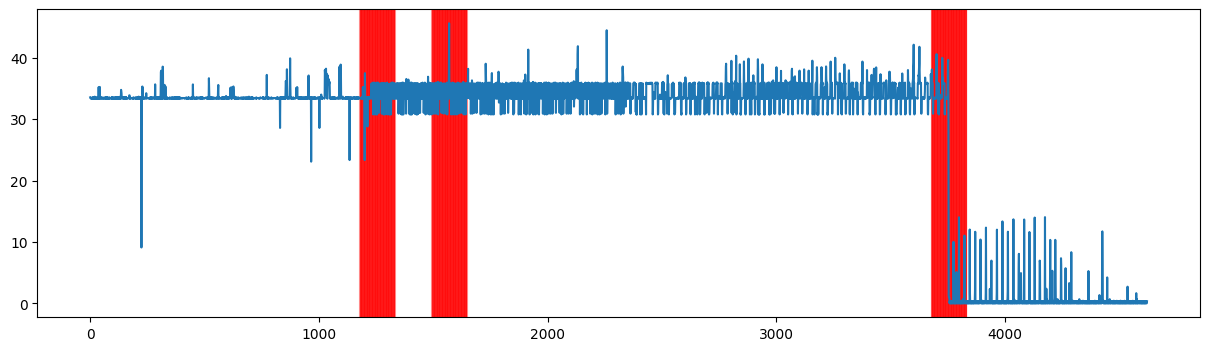

Epoch   5 | Train Loss: 0.006949 | Val Loss: 0.009820
Epoch  10 | Train Loss: 0.007002 | Val Loss: 0.009761
Epoch  15 | Train Loss: 0.007006 | Val Loss: 0.009735
Early stopping at epoch 17

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


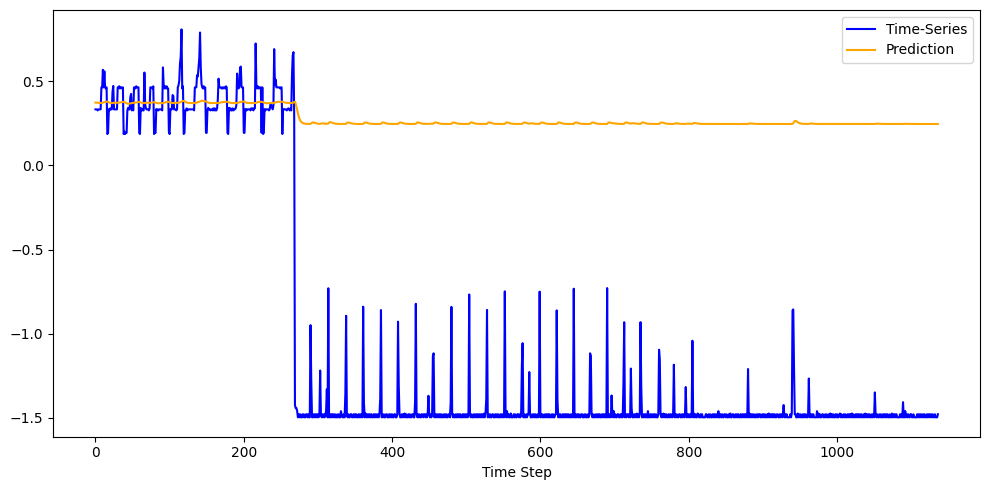

--------------
AWS Signal 15
--------------


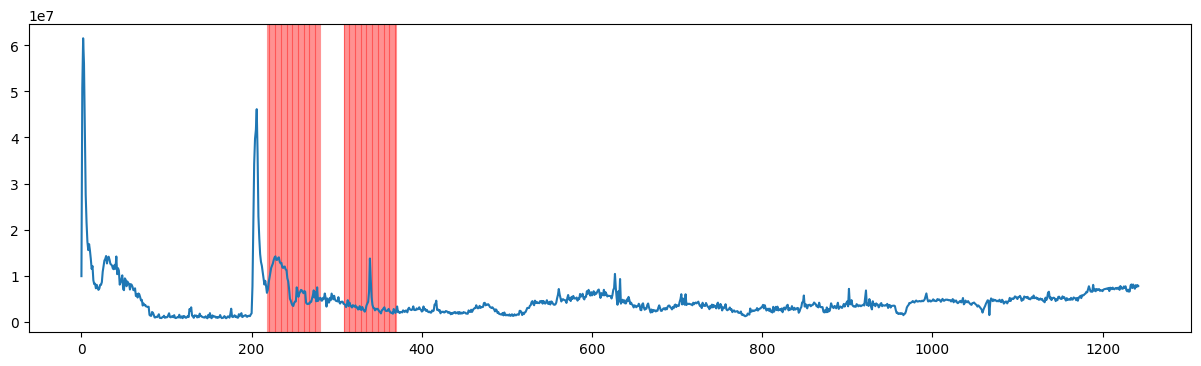

Epoch   5 | Train Loss: 0.598496 | Val Loss: 0.572131
Epoch  10 | Train Loss: 0.244743 | Val Loss: 0.212675
Epoch  15 | Train Loss: 0.006370 | Val Loss: 0.000033
Epoch  20 | Train Loss: 0.003276 | Val Loss: 0.000368
Epoch  25 | Train Loss: 0.003415 | Val Loss: 0.000008
Epoch  30 | Train Loss: 0.003489 | Val Loss: 0.000176
Early stopping at epoch 30

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


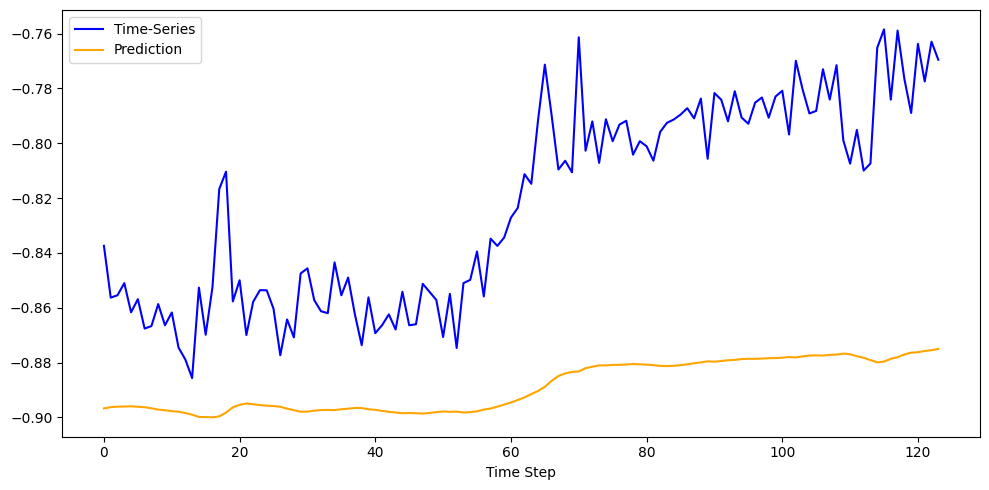

--------------
AWS Signal 16
--------------


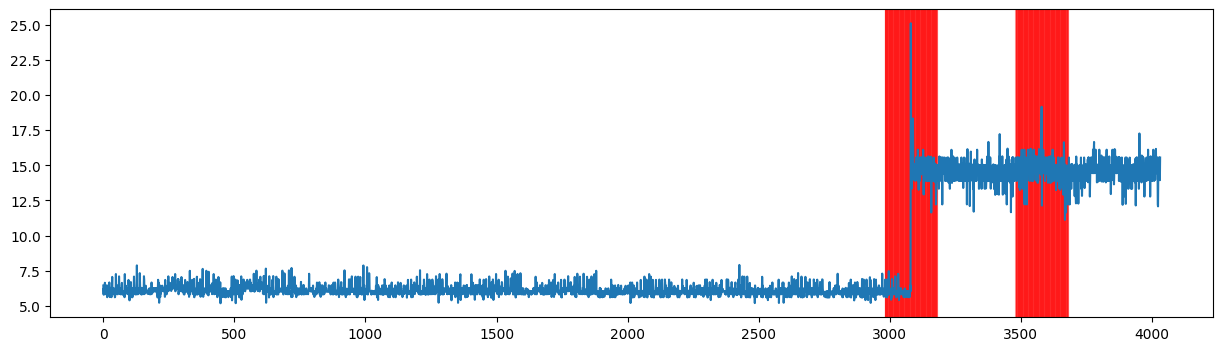

Epoch   5 | Train Loss: 0.064346 | Val Loss: 0.057837
Epoch  10 | Train Loss: 0.064460 | Val Loss: 0.057334
Epoch  15 | Train Loss: 0.064176 | Val Loss: 0.056930
Early stopping at epoch 17

Metrics
-------
Precision = 1.0000
Recall = 0.5000
F1 = 0.6667


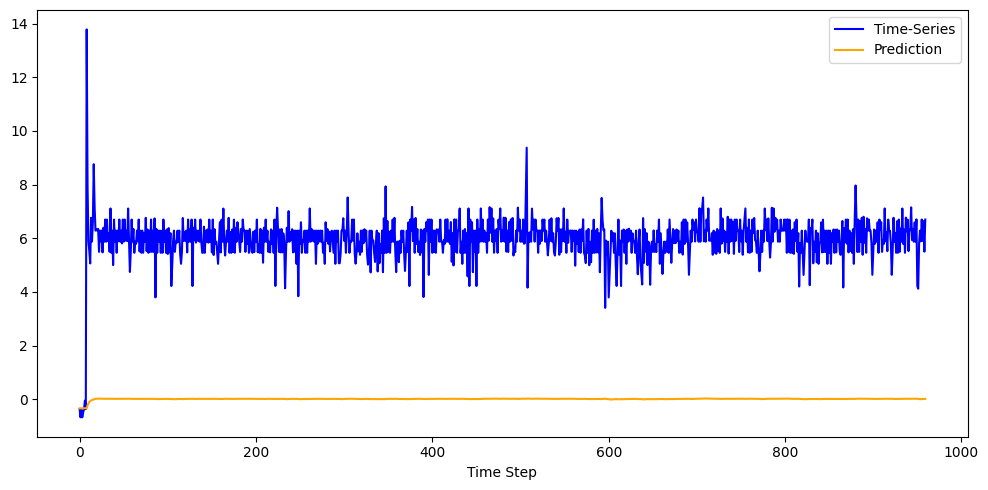

--------------
AWS Signal 17
--------------


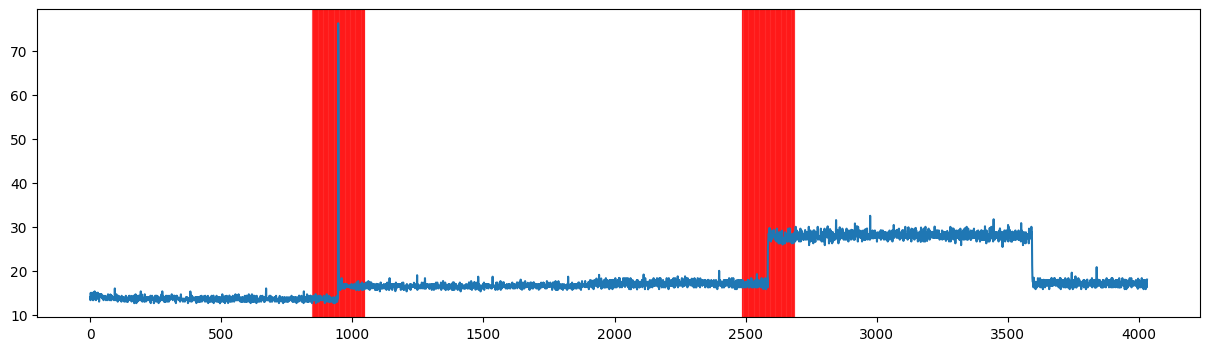

Epoch   5 | Train Loss: 0.005810 | Val Loss: 0.041005
Epoch  10 | Train Loss: 0.006389 | Val Loss: 0.036484
Epoch  15 | Train Loss: 0.006420 | Val Loss: 0.033032
Early stopping at epoch 17

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


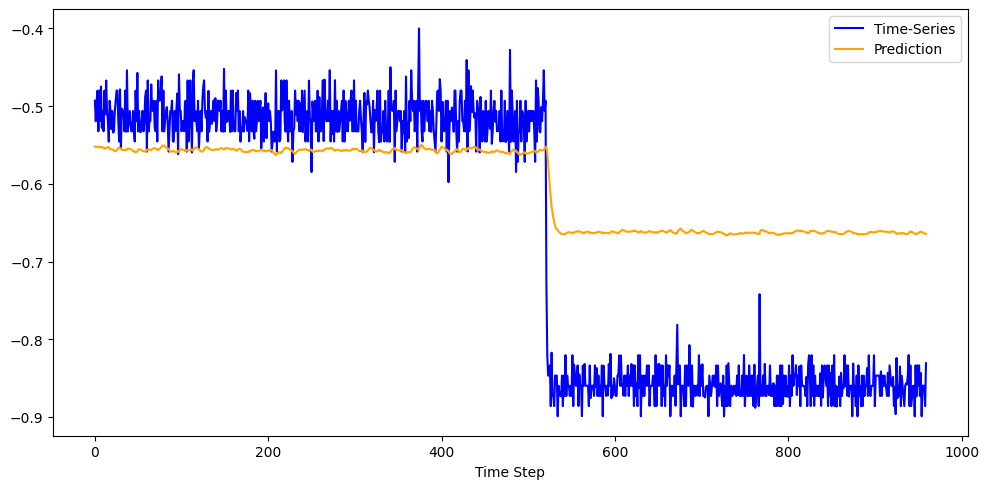

----------------------
AWS Cloudwatch Metrics
----------------------
Precision: 0.647
Recall: 0.618
F1: 0.627



In [51]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, aws_signal in enumerate(aws_signals):
    X = aws_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = aws_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"AWS Signal {i + 1}")
    print("--------------")
    plot_signal(X, y)
    
    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(aws_signals)
total_recall /= len(aws_signals)
total_f1 /= len(aws_signals)

print("----------------------")
print("AWS Cloudwatch Metrics")
print("----------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **Real Traffic**

In [20]:
traffic_signals = nab_download_subdataset(folder=TRAFFIC_FOLDER, file_names=TRAFFIC_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realTraffic/!
---------------------
Total Signals: 7
Total Points: 15664
Total Anomaly Points: 1560
Anomaly Rate: 9.96%


--------------
Traffic Signal 1
--------------


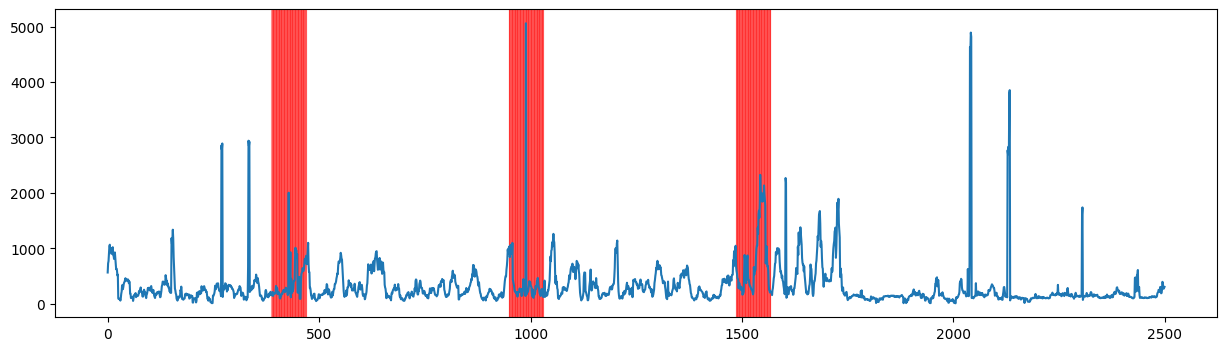

Epoch   5 | Train Loss: 0.017277 | Val Loss: 0.001307
Epoch  10 | Train Loss: 0.014390 | Val Loss: 0.006084
Epoch  15 | Train Loss: 0.014424 | Val Loss: 0.006045
Epoch  20 | Train Loss: 0.014155 | Val Loss: 0.005644
Early stopping at epoch 20

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


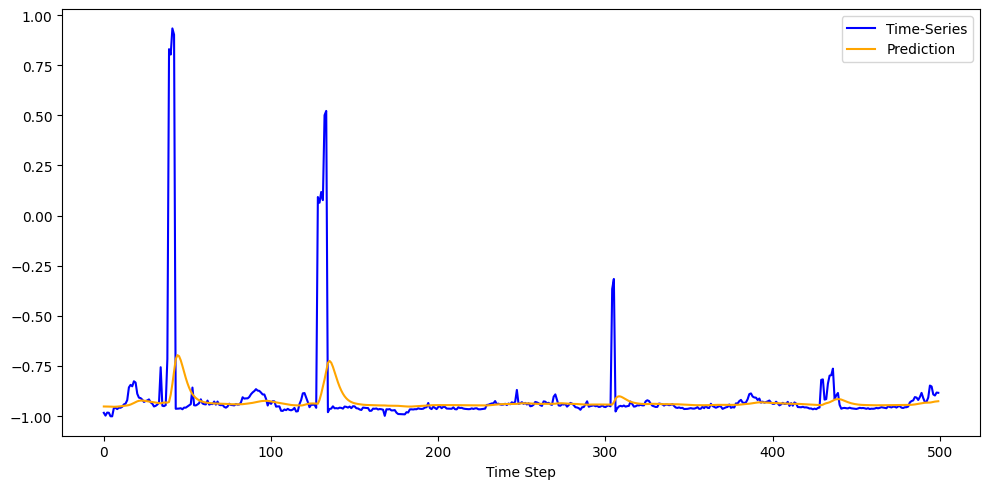

--------------
Traffic Signal 2
--------------


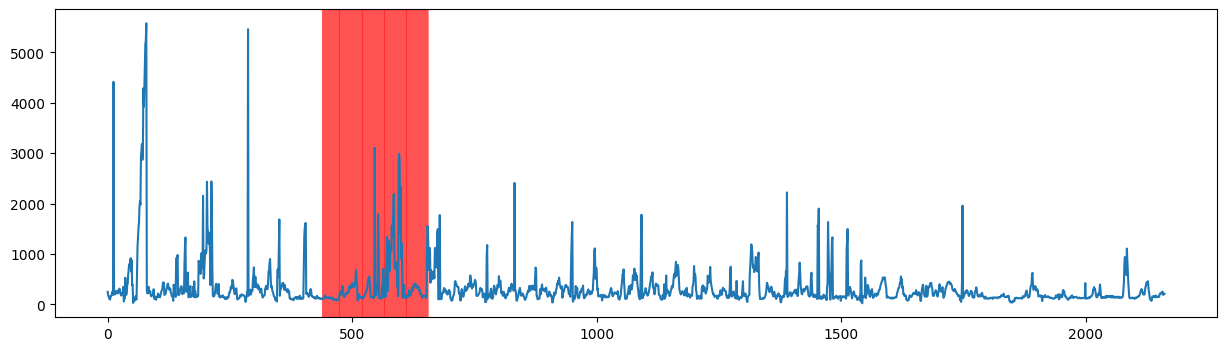

Epoch   5 | Train Loss: 0.018883 | Val Loss: 0.147463
Epoch  10 | Train Loss: 0.016942 | Val Loss: 0.109993
Epoch  15 | Train Loss: 0.016706 | Val Loss: 0.112030
Early stopping at epoch 18

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


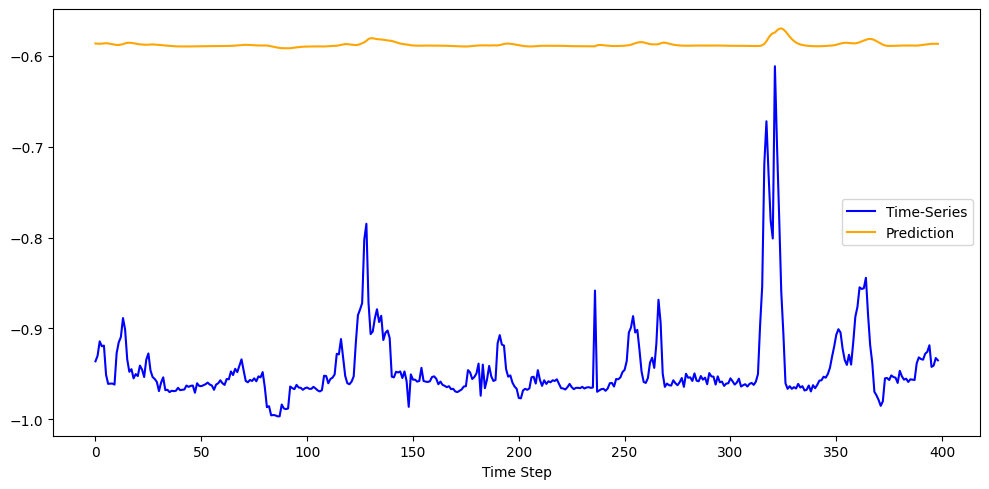

--------------
Traffic Signal 3
--------------


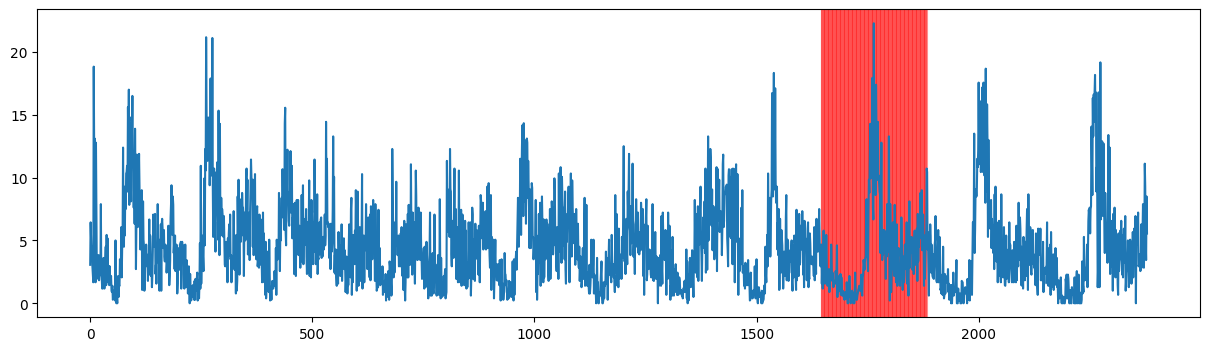

Epoch   5 | Train Loss: 0.072351 | Val Loss: 0.045789
Epoch  10 | Train Loss: 0.067913 | Val Loss: 0.049719
Epoch  15 | Train Loss: 0.062264 | Val Loss: 0.034962
Epoch  20 | Train Loss: 0.057514 | Val Loss: 0.024274
Epoch  25 | Train Loss: 0.055953 | Val Loss: 0.020447
Epoch  30 | Train Loss: 0.055718 | Val Loss: 0.018499
Epoch  35 | Train Loss: 0.055235 | Val Loss: 0.016046

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


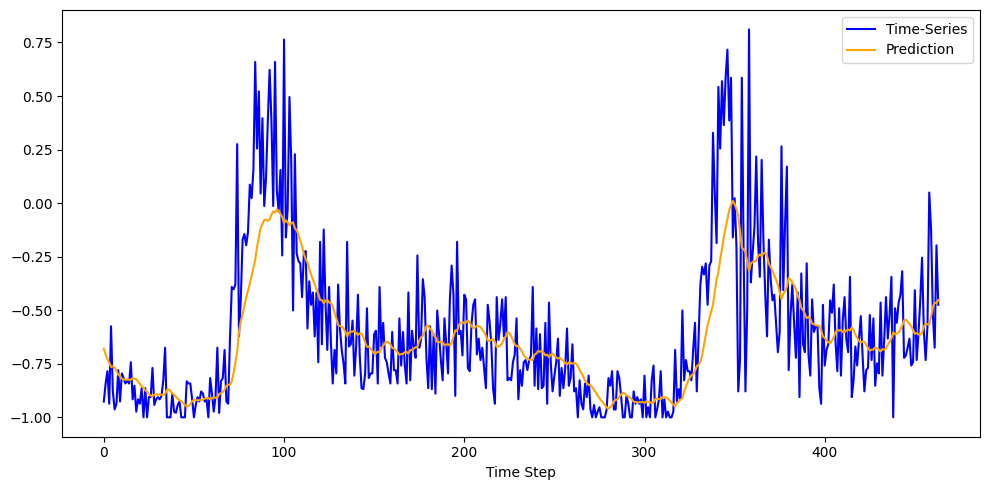

--------------
Traffic Signal 4
--------------


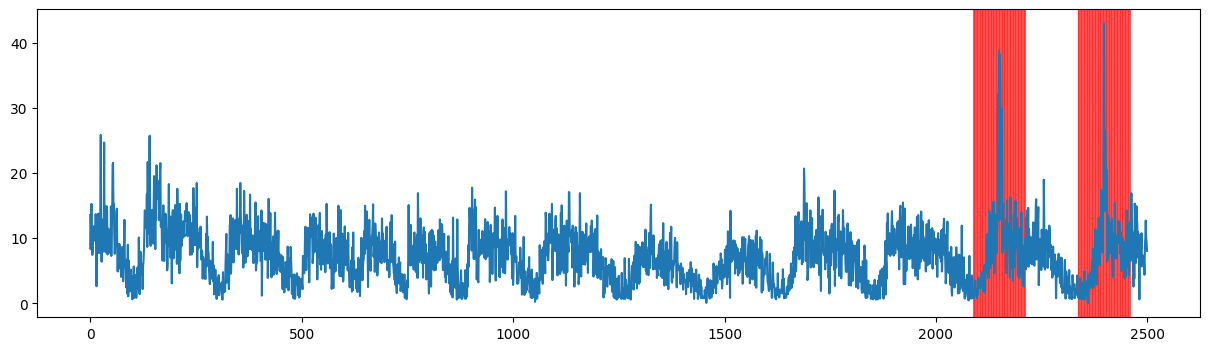

Epoch   5 | Train Loss: 0.073394 | Val Loss: 0.017260
Epoch  10 | Train Loss: 0.066244 | Val Loss: 0.019126
Epoch  15 | Train Loss: 0.058708 | Val Loss: 0.021663
Epoch  20 | Train Loss: 0.049959 | Val Loss: 0.031259
Early stopping at epoch 20

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


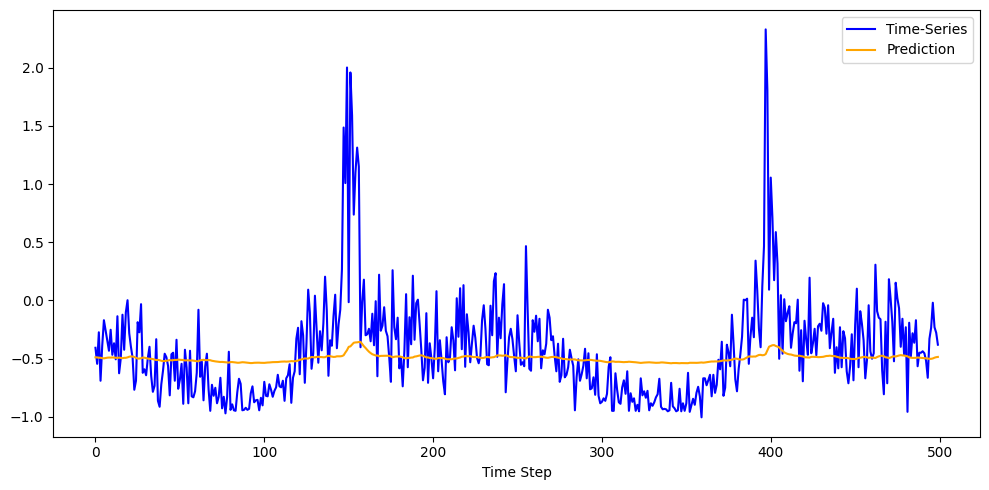

--------------
Traffic Signal 5
--------------


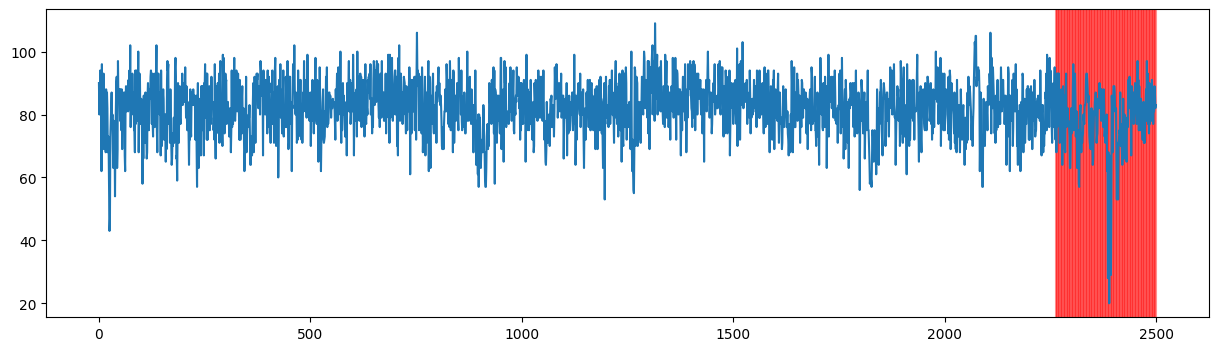

Epoch   5 | Train Loss: 0.061286 | Val Loss: 0.000068
Epoch  10 | Train Loss: 0.060217 | Val Loss: 0.000249
Epoch  15 | Train Loss: 0.059610 | Val Loss: 0.000678
Early stopping at epoch 17

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


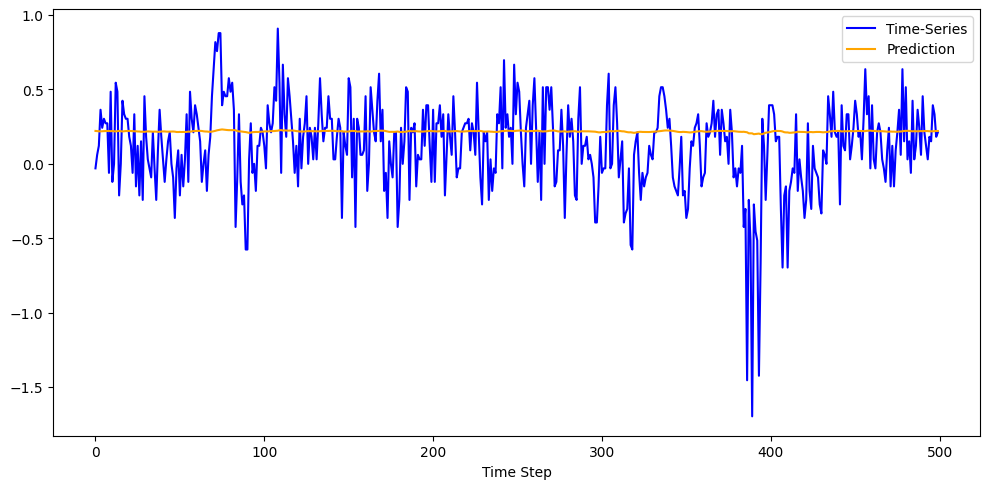

--------------
Traffic Signal 6
--------------


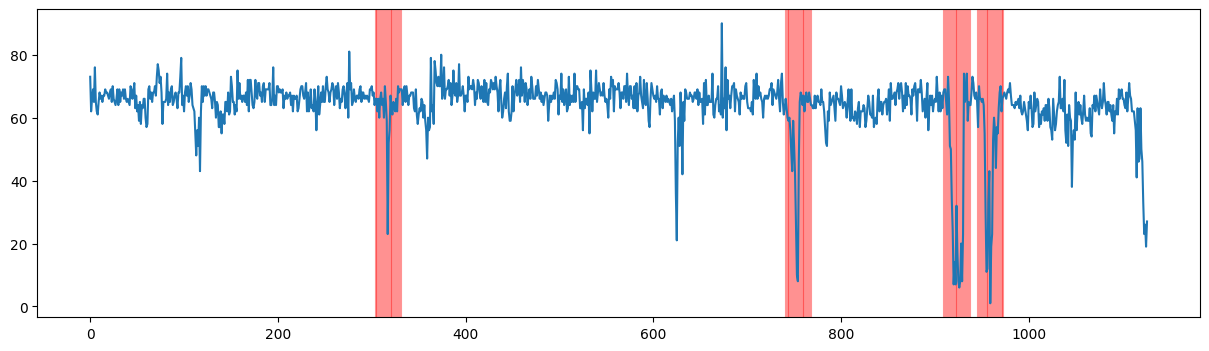

Epoch   5 | Train Loss: 0.193056 | Val Loss: 0.014766
Epoch  10 | Train Loss: 0.072003 | Val Loss: 0.004130
Epoch  15 | Train Loss: 0.028988 | Val Loss: 0.056554
Epoch  20 | Train Loss: 0.029353 | Val Loss: 0.060262
Early stopping at epoch 23

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


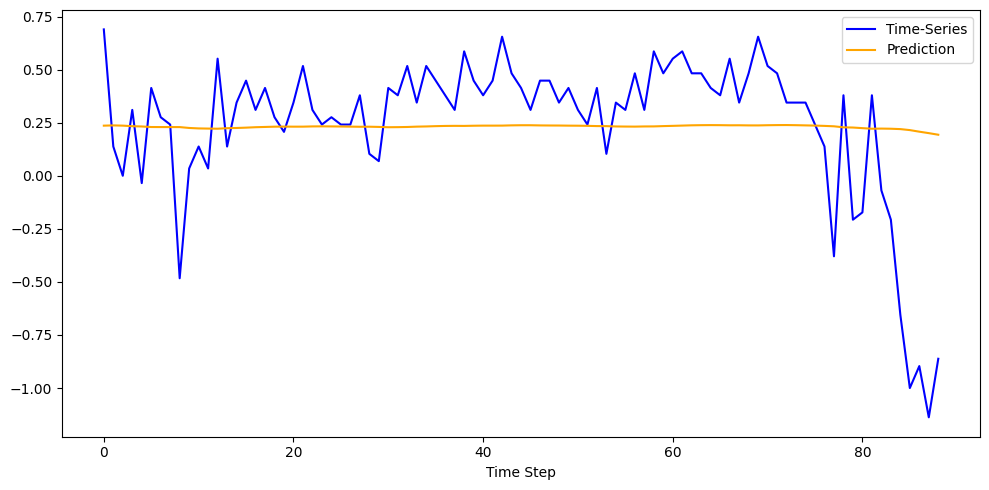

--------------
Traffic Signal 7
--------------


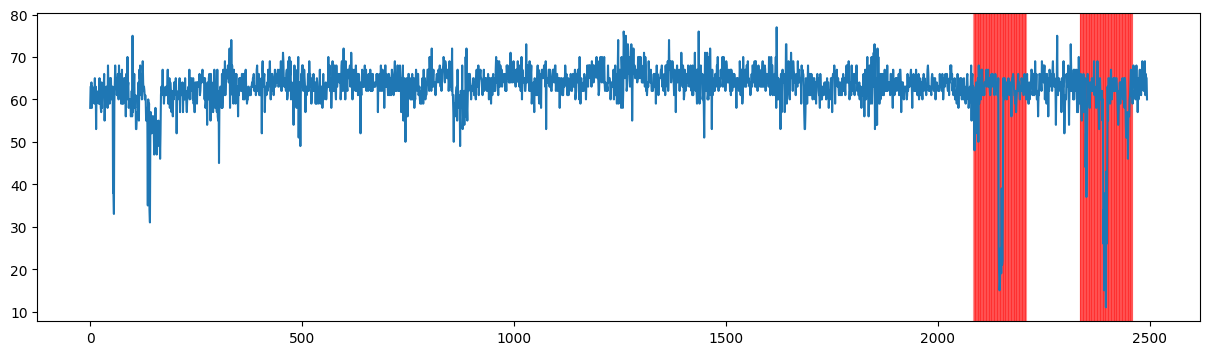

Epoch   5 | Train Loss: 0.022328 | Val Loss: 0.009032
Epoch  10 | Train Loss: 0.021782 | Val Loss: 0.007243
Epoch  15 | Train Loss: 0.021825 | Val Loss: 0.006763
Early stopping at epoch 18

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


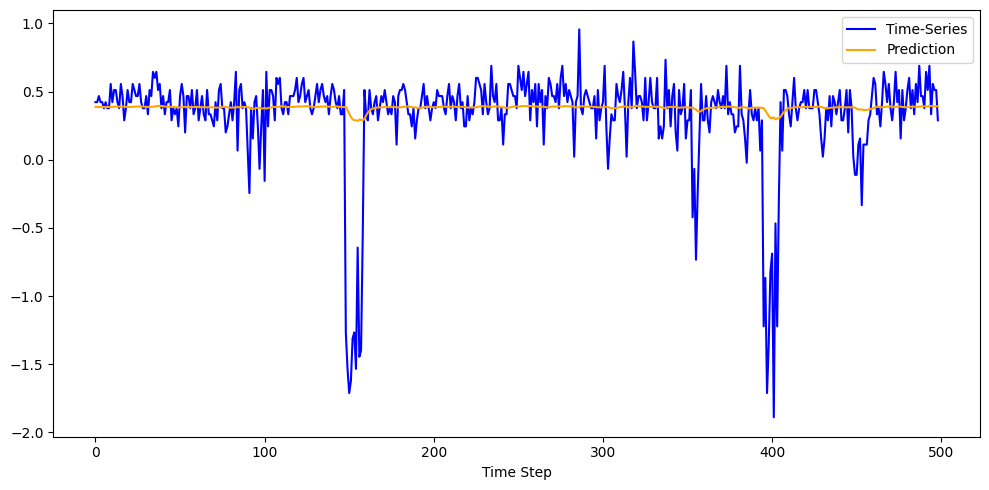

--------------------
Real Traffic Metrics
--------------------
Precision: 0.571
Recall: 0.571
F1: 0.571



In [21]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, traffic_signal in enumerate(traffic_signals):
    X = traffic_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = traffic_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"Traffic Signal {i + 1}")
    print("--------------")
    plot_signal(X, y)

    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(traffic_signals)
total_recall /= len(traffic_signals)
total_f1 /= len(traffic_signals)

print("--------------------")
print("Real Traffic Metrics")
print("--------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **Twitter**

In [22]:
twitter_signals = nab_download_subdataset(folder=TWEETS_FOLDER, file_names=TWEETS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.

Finished downloading realTweets/!
---------------------
Total Signals: 10
Total Points: 158631
Total Anomaly Points: 15651
Anomaly Rate: 9.87%


--------------
Twitter Signal 1
--------------


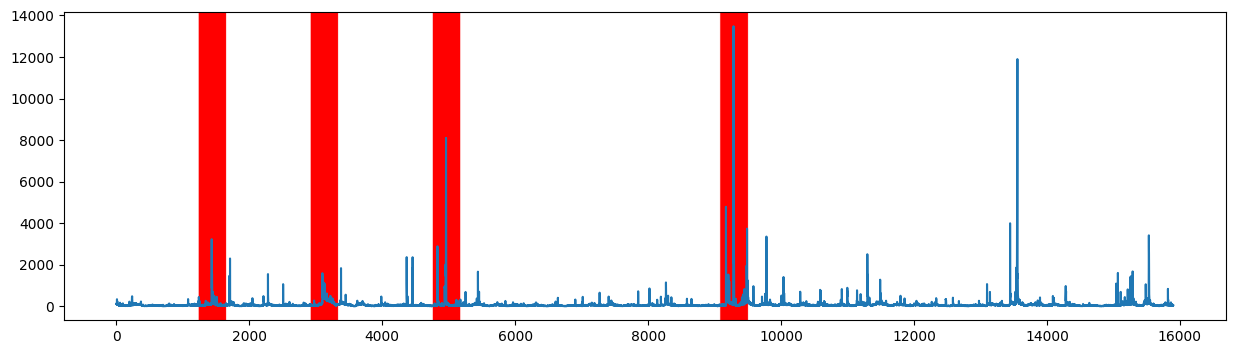

Epoch   5 | Train Loss: 0.002483 | Val Loss: 0.000667
Epoch  10 | Train Loss: 0.002334 | Val Loss: 0.001335
Epoch  15 | Train Loss: 0.002102 | Val Loss: 0.001407
Early stopping at epoch 16

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


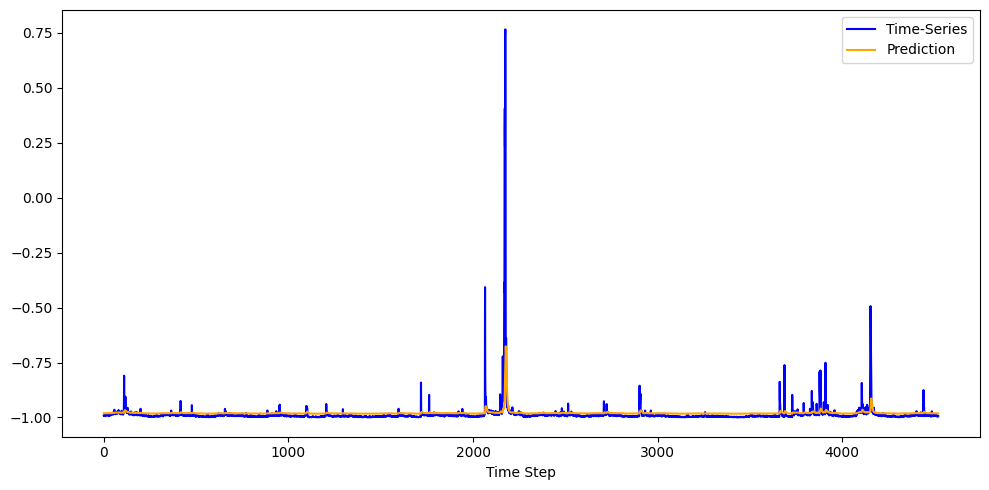

--------------
Twitter Signal 2
--------------


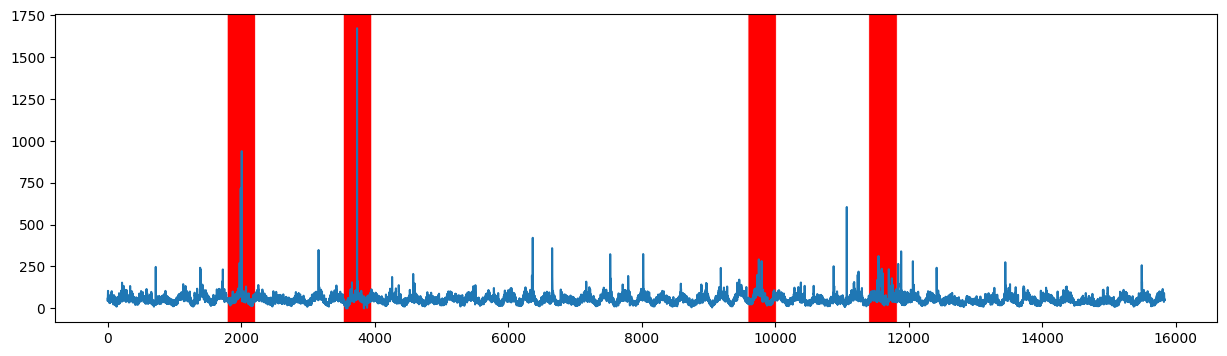

Epoch   5 | Train Loss: 0.002099 | Val Loss: 0.001398
Epoch  10 | Train Loss: 0.001943 | Val Loss: 0.001548
Epoch  15 | Train Loss: 0.001764 | Val Loss: 0.001659
Early stopping at epoch 16

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


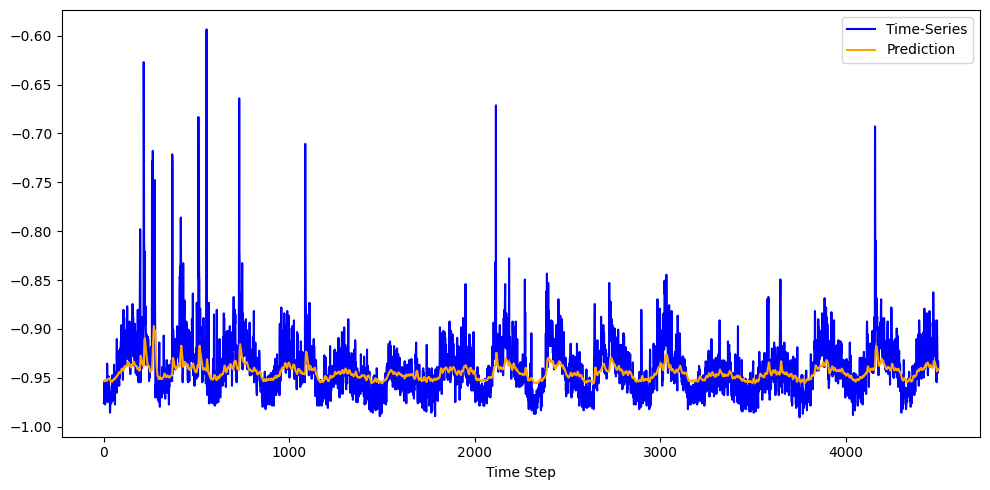

--------------
Twitter Signal 3
--------------


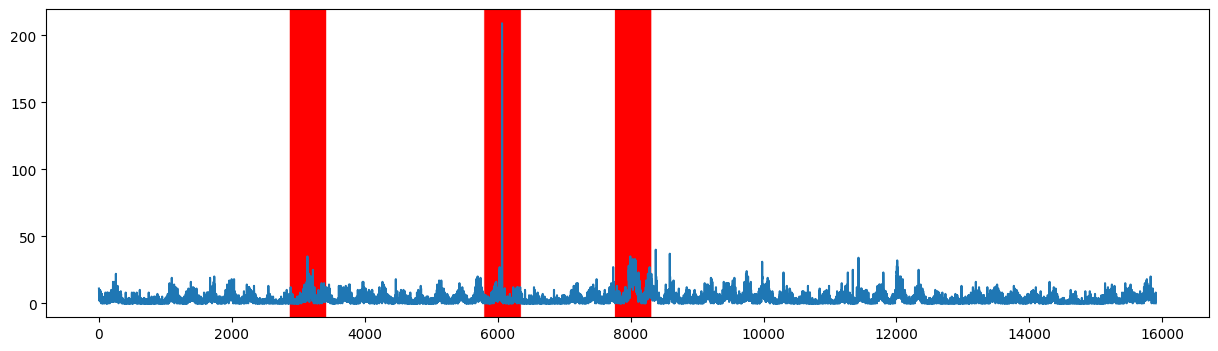

Epoch   5 | Train Loss: 0.003468 | Val Loss: 0.000688
Epoch  10 | Train Loss: 0.003069 | Val Loss: 0.000724
Epoch  15 | Train Loss: 0.002835 | Val Loss: 0.000879
Early stopping at epoch 16

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


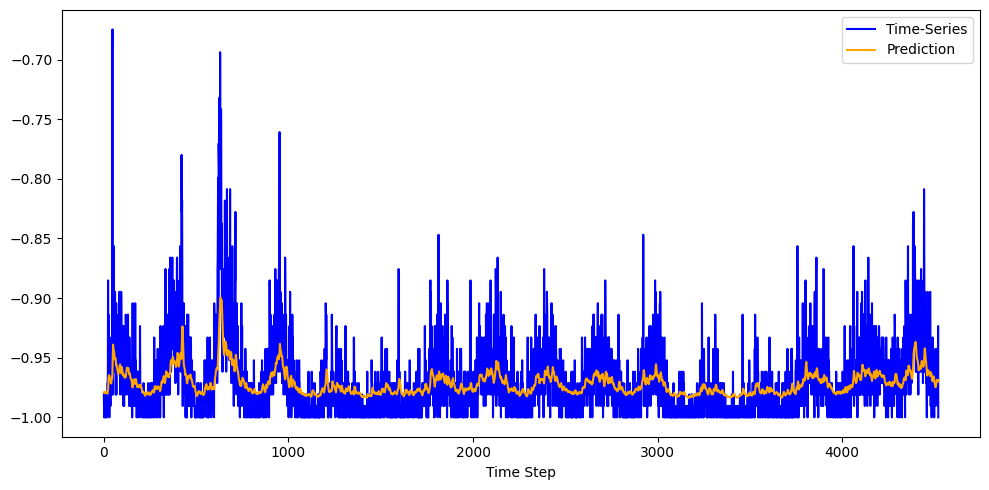

--------------
Twitter Signal 4
--------------


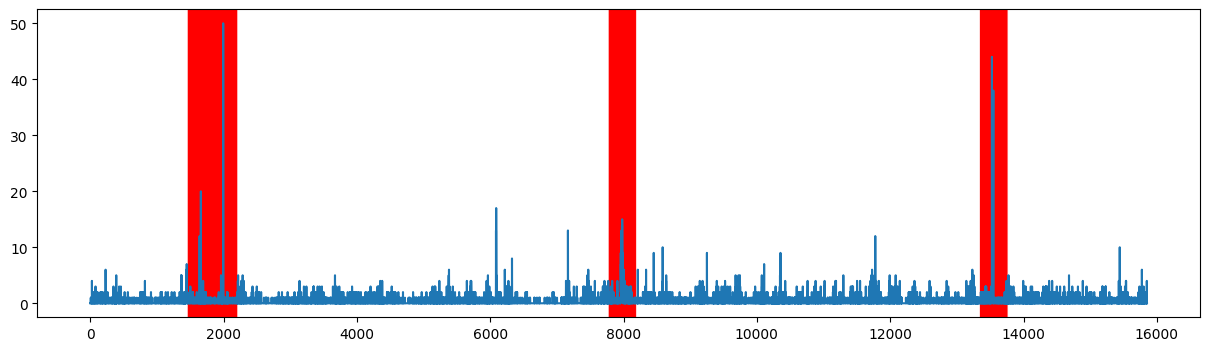

Epoch   5 | Train Loss: 0.002575 | Val Loss: 0.001012
Epoch  10 | Train Loss: 0.002318 | Val Loss: 0.000973
Epoch  15 | Train Loss: 0.002121 | Val Loss: 0.000999
Early stopping at epoch 16

Metrics
-------
Precision = 0.5000
Recall = 1.0000
F1 = 0.6667


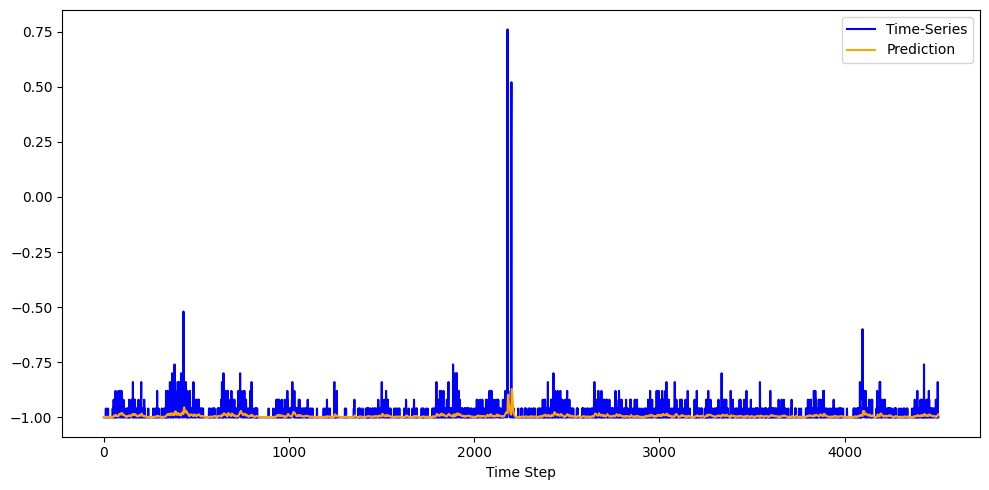

--------------
Twitter Signal 5
--------------


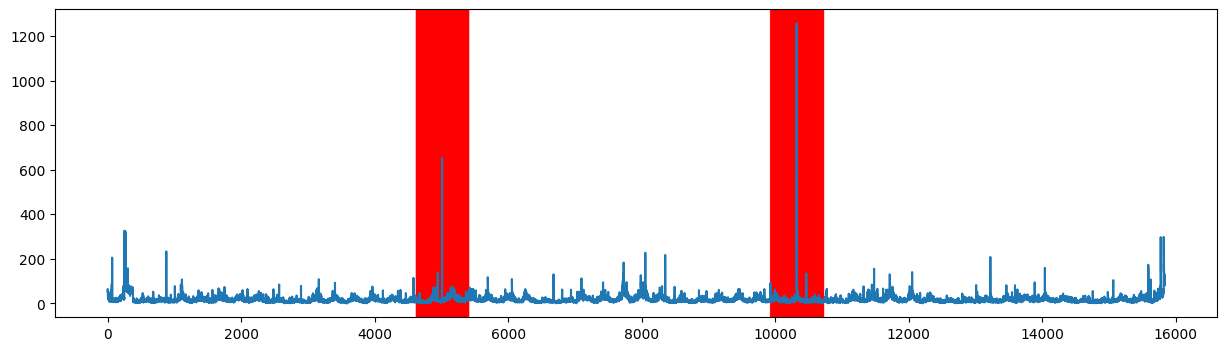

Epoch   5 | Train Loss: 0.003233 | Val Loss: 0.013433
Epoch  10 | Train Loss: 0.002984 | Val Loss: 0.013445
Epoch  15 | Train Loss: 0.002744 | Val Loss: 0.013402
Early stopping at epoch 16

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


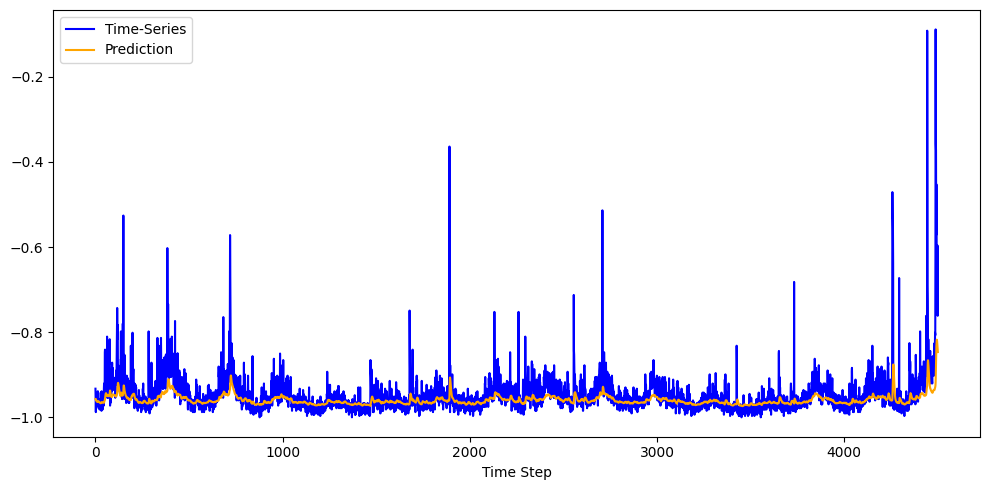

--------------
Twitter Signal 6
--------------


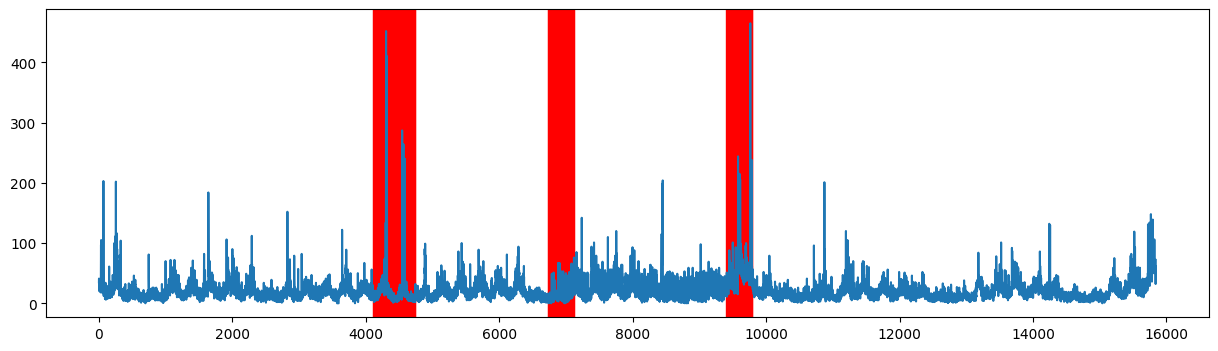

Epoch   5 | Train Loss: 0.005807 | Val Loss: 0.006775
Epoch  10 | Train Loss: 0.005354 | Val Loss: 0.006583
Epoch  15 | Train Loss: 0.004955 | Val Loss: 0.006572
Epoch  20 | Train Loss: 0.004609 | Val Loss: 0.006366
Epoch  25 | Train Loss: 0.004325 | Val Loss: 0.006333
Epoch  30 | Train Loss: 0.004226 | Val Loss: 0.006320
Epoch  35 | Train Loss: 0.004084 | Val Loss: 0.006277

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


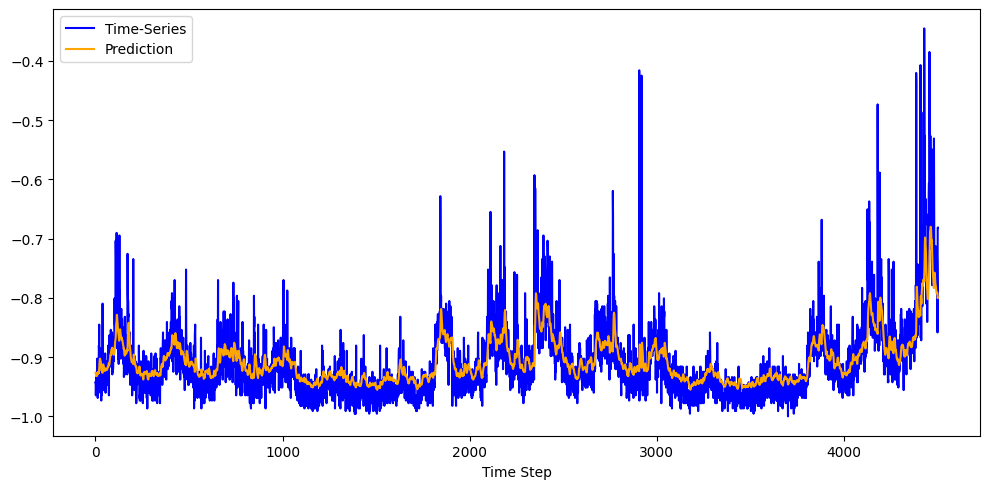

--------------
Twitter Signal 7
--------------


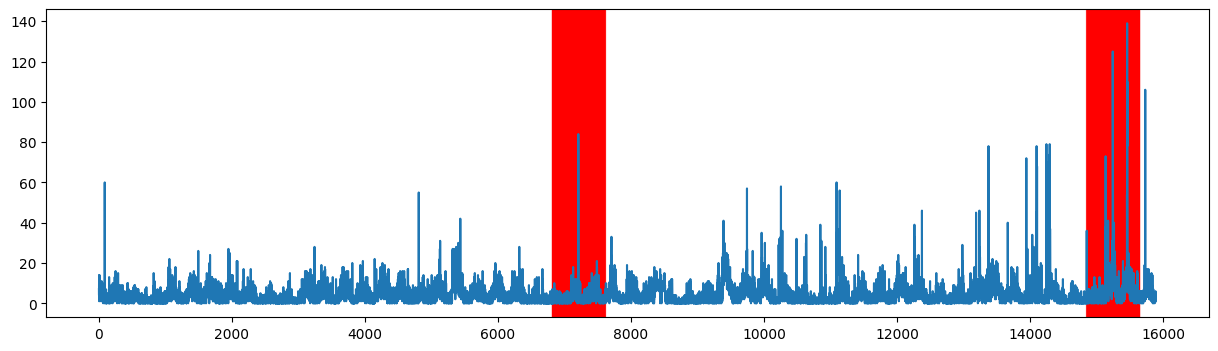

Epoch   5 | Train Loss: 0.008939 | Val Loss: 0.013899
Epoch  10 | Train Loss: 0.008273 | Val Loss: 0.013709
Epoch  15 | Train Loss: 0.007533 | Val Loss: 0.013794
Epoch  20 | Train Loss: 0.007102 | Val Loss: 0.014065
Early stopping at epoch 21

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


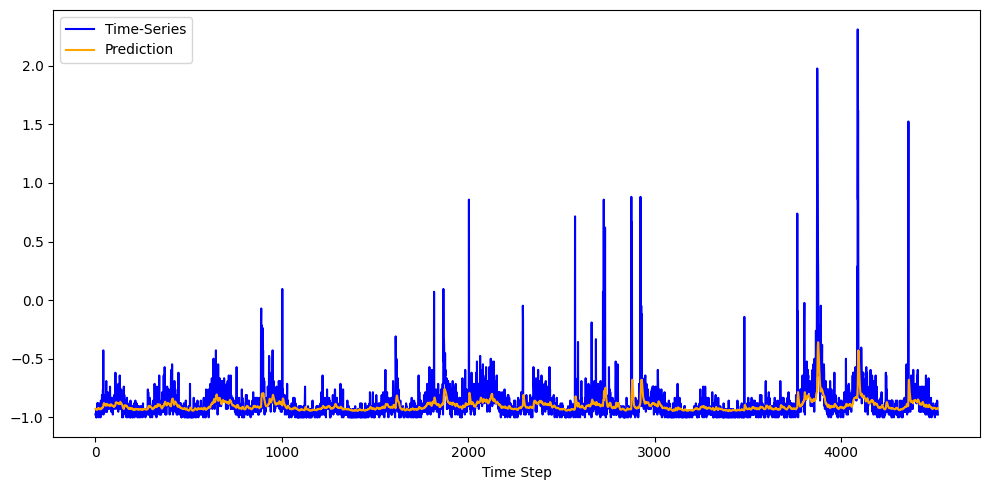

--------------
Twitter Signal 8
--------------


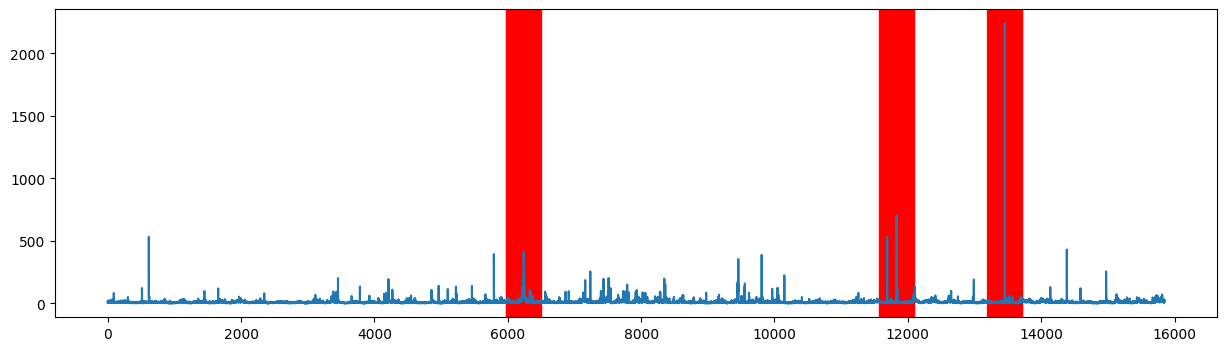

Epoch   5 | Train Loss: 0.004460 | Val Loss: 0.003306
Epoch  10 | Train Loss: 0.004227 | Val Loss: 0.003161
Epoch  15 | Train Loss: 0.003899 | Val Loss: 0.003222
Early stopping at epoch 16

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


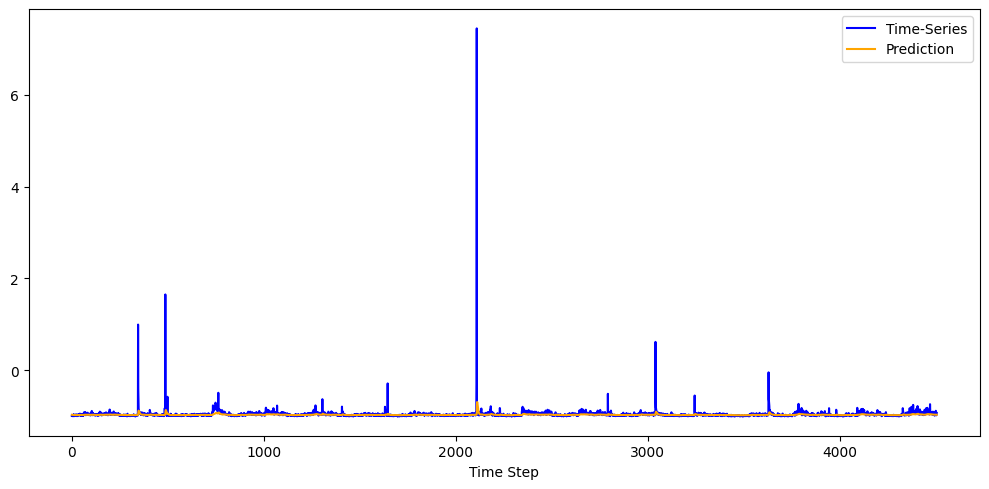

--------------
Twitter Signal 9
--------------


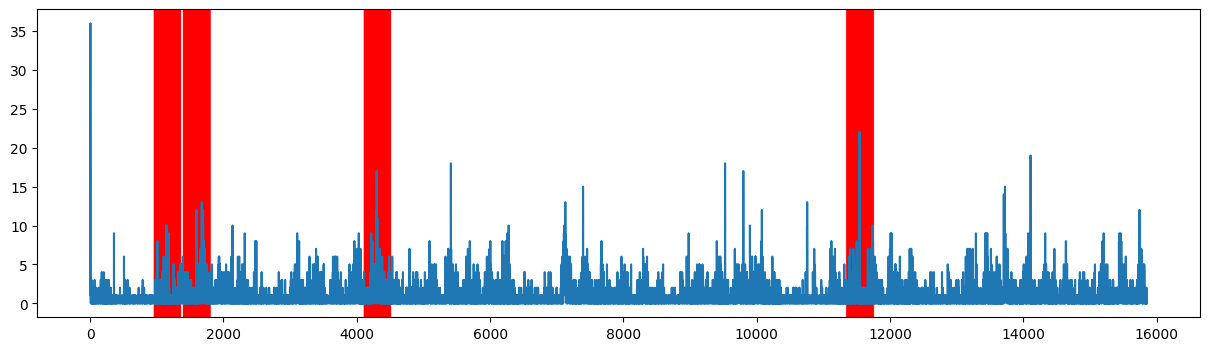

Epoch   5 | Train Loss: 0.006429 | Val Loss: 0.005115
Epoch  10 | Train Loss: 0.006203 | Val Loss: 0.005214
Epoch  15 | Train Loss: 0.006008 | Val Loss: 0.005151
Early stopping at epoch 16

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


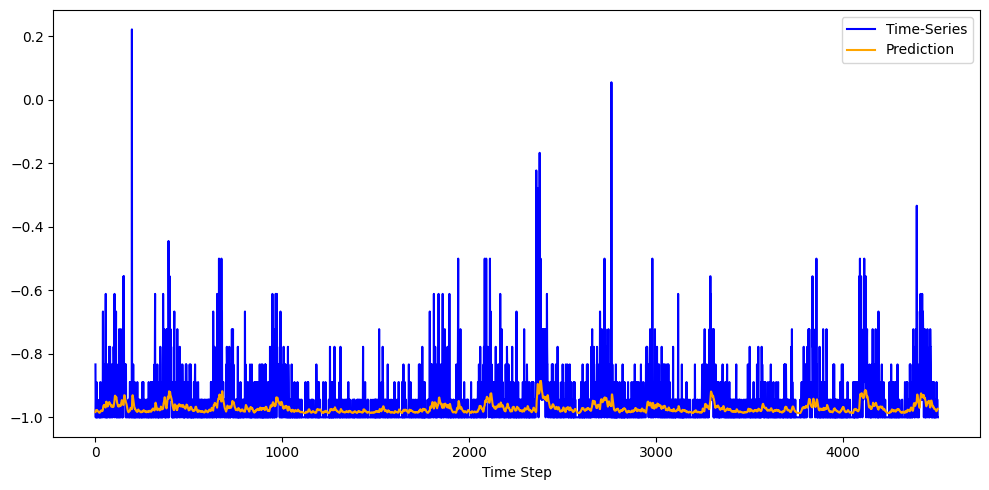

--------------
Twitter Signal 10
--------------


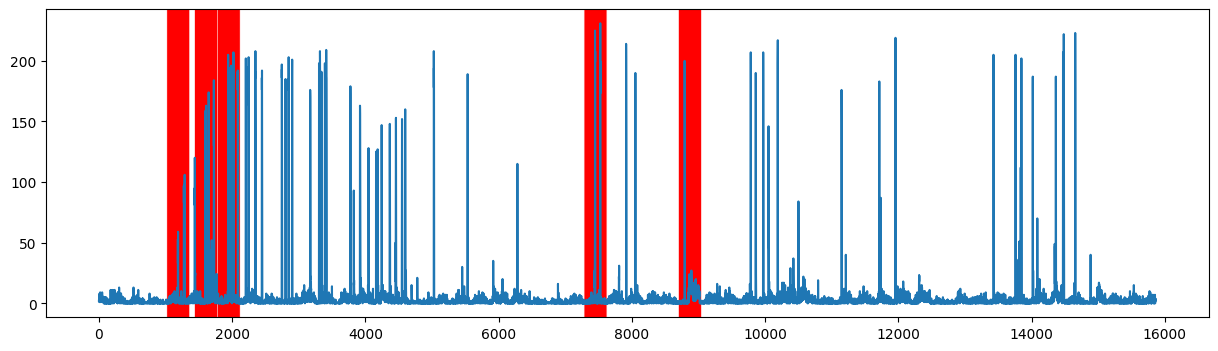

Epoch   5 | Train Loss: 0.035165 | Val Loss: 0.026923
Epoch  10 | Train Loss: 0.030442 | Val Loss: 0.023158
Epoch  15 | Train Loss: 0.024632 | Val Loss: 0.018656
Epoch  20 | Train Loss: 0.017680 | Val Loss: 0.013592
Epoch  25 | Train Loss: 0.012605 | Val Loss: 0.010934
Epoch  30 | Train Loss: 0.010931 | Val Loss: 0.009810
Epoch  35 | Train Loss: 0.010681 | Val Loss: 0.009513

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


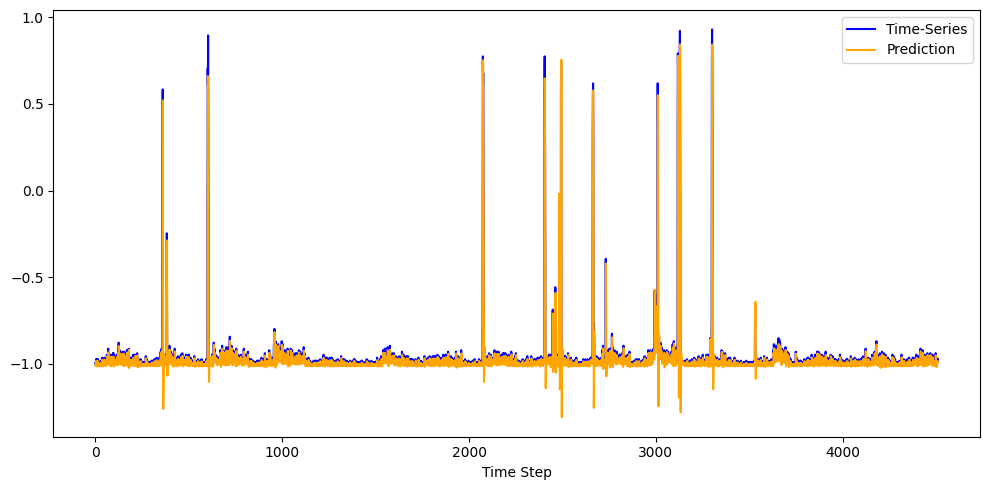

---------------
Twitter Metrics
---------------
Precision: 0.142
Recall: 0.400
F1: 0.207



In [23]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, twitter_signal in enumerate(twitter_signals):
    X = twitter_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = twitter_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"Twitter Signal {i + 1}")
    print("--------------")
    plot_signal(X, y)

    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(twitter_signals)
total_recall /= len(twitter_signals)
total_f1 /= len(twitter_signals)

print("---------------")
print("Twitter Metrics")
print("---------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

## **Yahoo S5**

In [24]:
A1_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A1Benchmark/"
A1_FILE_NAME = "real_"
A1_N_FILES = 67

A2_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A2Benchmark/"
A2_FILE_NAME = "synthetic_"
A2_N_FILES = 100

A3_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A3Benchmark/"
A3_FILE_NAME = "A3Benchmark-TS"
A3_N_FILES = 100

A4_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A4Benchmark/"
A4_FILE_NAME = "A4Benchmark-TS"
A4_N_FILES = 100

In [25]:
YAHOO_HYPERPARAMS = {
    "train_ratio": 0.6,
    "val_ratio": 0.1,
    "lr": 1e-4,
    "epochs": 35,
    "patience": 15,
    "device": device,
    "anomaly_type": "contextual",
    "verbose": False,
}

In [26]:
def yahoo_download_subdataset(folder: str, file_name: str, n_files: int) -> t.List[pd.DataFrame]:
    yahoo_signals = []
    yahoo_points = 0
    yahoo_anomalies = 0

    for i in range(1, n_files + 1):
        # name of the .csv in the repository
        yahoo_fn = f"{file_name}{i}.csv"
        # url to the raw .csv file in the repository
        yahoo_url = f"{folder}{yahoo_fn}"
        yahoo_df = pd.read_csv(yahoo_url)
        yahoo_df = yahoo_df.rename(columns={"anomaly": "is_anomaly", "timestamps": "timestamp"})
        
        # count the number of points and the number of anomaly points
        yahoo_points += len(yahoo_df)
        yahoo_anomalies += (yahoo_df["is_anomaly"] == 1).sum()
        yahoo_signals.append(yahoo_df)

        if i % 10 == 0:
            print(f"Downloaded {i} .csv files.")

    print()
    print("Finished downloading!")
    print("---------------------")
    print(f"A1 Total Signals: {A1_N_FILES}")
    print(F"A1 Total Points: {yahoo_points}")
    print(f"A1 Total Anomaly Points: {yahoo_anomalies}")
    print(f"A1 Anomaly Rate: {(yahoo_anomalies / yahoo_points) * 100:.2f}%")

    return yahoo_signals

### **A1**

In [27]:
a1_signals = yahoo_download_subdataset(folder=A1_FOLDER, file_name=A1_FILE_NAME, n_files=A1_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 94866
A1 Total Anomaly Points: 1669
A1 Anomaly Rate: 1.76%


In [28]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a1_signal in enumerate(a1_signals):
    X = a1_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a1_signal['is_anomaly'].to_numpy()

    if (i + 1) % 5 == 0:
        print(f"A1 Signal {i + 1}...")

    try:
        precision, recall, f1, = run_pipeline(X, y, **YAHOO_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A1 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A1 Signal 5...
A1 Signal 10...
A1 Signal 15...
A1 Signal 20...
A1 Signal 25...
A1 Signal 30...
A1 Signal 35...
A1 Signal 40...
A1 Signal 45...
A1 Signal 50...
A1 Signal 55...
A1 Signal 60...
A1 Signal 65...
----------
A1 Metrics
----------
Precision: 0.462
Recall: 0.462
F1: 0.462



### **A2**

In [29]:
A2_HYPERPARAMS = YAHOO_HYPERPARAMS.copy()
A2_HYPERPARAMS["train_ratio"] = 0.4

In [30]:
a2_signals = yahoo_download_subdataset(folder=A2_FOLDER, file_name=A2_FILE_NAME, n_files=A2_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.
Downloaded 70 .csv files.
Downloaded 80 .csv files.
Downloaded 90 .csv files.
Downloaded 100 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 142100
A1 Total Anomaly Points: 466
A1 Anomaly Rate: 0.33%


In [31]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a2_signal in enumerate(a2_signals):
    X = a2_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a2_signal['is_anomaly'].to_numpy()
    
    if (i + 1) % 5 == 0:
        print(f"A2 Signal {i + 1}...")
    try:
        precision, recall, f1, = run_pipeline(X, y, **A2_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A2 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A2 Signal 5...
A2 Signal 10...
A2 Signal 15...
A2 Signal 20...
A2 Signal 25...
A2 Signal 30...
A2 Signal 35...
A2 Signal 40...
A2 Signal 45...
A2 Signal 50...
A2 Signal 55...
A2 Signal 60...
A2 Signal 65...
A2 Signal 70...
A2 Signal 75...
A2 Signal 80...
A2 Signal 85...
A2 Signal 90...
A2 Signal 95...
A2 Signal 100...
----------
A2 Metrics
----------
Precision: 1.000
Recall: 1.000
F1: 1.000



### **A3**

In [32]:
A3_HYPERPARAMS = YAHOO_HYPERPARAMS.copy()
A3_HYPERPARAMS["train_ratio"] = 0.4

In [33]:
a3_signals = yahoo_download_subdataset(folder=A3_FOLDER, file_name=A3_FILE_NAME, n_files=A3_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.
Downloaded 70 .csv files.
Downloaded 80 .csv files.
Downloaded 90 .csv files.
Downloaded 100 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 168000
A1 Total Anomaly Points: 943
A1 Anomaly Rate: 0.56%


In [34]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a3_signal in enumerate(a3_signals):
    X = a3_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a3_signal['is_anomaly'].to_numpy()
    
    if (i + 1) % 5 == 0:
        print(f"A3 Signal {i + 1}...")

    try:
        precision, recall, f1, = run_pipeline(X, y, **A3_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A3 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A3 Signal 5...
A3 Signal 10...
A3 Signal 15...
A3 Signal 20...
A3 Signal 25...
A3 Signal 30...
A3 Signal 35...
A3 Signal 40...
A3 Signal 45...
A3 Signal 50...
A3 Signal 55...
A3 Signal 60...
A3 Signal 65...
A3 Signal 70...
A3 Signal 75...
A3 Signal 80...
A3 Signal 85...
A3 Signal 90...
A3 Signal 95...
A3 Signal 100...
----------
A3 Metrics
----------
Precision: 0.980
Recall: 0.980
F1: 0.980



### **A4**

In [35]:
A4_HYPERPARAMS = YAHOO_HYPERPARAMS.copy()
A4_HYPERPARAMS["train_ratio"] = 0.4

In [36]:
a4_signals = yahoo_download_subdataset(folder=A4_FOLDER, file_name=A4_FILE_NAME, n_files=A4_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.
Downloaded 70 .csv files.
Downloaded 80 .csv files.
Downloaded 90 .csv files.
Downloaded 100 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 168000
A1 Total Anomaly Points: 837
A1 Anomaly Rate: 0.50%


In [37]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a4_signal in enumerate(a4_signals):
    X = a4_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a4_signal['is_anomaly'].to_numpy()
    
    if (i + 1) % 5 == 0:
        print(f"A4 Signal {i + 1}...")

    try:
        precision, recall, f1, = run_pipeline(X, y, **A4_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A4 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A4 Signal 5...
A4 Signal 10...
A4 Signal 15...
A4 Signal 20...
A4 Signal 25...
A4 Signal 30...
A4 Signal 35...
A4 Signal 40...
A4 Signal 45...
A4 Signal 50...
A4 Signal 55...
A4 Signal 60...
A4 Signal 65...
A4 Signal 70...
A4 Signal 75...
A4 Signal 80...
A4 Signal 85...
A4 Signal 90...
A4 Signal 95...
A4 Signal 100...
----------
A4 Metrics
----------
Precision: 1.000
Recall: 1.000
F1: 1.000



## **NASA**

In [38]:
NASA_SPLIT_REPO = "https://raw.githubusercontent.com/ML4ITS/mtad-gat-pytorch/refs/heads/main/datasets/data/"
NASA_LABELS_FILE = "labeled_anomalies.csv"
NASA_MSL_SPLIT = "msl_train_md.csv"
NASA_SMAP_SPLIT = "smap_train_md.csv"

In [39]:
NASA_HYPERPARAMS = {
    "train_ratio": 0.9,
    "val_ratio": 0.1,
    "out_features": [0],
    "lr": 1e-4,
    "epochs": 35,
    "patience": 15,
    "device": device,
    "anomaly_type": "contextual",
}

In [40]:
nasa_dataset_path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")
# path to the training samples from the Kaggle dataset
nasa_train_path = os.path.join(nasa_dataset_path, "data", "data", "train")
# path to the testing samples from the Kaggle dataset
nasa_test_path = os.path.join(nasa_dataset_path, "data", "data", "test")

In [41]:
# download the NASA labels that correspond to the labels for test data
nasa_labels_url = f"{NASA_SPLIT_REPO}{NASA_LABELS_FILE}"
nasa_labels = pd.read_csv(nasa_labels_url)

### **MSL**

In [42]:
MSL_HYPERPARAMS = NASA_HYPERPARAMS.copy()
MSL_HYPERPARAMS["verbose"] = True

In [43]:
msl_split_url = f"{NASA_SPLIT_REPO}{NASA_MSL_SPLIT}"
msl_split = pd.read_csv(msl_split_url)

# extract the channel names corresponding to the MSL dataset
msl_channel_names = list(msl_split["chan_id"].values) 
# add the .npy file extensions to the MSL file names
msl_file_names = [f"{msl_file_name}.npy" for msl_file_name in msl_channel_names]
# sort them alphabetically
msl_file_names.sort()

In [44]:
msl_train: list[np.ndarray] = []
msl_test: list[np.ndarray] = []
msl_test_y: list[list] = []

for msl_file_name in msl_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    msl_train_ts = np.load(os.path.join(nasa_train_path, msl_file_name))
    msl_test_ts = np.load(os.path.join(nasa_test_path, msl_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == msl_file_name[:-4]]
    msl_test_interval_str = row["anomaly_sequences"].iloc[0]
    msl_test_interval = ast.literal_eval(msl_test_interval_str)
    msl_test_labels = intervals_to_points(msl_test_interval, len(msl_test_ts))

    msl_train.append(msl_train_ts)
    msl_test.append(msl_test_ts)

    msl_test_y.append(msl_test_labels)

Channel C-1 Signal...
Epoch   5 | Train Loss: 0.065899 | Val Loss: 0.021051
Epoch  10 | Train Loss: 0.057427 | Val Loss: 0.006295
Epoch  15 | Train Loss: 0.045320 | Val Loss: 0.000162
Epoch  20 | Train Loss: 0.031898 | Val Loss: 0.000116
Epoch  25 | Train Loss: 0.023923 | Val Loss: 0.000060
Early stopping at epoch 28

Metrics
-------
Precision = 0.2000
Recall = 0.5000
F1 = 0.2857


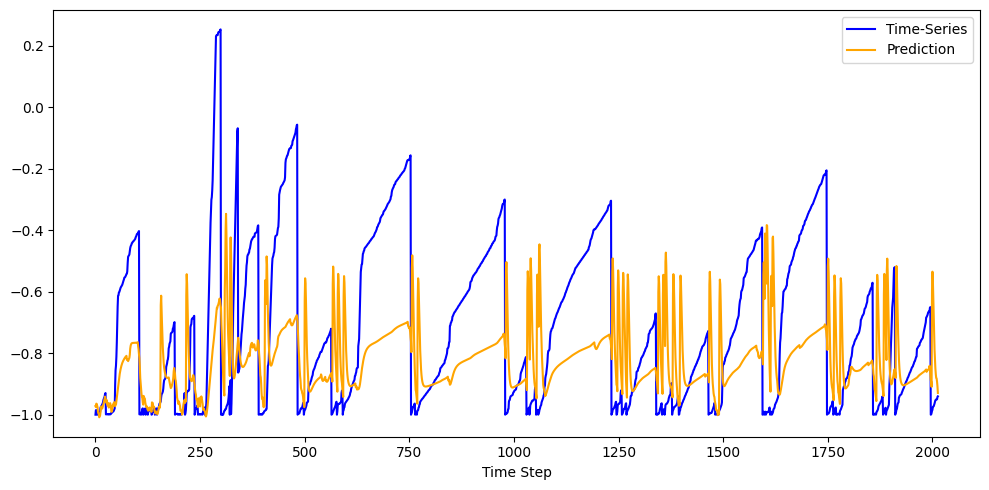

Channel C-2 Signal...
Epoch   5 | Train Loss: 0.165086 | Val Loss: 0.091949
Epoch  10 | Train Loss: 0.017602 | Val Loss: 0.013489
Epoch  15 | Train Loss: 0.005218 | Val Loss: 0.000043
Epoch  20 | Train Loss: 0.003442 | Val Loss: 0.000722
Early stopping at epoch 22

Metrics
-------
Precision = 0.1250
Recall = 0.5000
F1 = 0.2000


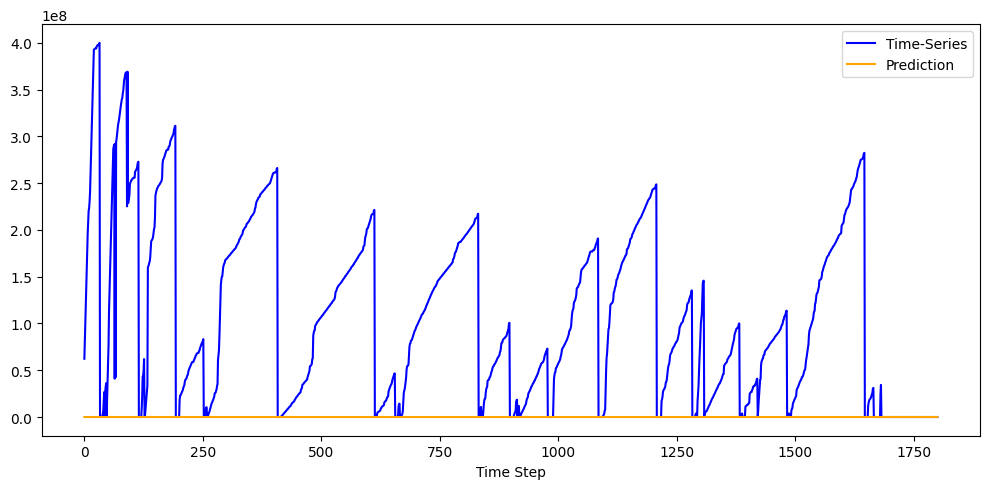

Channel D-14 Signal...
Epoch   5 | Train Loss: 0.005082 | Val Loss: 0.001579
Epoch  10 | Train Loss: 0.003002 | Val Loss: 0.001236
Epoch  15 | Train Loss: 0.001789 | Val Loss: 0.001051
Early stopping at epoch 17

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


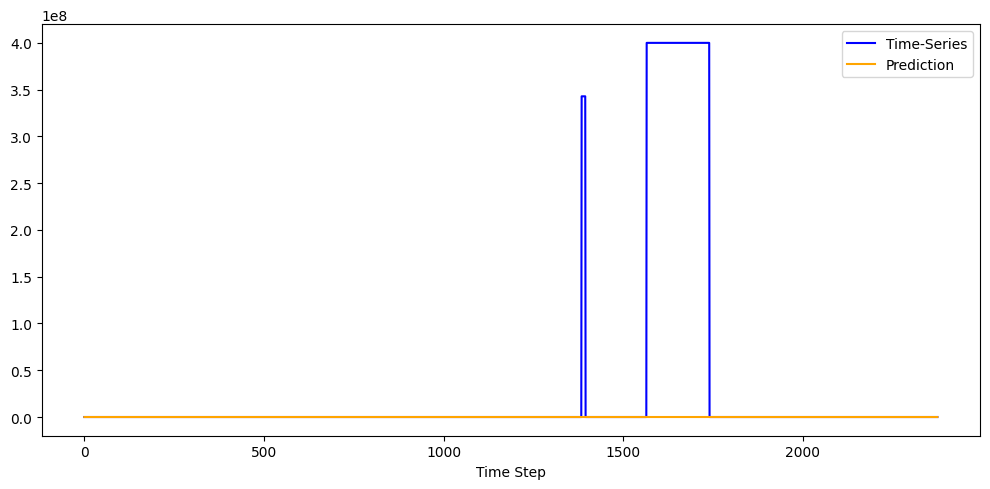

Channel D-15 Signal...
Epoch   5 | Train Loss: 0.344825 | Val Loss: 0.008762
Epoch  10 | Train Loss: 0.318917 | Val Loss: 0.069522
Epoch  15 | Train Loss: 0.302469 | Val Loss: 0.143751
Early stopping at epoch 17

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


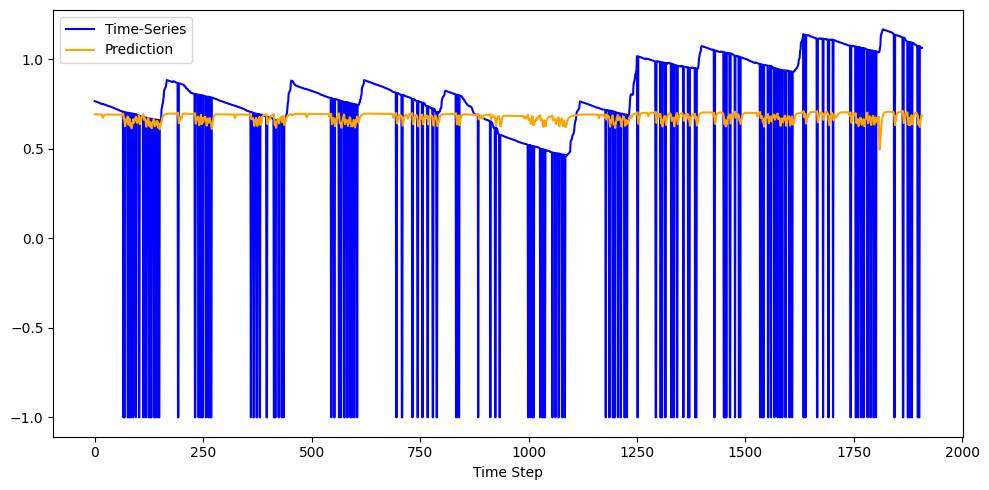

Channel D-16 Signal...
Epoch   5 | Train Loss: 0.506330 | Val Loss: 0.069904
Epoch  10 | Train Loss: 0.325648 | Val Loss: 0.181253
Epoch  15 | Train Loss: 0.241617 | Val Loss: 0.067062
Epoch  20 | Train Loss: 0.245539 | Val Loss: 0.020402
Epoch  25 | Train Loss: 0.239808 | Val Loss: 0.030642
Epoch  30 | Train Loss: 0.240057 | Val Loss: 0.018511
Epoch  35 | Train Loss: 0.242736 | Val Loss: 0.003786

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


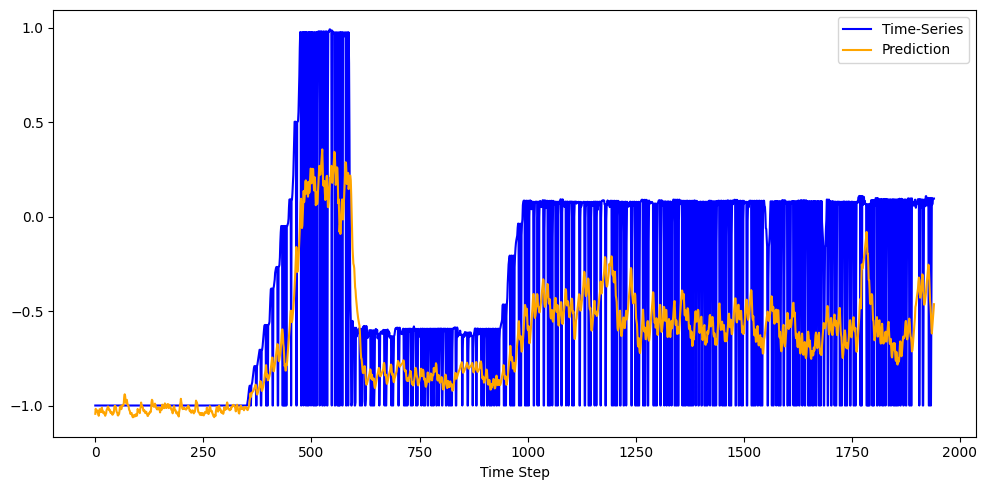

Channel F-4 Signal...
Epoch   5 | Train Loss: 0.152667 | Val Loss: 0.021307
Epoch  10 | Train Loss: 0.074489 | Val Loss: 0.018072
Epoch  15 | Train Loss: 0.046853 | Val Loss: 0.002876
Epoch  20 | Train Loss: 0.034965 | Val Loss: 0.000096
Epoch  25 | Train Loss: 0.028758 | Val Loss: 0.000652
Epoch  30 | Train Loss: 0.023554 | Val Loss: 0.000015
Early stopping at epoch 34

Metrics
-------
Precision = 0.1429
Recall = 1.0000
F1 = 0.2500


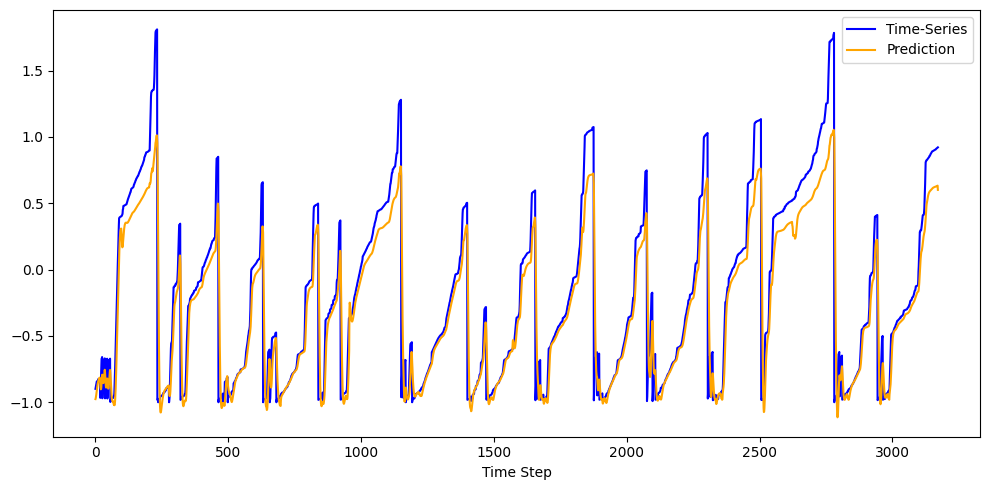

Channel F-5 Signal...
Epoch   5 | Train Loss: 0.049102 | Val Loss: 0.000012
Epoch  10 | Train Loss: 0.034222 | Val Loss: 0.005178
Epoch  15 | Train Loss: 0.016832 | Val Loss: 0.001564
Early stopping at epoch 17

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


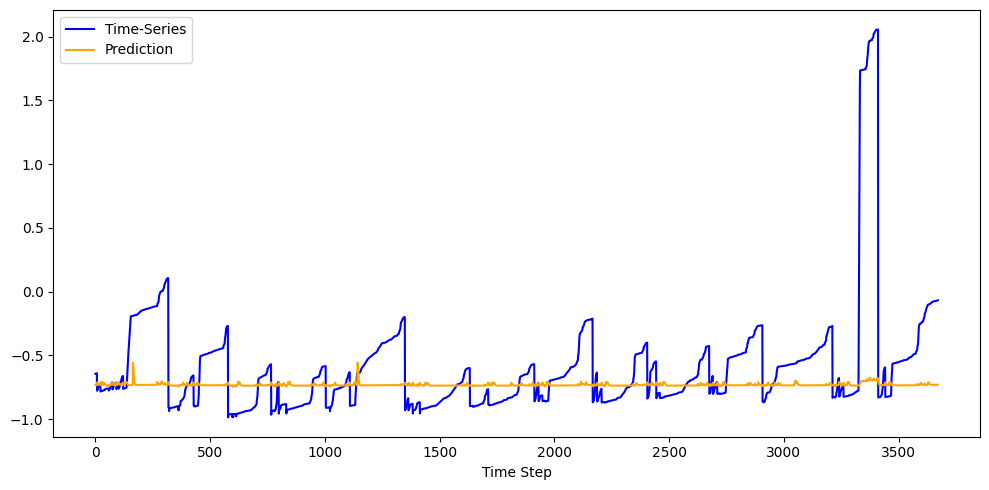

Channel F-7 Signal...
Epoch   5 | Train Loss: 0.389939 | Val Loss: 0.013047
Epoch  10 | Train Loss: 0.367168 | Val Loss: 0.026352
Epoch  15 | Train Loss: 0.332318 | Val Loss: 0.025780
Early stopping at epoch 16

Metrics
-------
Precision = 0.6000
Recall = 1.0000
F1 = 0.7500


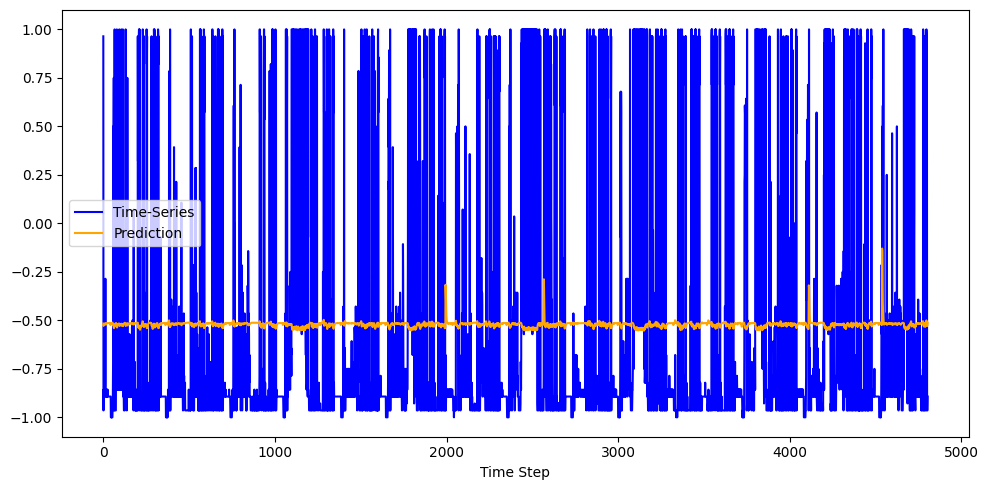

Channel F-8 Signal...
Epoch   5 | Train Loss: 0.179843 | Val Loss: 0.411581
Epoch  10 | Train Loss: 0.142503 | Val Loss: 0.349190
Epoch  15 | Train Loss: 0.110522 | Val Loss: 0.239582
Epoch  20 | Train Loss: 0.097075 | Val Loss: 0.179532
Epoch  25 | Train Loss: 0.089370 | Val Loss: 0.151269
Epoch  30 | Train Loss: 0.081954 | Val Loss: 0.133938
Epoch  35 | Train Loss: 0.078736 | Val Loss: 0.123547

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


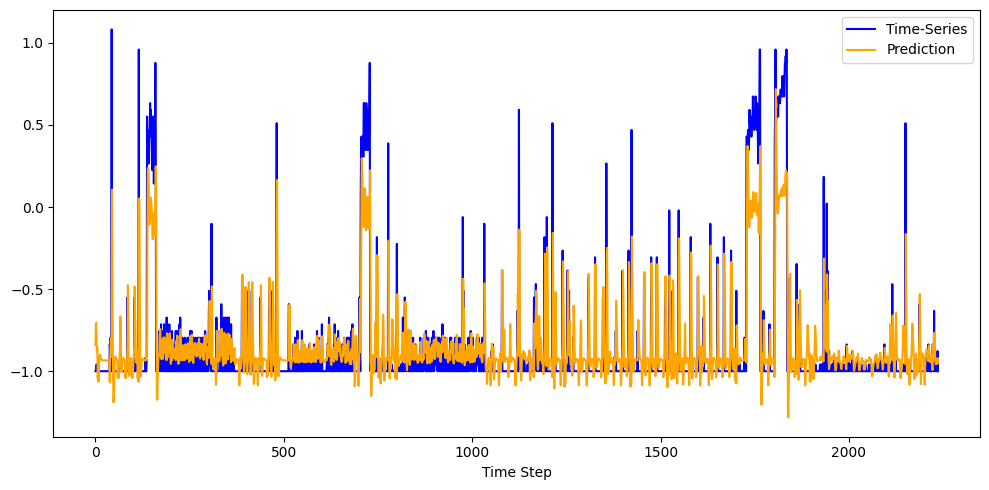

Channel M-1 Signal...
Epoch   5 | Train Loss: 0.138297 | Val Loss: 0.117361
Epoch  10 | Train Loss: 0.080240 | Val Loss: 0.063326
Epoch  15 | Train Loss: 0.049334 | Val Loss: 0.051227
Epoch  20 | Train Loss: 0.043166 | Val Loss: 0.040631
Epoch  25 | Train Loss: 0.037305 | Val Loss: 0.037058
Epoch  30 | Train Loss: 0.035189 | Val Loss: 0.035385
Epoch  35 | Train Loss: 0.032768 | Val Loss: 0.035433

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


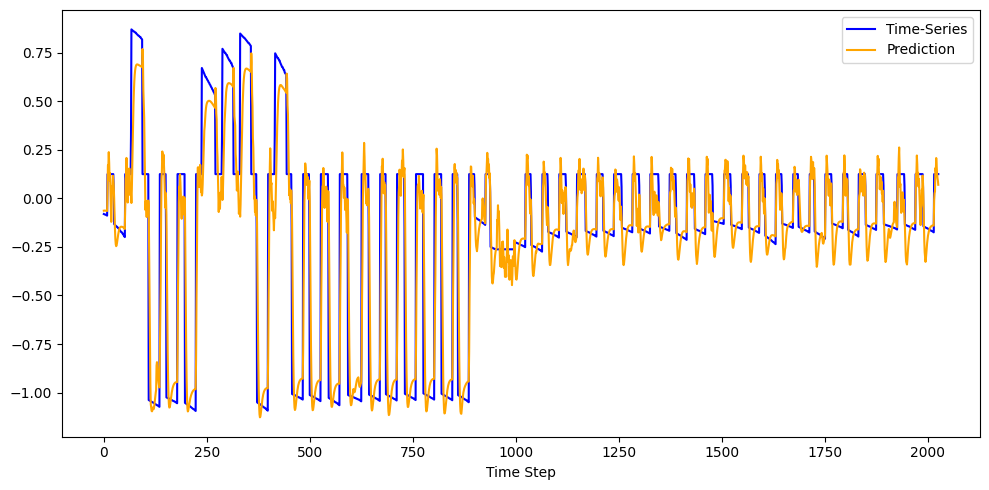

Channel M-2 Signal...
Epoch   5 | Train Loss: 0.061954 | Val Loss: 0.015605
Epoch  10 | Train Loss: 0.052046 | Val Loss: 0.006188
Epoch  15 | Train Loss: 0.037379 | Val Loss: 0.000430
Early stopping at epoch 16

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


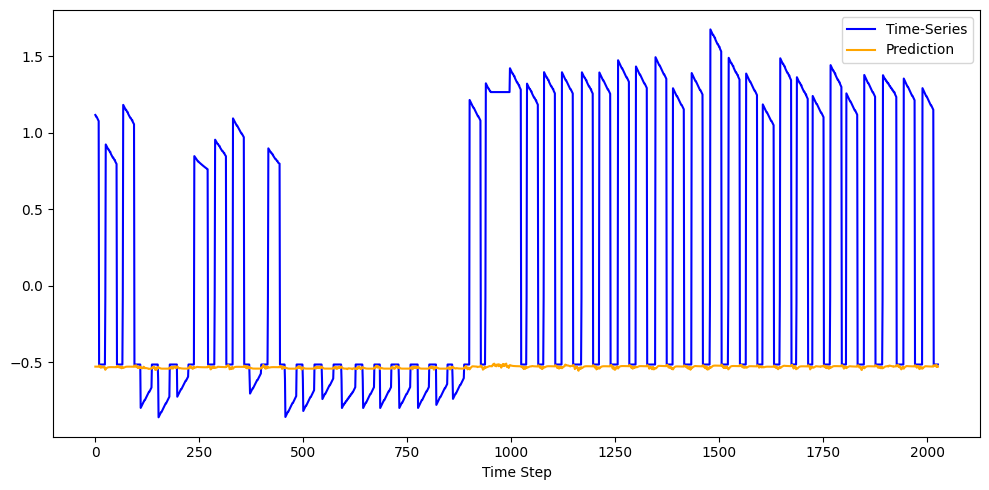

Channel M-3 Signal...
Epoch   5 | Train Loss: 0.254503 | Val Loss: 0.087179
Epoch  10 | Train Loss: 0.102321 | Val Loss: 0.032673
Epoch  15 | Train Loss: 0.079031 | Val Loss: 0.015590
Epoch  20 | Train Loss: 0.067156 | Val Loss: 0.013845
Epoch  25 | Train Loss: 0.060322 | Val Loss: 0.011966
Epoch  30 | Train Loss: 0.055826 | Val Loss: 0.009126
Epoch  35 | Train Loss: 0.050672 | Val Loss: 0.007530

Metrics
-------
Precision = 0.1667
Recall = 1.0000
F1 = 0.2857


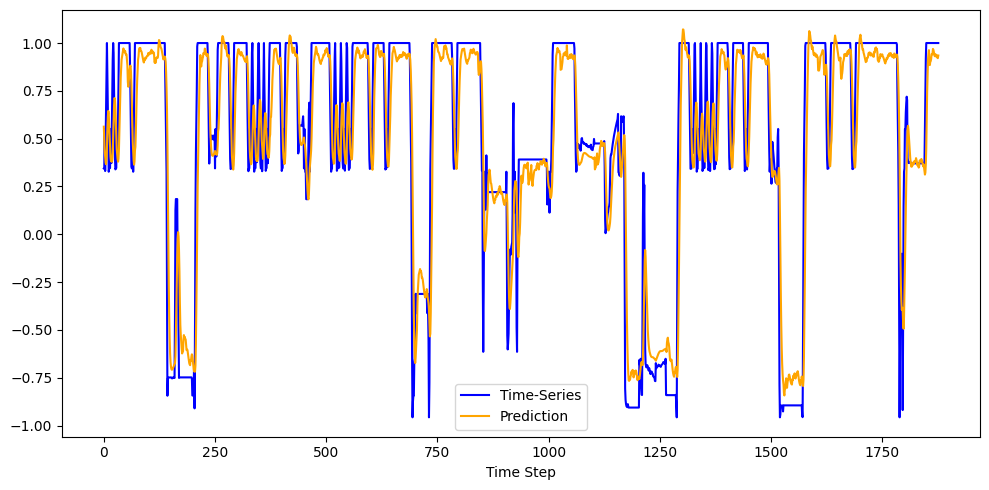

Channel M-4 Signal...
Epoch   5 | Train Loss: 0.227922 | Val Loss: 0.075925
Epoch  10 | Train Loss: 0.110872 | Val Loss: 0.042269
Epoch  15 | Train Loss: 0.090011 | Val Loss: 0.017924
Epoch  20 | Train Loss: 0.078054 | Val Loss: 0.007957
Epoch  25 | Train Loss: 0.073420 | Val Loss: 0.005040
Epoch  30 | Train Loss: 0.070490 | Val Loss: 0.002213
Epoch  35 | Train Loss: 0.065925 | Val Loss: 0.000570

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


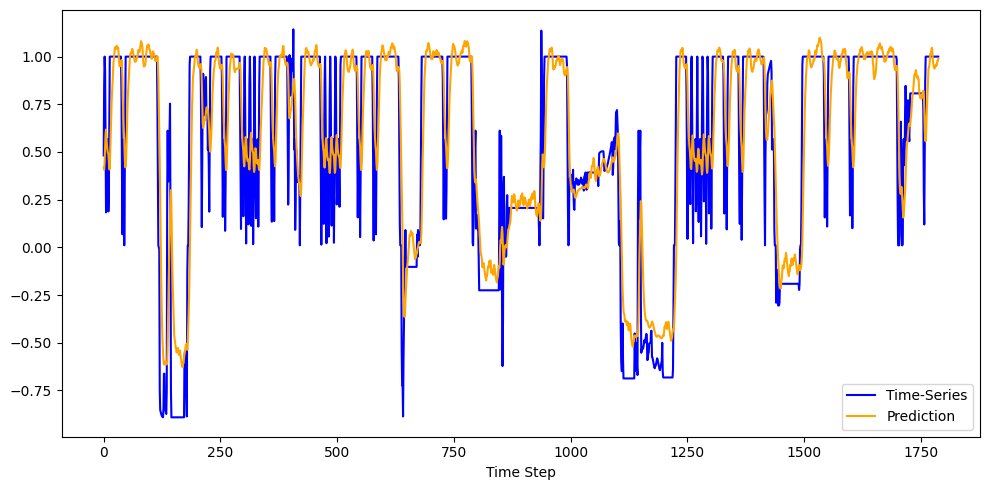

Channel M-5 Signal...
Epoch   5 | Train Loss: 0.268987 | Val Loss: 0.114784
Epoch  10 | Train Loss: 0.174285 | Val Loss: 0.101173
Epoch  15 | Train Loss: 0.144922 | Val Loss: 0.031466
Epoch  20 | Train Loss: 0.120915 | Val Loss: 0.013745
Epoch  25 | Train Loss: 0.106207 | Val Loss: 0.008306
Epoch  30 | Train Loss: 0.091395 | Val Loss: 0.009211
Epoch  35 | Train Loss: 0.081965 | Val Loss: 0.011728

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


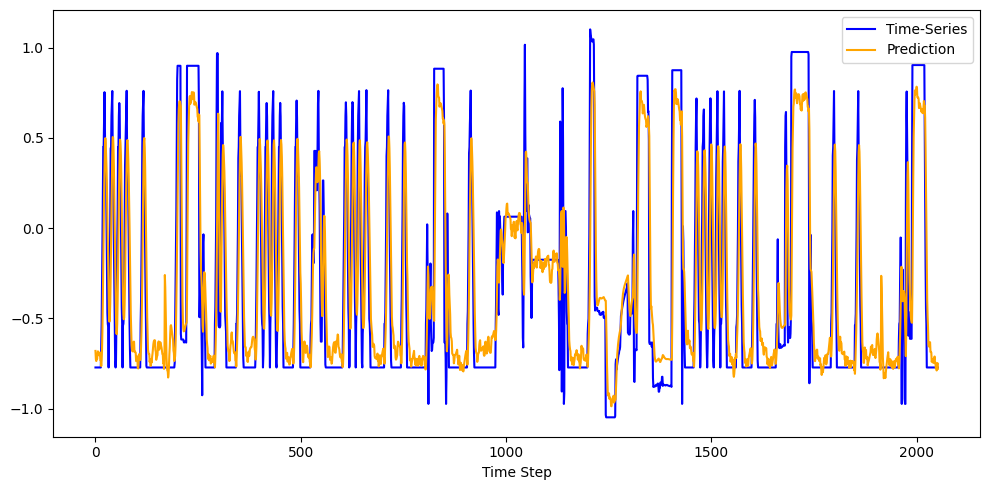

Channel M-6 Signal...
Epoch   5 | Train Loss: 0.004102 | Val Loss: 0.000610
Epoch  10 | Train Loss: 0.003275 | Val Loss: 0.001192
Epoch  15 | Train Loss: 0.002959 | Val Loss: 0.001071
Early stopping at epoch 19

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


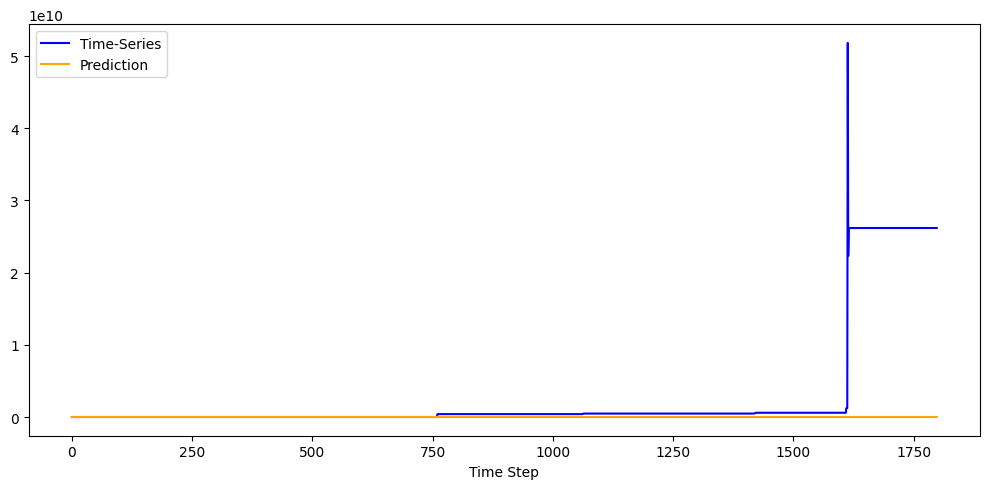

Channel M-7 Signal...
Epoch   5 | Train Loss: 0.021541 | Val Loss: 0.000067
Epoch  10 | Train Loss: 0.022103 | Val Loss: 0.000683
Epoch  15 | Train Loss: 0.020650 | Val Loss: 0.000878
Early stopping at epoch 19

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


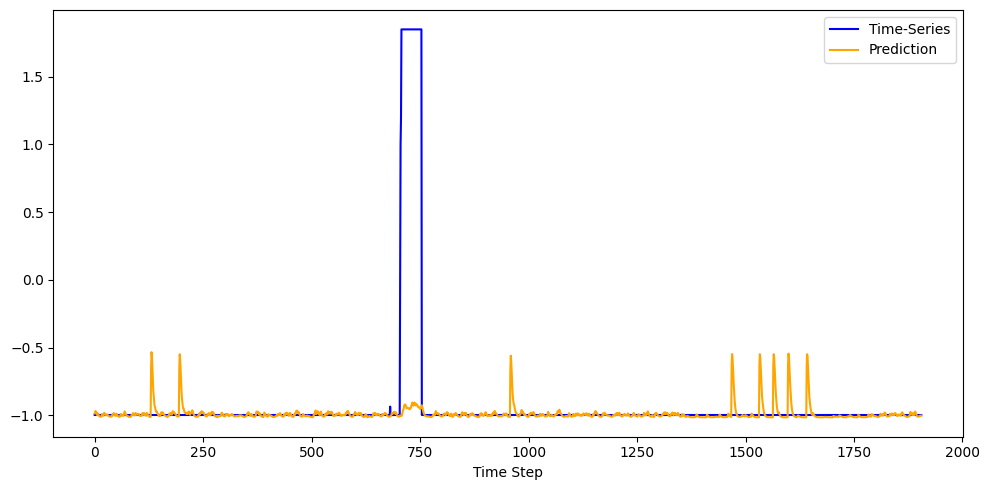

Channel P-10 Signal...
Epoch   5 | Train Loss: 0.027377 | Val Loss: 0.027914
Epoch  10 | Train Loss: 0.026957 | Val Loss: 0.027505
Epoch  15 | Train Loss: 0.026694 | Val Loss: 0.027370
Epoch  20 | Train Loss: 0.026748 | Val Loss: 0.027268
Epoch  25 | Train Loss: 0.026722 | Val Loss: 0.027241
Early stopping at epoch 26

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


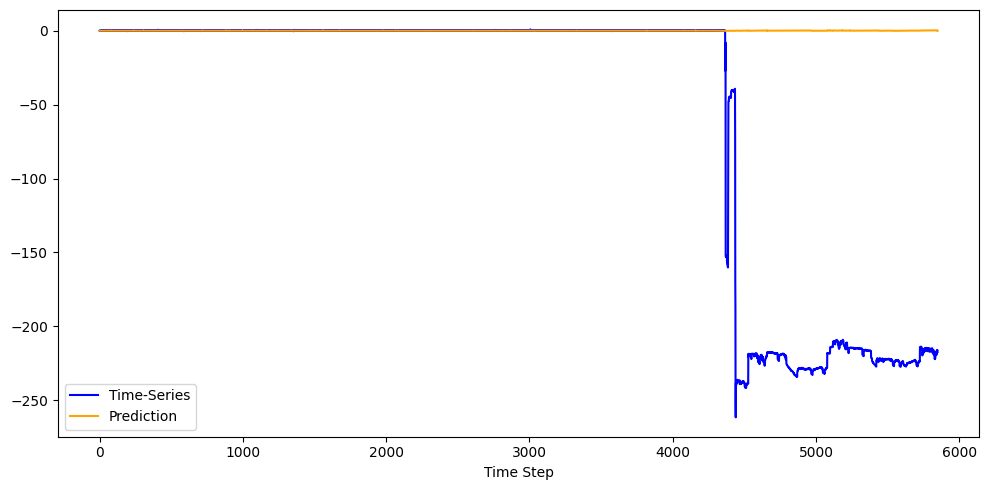

Channel P-11 Signal...
Epoch   5 | Train Loss: 0.068586 | Val Loss: 0.035792
Epoch  10 | Train Loss: 0.042768 | Val Loss: 0.032807
Epoch  15 | Train Loss: 0.035476 | Val Loss: 0.030955
Epoch  20 | Train Loss: 0.031256 | Val Loss: 0.029522
Epoch  25 | Train Loss: 0.029862 | Val Loss: 0.029695
Epoch  30 | Train Loss: 0.028059 | Val Loss: 0.030174
Epoch  35 | Train Loss: 0.026857 | Val Loss: 0.029041

Metrics
-------
Precision = 0.5000
Recall = 0.5000
F1 = 0.5000


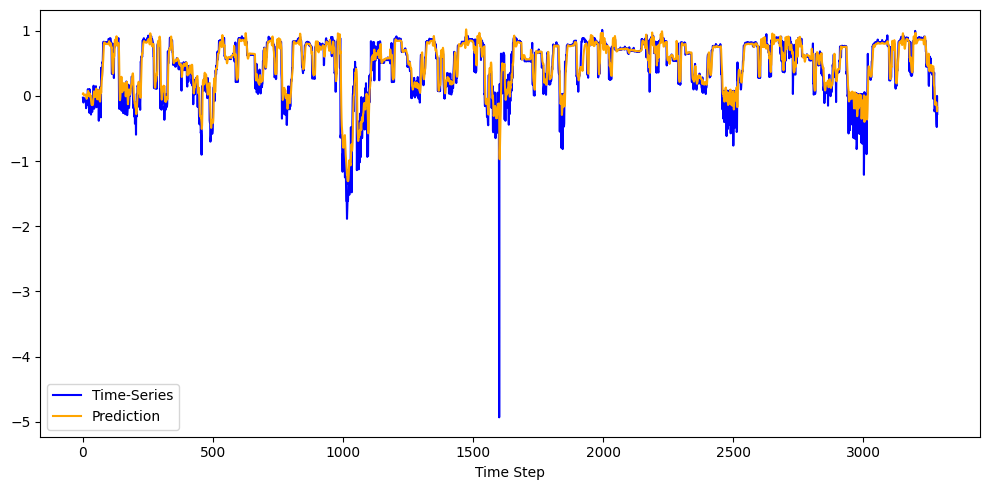

Channel P-14 Signal...
Epoch   5 | Train Loss: 0.027443 | Val Loss: 0.033963
Epoch  10 | Train Loss: 0.027411 | Val Loss: 0.033289
Epoch  15 | Train Loss: 0.027329 | Val Loss: 0.032193
Epoch  20 | Train Loss: 0.027327 | Val Loss: 0.031741
Epoch  25 | Train Loss: 0.027440 | Val Loss: 0.031352
Epoch  30 | Train Loss: 0.027229 | Val Loss: 0.031019
Epoch  35 | Train Loss: 0.027237 | Val Loss: 0.030889

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


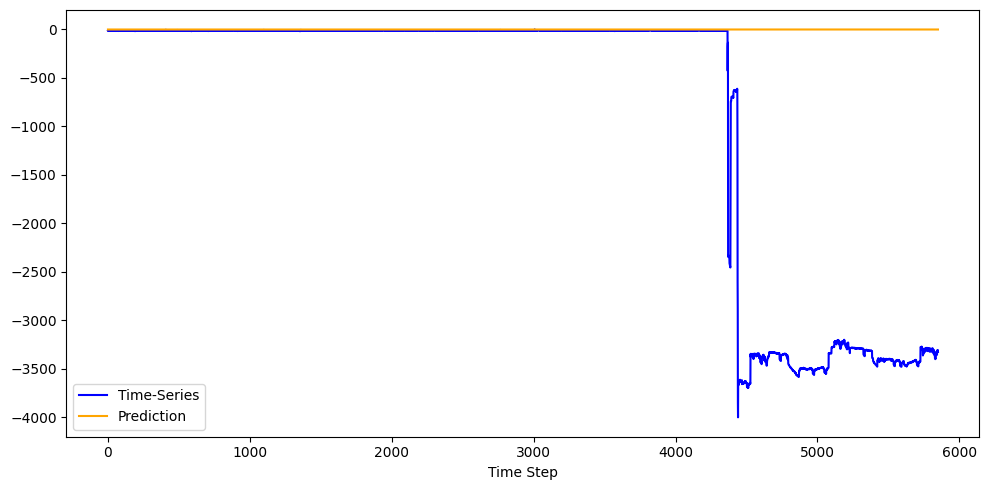

Channel P-15 Signal...
Epoch   5 | Train Loss: 0.066084 | Val Loss: 0.010324
Epoch  10 | Train Loss: 0.014376 | Val Loss: 0.005138
Epoch  15 | Train Loss: 0.009833 | Val Loss: 0.003922
Epoch  20 | Train Loss: 0.008924 | Val Loss: 0.004031
Epoch  25 | Train Loss: 0.008761 | Val Loss: 0.004727
Early stopping at epoch 27

Metrics
-------
Precision = 0.2000
Recall = 1.0000
F1 = 0.3333


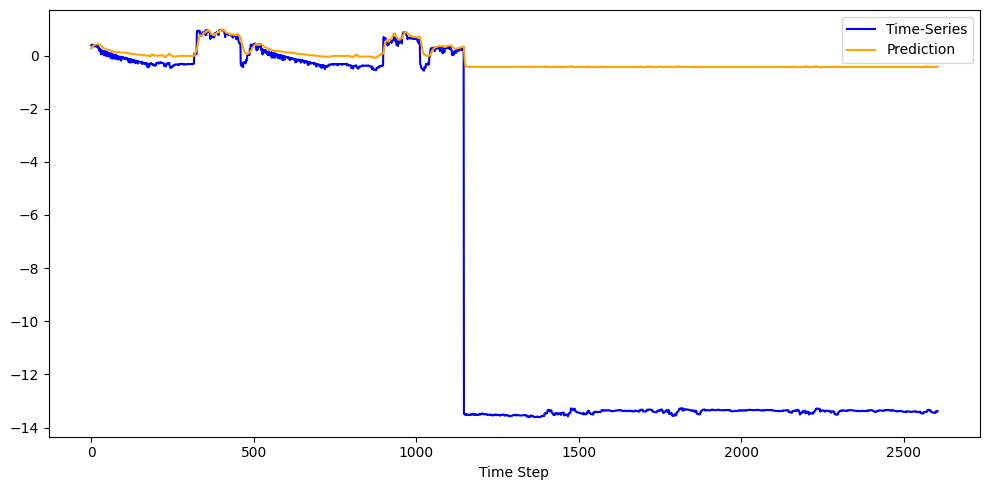

Channel S-2 Signal...
Epoch   5 | Train Loss: 0.007072 | Val Loss: 0.011784
Epoch  10 | Train Loss: 0.004318 | Val Loss: 0.000170
Epoch  15 | Train Loss: 0.003807 | Val Loss: 0.001584
Epoch  20 | Train Loss: 0.003736 | Val Loss: 0.001658
Early stopping at epoch 24

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


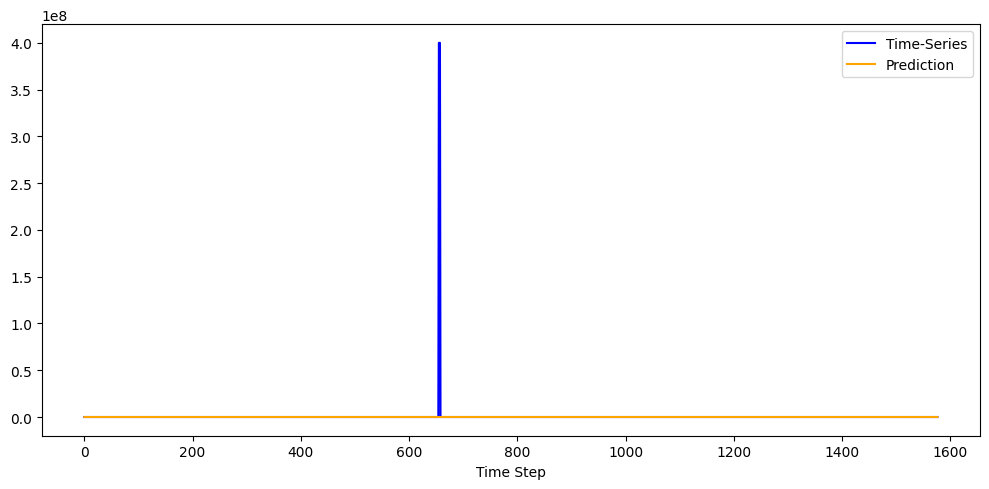

Channel T-12 Signal...
Epoch   5 | Train Loss: 0.249671 | Val Loss: 1.302069
Epoch  10 | Train Loss: 0.209523 | Val Loss: 1.002149
Epoch  15 | Train Loss: 0.093519 | Val Loss: 0.282985
Epoch  20 | Train Loss: 0.042540 | Val Loss: 0.038234
Epoch  25 | Train Loss: 0.033028 | Val Loss: 0.036354
Epoch  30 | Train Loss: 0.032791 | Val Loss: 0.035063
Epoch  35 | Train Loss: 0.030461 | Val Loss: 0.021195

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


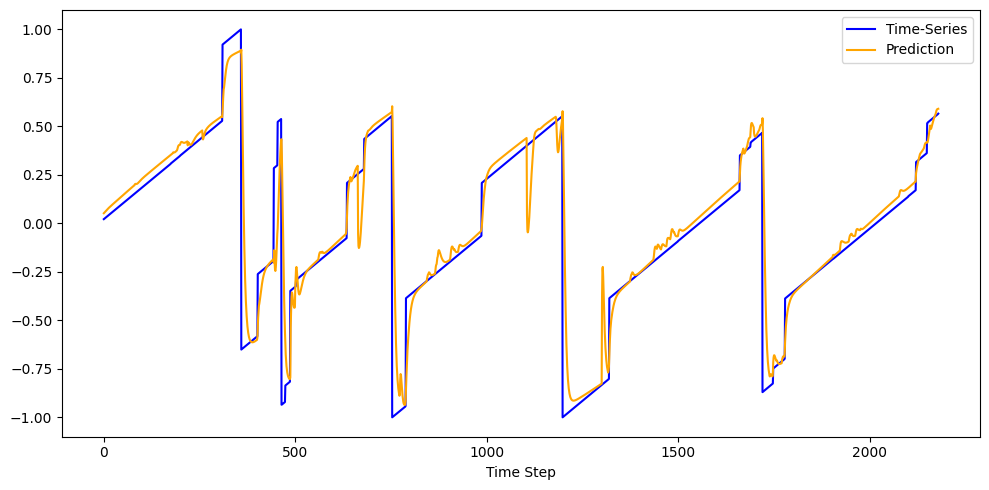

Channel T-13 Signal...
Epoch   5 | Train Loss: 0.176278 | Val Loss: 1.050351
Epoch  10 | Train Loss: 0.157715 | Val Loss: 0.991829
Epoch  15 | Train Loss: 0.127202 | Val Loss: 0.737552
Epoch  20 | Train Loss: 0.035391 | Val Loss: 0.413958
Epoch  25 | Train Loss: 0.055382 | Val Loss: 0.525319
Epoch  30 | Train Loss: 0.020373 | Val Loss: 0.338724
Epoch  35 | Train Loss: 0.015842 | Val Loss: 0.327533

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


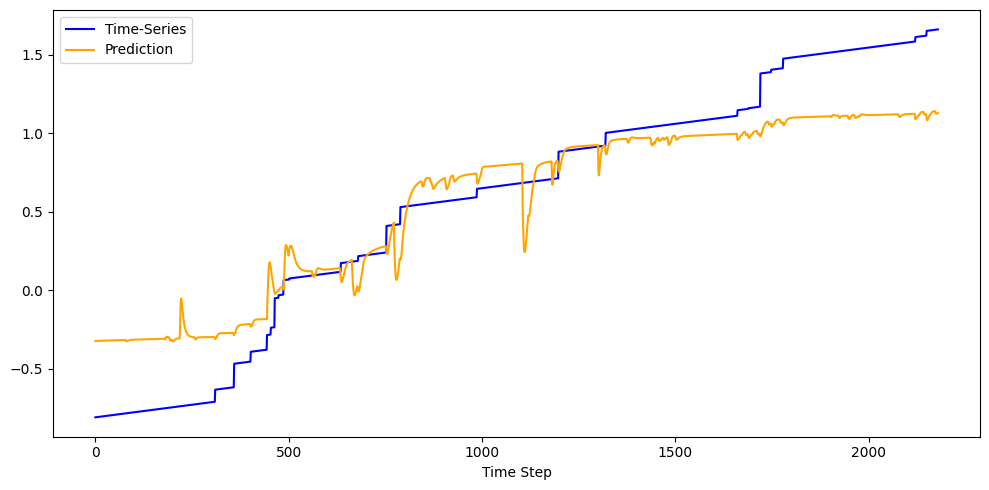

Channel T-4 Signal...
Epoch   5 | Train Loss: 0.577175 | Val Loss: 0.853810
Epoch  10 | Train Loss: 0.402393 | Val Loss: 0.037644
Epoch  15 | Train Loss: 0.329716 | Val Loss: 0.000102
Epoch  20 | Train Loss: 0.291588 | Val Loss: 0.008425
Epoch  25 | Train Loss: 0.266268 | Val Loss: 0.002482
Epoch  30 | Train Loss: 0.247996 | Val Loss: 0.000281
Early stopping at epoch 30

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


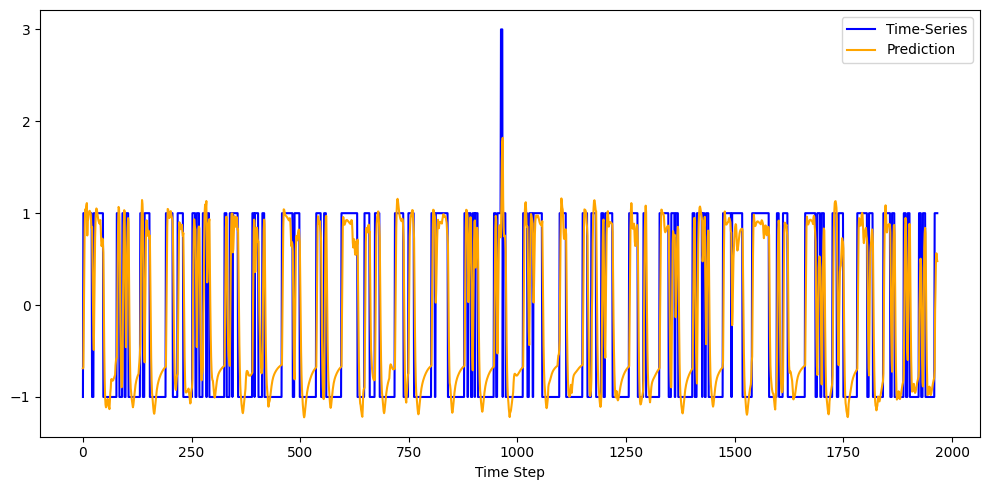

Channel T-5 Signal...
Epoch   5 | Train Loss: 0.003240 | Val Loss: 0.000238
Epoch  10 | Train Loss: 0.002712 | Val Loss: 0.000226
Epoch  15 | Train Loss: 0.002217 | Val Loss: 0.000265
Early stopping at epoch 18

Metrics
-------
Precision = 0.1667
Recall = 1.0000
F1 = 0.2857


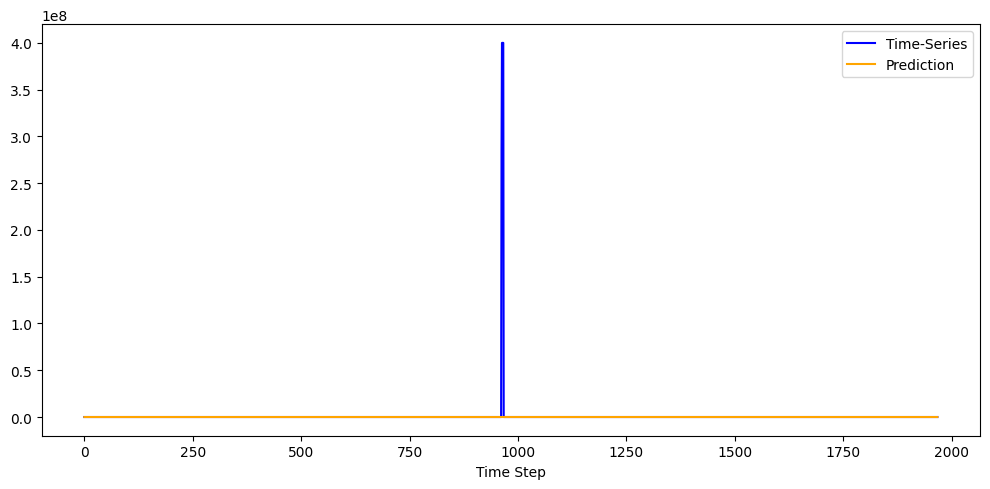

Channel T-8 Signal...
Epoch   5 | Train Loss: 0.384419 | Val Loss: 0.267622
Epoch  10 | Train Loss: 0.049339 | Val Loss: 0.004695
Epoch  15 | Train Loss: 0.051956 | Val Loss: 0.002238
Epoch  20 | Train Loss: 0.050587 | Val Loss: 0.000057
Epoch  25 | Train Loss: 0.050977 | Val Loss: 0.001049
Epoch  30 | Train Loss: 0.046380 | Val Loss: 0.000691
Early stopping at epoch 32

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


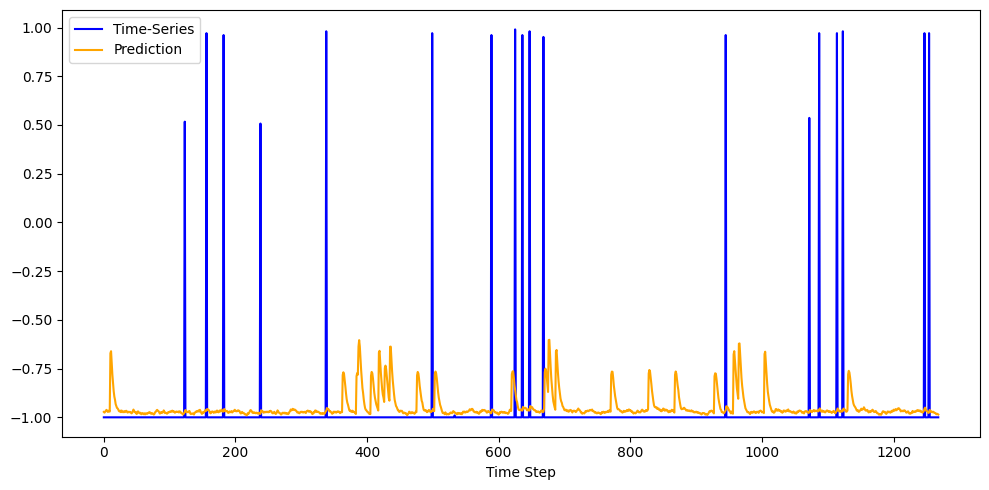

Channel T-9 Signal...
-----------
MSL Metrics
-----------
Precision: 0.264
Recall: 0.596
F1: 0.330



In [45]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for msl_channel, X_train, X_test, y_test in zip(msl_channel_names, msl_train, msl_test, msl_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])

    print(f"Channel {msl_channel} Signal...")
    # plot_signal(X_train[:, 0], y_train)
    # plot_signal(X_test[:, 0], y_test)

    try:
        precision, recall, f1 = run_pipeline(
            X=X_train, 
            y=y_train, 
            X_test=X_test, 
            y_test=y_test,
            **MSL_HYPERPARAMS
        )
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("-----------")
print("MSL Metrics")
print("-----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **SMAP**

In [46]:
SMAP_HYPEPARAMS = NASA_HYPERPARAMS.copy()
SMAP_HYPEPARAMS["verbose"] = False

In [47]:
smap_split_url = f"{NASA_SPLIT_REPO}{NASA_SMAP_SPLIT}"
smap_split = pd.read_csv(smap_split_url)

# extract the file names corresponding to the SMAP dataset
smap_channels_names = list(smap_split["chan_id"].values)
# add the .npy file extensions to the SMAP file names
smap_file_names = [f"{smap_file_name}.npy" for smap_file_name in smap_channels_names]
# sort them alphabetically
smap_file_names.sort()

In [48]:
smap_train: list[np.ndarray] = []
smap_test: list[np.ndarray] = []
smap_test_y: list[list] = []

for smap_file_name in smap_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    smap_train_ts = np.load(os.path.join(nasa_train_path, smap_file_name))
    smap_test_ts = np.load(os.path.join(nasa_test_path, smap_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == smap_file_name[:-4]]
    smap_test_interval_str = row["anomaly_sequences"].iloc[0]
    smap_test_interval = ast.literal_eval(smap_test_interval_str)
    smap_test_labels = intervals_to_points(smap_test_interval, len(smap_test_ts))

    smap_train.append(smap_train_ts)
    smap_test.append(smap_test_ts)

    smap_test_y.append(smap_test_labels)

In [49]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for smap_channel, X_train, X_test, y_test in zip(smap_channels_names, smap_train, smap_test, smap_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])
    
    print(f"Channel {smap_channel} Signal...")

    try:
        precision, recall, f1 = run_pipeline(
            X=X_train, 
            y=y_train, 
            X_test=X_test, 
            y_test=y_test,
            **SMAP_HYPEPARAMS
        )
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("-----------")
print("SMAP Metrics")
print("-----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

Channel A-1 Signal...
Channel A-2 Signal...
Channel A-3 Signal...
Channel A-4 Signal...
Channel A-5 Signal...
Channel A-6 Signal...
Channel A-7 Signal...
Channel A-8 Signal...
Channel A-9 Signal...
Channel B-1 Signal...
Channel D-1 Signal...
Channel D-11 Signal...
Channel D-12 Signal...
Channel D-13 Signal...
Channel D-2 Signal...
Channel D-3 Signal...
Channel D-4 Signal...
Channel D-5 Signal...
Channel D-6 Signal...
Channel D-7 Signal...
Channel D-8 Signal...
Channel D-9 Signal...
Channel E-1 Signal...
Channel E-10 Signal...
Channel E-11 Signal...
Channel E-12 Signal...
Channel E-13 Signal...
Channel E-2 Signal...
Channel E-3 Signal...
Channel E-4 Signal...
Channel E-5 Signal...
Channel E-6 Signal...
Channel E-7 Signal...
Channel E-8 Signal...
Channel E-9 Signal...
Channel F-1 Signal...
Channel F-2 Signal...
Channel F-3 Signal...
Channel G-1 Signal...
Channel G-2 Signal...
Channel G-3 Signal...
Channel G-4 Signal...
Channel G-6 Signal...
Channel G-7 Signal...
Channel P-1 Signal...
Cha